In [34]:
!pip install imbalanced-learn imbalanced-ensemble scikit-learn pandas numpy scipy

In [6]:
import os
import time
import pickle
from sklearn.datasets import fetch_openml
import pandas as pd

CACHE_DIR = "results/dataset_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def _fetch_with_retry(name, version=None, max_retries=4, base_delay=5):
    """Retries fetch_openml with exponential backoff on transient network errors."""
    for attempt in range(1, max_retries + 1):
        try:
            if version:
                return fetch_openml(name=name, version=version, as_frame=True, parser='auto')
            return fetch_openml(name=name, as_frame=True, parser='auto')
        except Exception as e:
            if attempt == max_retries:
                raise
            wait = base_delay * (2 ** (attempt - 1))  # 5s, 10s, 20s, 40s...
            print(f"[retry] fetch failed for '{name}' (attempt {attempt}/{max_retries}): {e}")
            print(f"[retry] waiting {wait}s before retrying...")
            time.sleep(wait)

def load_dataset(dataset_name):
    """
    Fetches a dataset from OpenML (with local caching + retry) and applies
    CLIMB-specific binarization logic.
    """
    cache_path = os.path.join(CACHE_DIR, f"{dataset_name}.pkl")

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            X, y = pickle.load(f)
        return X, y

    if dataset_name == "vertebra-column":
        bunch = _fetch_with_retry(dataset_name, version=2)
    elif dataset_name == "vehicle":
        bunch = _fetch_with_retry(dataset_name, version=1)
    else:
        bunch = _fetch_with_retry(dataset_name)

    X = bunch.data
    y = bunch.target

    valid_idx = y.dropna().index
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]

    if dataset_name == "vehicle":
        target_class = y.value_counts().idxmax()
    else:
        target_class = y.value_counts().idxmin()

    y_binary = (y == target_class).astype(int)

    # Save to cache for next time — no more repeated network calls for this dataset
    with open(cache_path, "wb") as f:
        pickle.dump((X, y_binary), f)

    return X, y_binary

In [36]:

datasets_to_check = ["mc2", "vertebra-column", "haberman", "vehicle"]

print("--- Imbalance Ratio (IR) Check ---")
for dataset_name in datasets_to_check:
    # Uses the load_dataset function we built in Day 1
    X, y = load_dataset(dataset_name)
    counts = y.value_counts()
    
    # Majority (0) divided by Minority (1)
    ir = counts[0] / counts[1] 
    
    print(f"Dataset: {dataset_name:<18} | Calculated IR: {round(ir, 2)}")

--- Imbalance Ratio (IR) Check ---
Dataset: mc2                | Calculated IR: 2.1
Dataset: vertebra-column    | Calculated IR: 2.1
Dataset: haberman           | Calculated IR: 2.78
Dataset: vehicle            | Calculated IR: 2.88


In [37]:
X, y = load_dataset("vertebra-column")
counts = y.value_counts()
ir = counts[0] / counts[1]
print(f"vertebra-column IR: {round(ir, 2)}")

vertebra-column IR: 2.1


In [49]:
import os
if os.path.exists("results/conf_v1.csv"):
    os.remove("results/conf_v1.csv")
    print("Deleted — ready for interrupt test")

Deleted — ready for interrupt test


In [50]:
import os
import time
import signal
import pandas as pd
import numpy as np
from datetime import datetime

# Provided imports
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score, f1_score, balanced_accuracy_score
from imblearn.pipeline import Pipeline      # imblearn, not sklearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, TomekLinks

# --- 1. CONFIGURATION (Thin Slice for Day 1) ---
# --- 1. CONFIGURATION (Day 2 Reproduction Gate) ---
config = {
    "run_id": "conf_v1",
    "datasets": ["mc2", "vertebra-column", "haberman", "vehicle"], # <-- ALL 4 DATASETS
    "methods": ["base", "rus", "enn", "tomek", "smote"], 
    "base_classifiers": ["decision_tree"], 
    "ensemble_size": 1, 
    "n_folds": 5,
    "metrics": ["auprc", "macro_f1", "balanced_accuracy"],
    "cell_timeout_seconds": 900,
    "random_state": 42,
    "output_csv": "results/conf_v1.csv"
}
# --- 2. CSV LOGGER SETUP ---
csv_columns = [
    "run_id", "timestamp", "dataset", "n_samples", "n_features", 
    "imbalance_ratio", "ir_group", "method", "method_family", 
    "base_classifier", "ensemble_size", "tuning_mode", "fold", 
    "metric", "value", "fit_seconds", "status", "notes"
]

if not os.path.exists("results"):
    os.makedirs("results")

if not os.path.exists(config["output_csv"]):
    pd.DataFrame(columns=csv_columns).to_csv(config["output_csv"], index=False)

def append_result(row_dict):
    """Appends one row to the CSV the moment the number exists."""
    pd.DataFrame([row_dict])[csv_columns].to_csv(config["output_csv"], mode='a', header=False, index=False)

def is_done(dataset, method, clf, fold, metric):
    """Skip logic: checks if the exact combination is already in the CSV."""
    df = pd.read_csv(config["output_csv"])
    if df.empty:
        return False
    match = df[
        (df["dataset"] == dataset) & 
        (df["method"] == method) & 
        (df["base_classifier"] == clf) & 
        (df["fold"] == fold) & 
        (df["metric"] == metric) &
        (df["status"] == "ok")
    ]
    return not match.empty

# --- 3. HELPER FUNCTIONS ---
def get_ir_group(ir):
    """Categorizes imbalance ratio based on CLIMB paper groupings."""
    if ir < 5: return "low"
    elif 5 <= ir < 10: return "medium"
    elif 10 <= ir < 50: return "high"
    else: return "extreme"

# Timeout handler for Linux/Kaggle environments
def timeout_handler(signum, frame):
    raise TimeoutError("Cell timeout exceeded")
signal.signal(signal.SIGALRM, timeout_handler)

# --- 4. METHOD & CLASSIFIER MAPPINGS ---
method_families = {
    "base": "baseline", 
    "rus": "undersampling", 
    "enn": "cleaning",
    "tomek": "cleaning", 
    "smote": "oversampling"
}

def get_resampler(method_name):
    """Returns the resampler instantiated with random_state=42 where applicable."""
    if method_name == "base": return "passthrough"
    if method_name == "rus": return RandomUnderSampler(random_state=config["random_state"])
    if method_name == "enn": return EditedNearestNeighbours() # No random state parameter for ENN
    if method_name == "tomek": return TomekLinks() # No random state parameter for TomekLinks
    if method_name == "smote": return SMOTE(random_state=config["random_state"])
    return None

def get_classifier(clf_name):
    if clf_name == "decision_tree": return DecisionTreeClassifier(random_state=config["random_state"])
    # Logistic regression reserved for later sweeps
    return None

# --- 5. EXPERIMENT LOOP ---
for dataset_name in config["datasets"]:
    
    # NOTE: You must provide your 'load_dataset' function in the cell above this script
    # which fetches the dataset and ensures the minority class is labeled 1.
    X, y = load_dataset(dataset_name)
    
    n_samples = X.shape[0]
    n_features = X.shape[1]
    counts = y.value_counts()
    # Minority is 1, Majority is 0. Ensure proper division.
    ir = counts[0] / counts[1]
    ir_group = get_ir_group(ir)
    
    cv = StratifiedKFold(n_splits=config["n_folds"], shuffle=True, random_state=config["random_state"])
    
    for clf_name in config["base_classifiers"]:
        clf = get_classifier(clf_name)
        
        for method_name in config["methods"]:
            family = method_families[method_name]
            resampler = get_resampler(method_name)
            
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                
                # Check skip logic for all metrics on this fold before fitting
                if all(is_done(dataset_name, method_name, clf_name, fold, m) for m in config["metrics"]):
                    continue
                
                # Base row dictionary with shared metadata
                row_base = {
                    "run_id": config["run_id"],
                    "dataset": dataset_name,
                    "n_samples": n_samples,
                    "n_features": n_features,
                    "imbalance_ratio": round(ir, 2),
                    "ir_group": ir_group,
                    "method": method_name,
                    "method_family": family,
                    "base_classifier": clf_name,
                    "ensemble_size": config["ensemble_size"],
                    "tuning_mode": "default",
                    "fold": fold
                }

                pipe_steps = [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())
                ]
                
                if resampler != "passthrough":
                    pipe_steps.append(("resample", resampler))
                
                pipe_steps.append(("clf", clf))
                pipe = Pipeline(pipe_steps)
                
                fit_start = time.time()
                status = "ok"
                notes = ""
                
                try:
                    # Enforce the 900-second timeout
                    signal.alarm(config["cell_timeout_seconds"])
                    
                    pipe.fit(X.iloc[tr], y.iloc[tr])
                    proba = pipe.predict_proba(X.iloc[te])[:, 1]
                    pred = pipe.predict(X.iloc[te])
                    
                    signal.alarm(0) # Disable alarm on success
                    fit_seconds = round(time.time() - fit_start, 2)
                    
                except TimeoutError as e:
                    status = "timeout"
                    notes = str(e)
                    fit_seconds = round(time.time() - fit_start, 2)
                except Exception as e:
                    signal.alarm(0)
                    status = "error"
                    notes = str(e)
                    fit_seconds = round(time.time() - fit_start, 2)
                
                # If fitting failed (timeout, error, or infeasible), log empty values for all metrics and move to next
                if status != "ok":
                    for metric in config["metrics"]:
                        if not is_done(dataset_name, method_name, clf_name, fold, metric):
                            row = row_base.copy()
                            row.update({
                                "timestamp": datetime.now().isoformat(),
                                "metric": metric,
                                "value": "",
                                "fit_seconds": fit_seconds,
                                "status": status,
                                "notes": notes
                            })
                            append_result(row)
                    continue

                # If successful, calculate and log each metric independently
                metrics_calc = {
                    "auprc": round(average_precision_score(y.iloc[te], proba), 4),
                    "macro_f1": round(f1_score(y.iloc[te], pred, average="macro"), 4),
                    "balanced_accuracy": round(balanced_accuracy_score(y.iloc[te], pred), 4)
                }
                
                for metric_name, val in metrics_calc.items():
                    if not is_done(dataset_name, method_name, clf_name, fold, metric_name):
                        row = row_base.copy()
                        row.update({
                            "timestamp": datetime.now().isoformat(),
                            "metric": metric_name,
                            "value": val,
                            "fit_seconds": fit_seconds,
                            "status": status,
                            "notes": notes
                        })
                    
                        append_result(row)

KeyboardInterrupt: 

In [51]:
 # it was for sweep
import pandas as pd
df = pd.read_csv("results/conf_v1.csv")
print(f"Rows so far: {len(df)}")
print(df["dataset"].unique())

Rows so far: 114
['mc2' 'vertebra-column']


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1961, in _run_once
    event_list = self._selector.select(timeout)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 468, in select
    fd_event_l

In [45]:
import pandas as pd
df = pd.read_csv("results/conf_v1.csv")
print(f"Rows so far: {len(df)}")
print(df["dataset"].unique())

Rows so far: 300
['mc2' 'vertebra-column' 'haberman' 'vehicle']


In [39]:
import pandas as pd

df = pd.read_csv("results/conf_v1.csv")  # normal read — no header=None needed anymore

base_auprc = df[
    (df["method"] == "base") &
    (df["metric"] == "auprc")
]

averages = base_auprc.groupby("dataset")["value"].mean()

print("--- Your Base AUPRC Results (x100 for CLIMB comparison) ---")
print((averages * 100).round(1))

--- Your Base AUPRC Results (x100 for CLIMB comparison) ---
dataset
haberman           29.1
mc2                41.1
vehicle            87.9
vertebra-column    57.2
Name: value, dtype: float64


In [40]:
import pandas as pd
import os

csv_path = "results/conf_v1.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Total rows in CSV: {len(df)}")
    if not df.empty:
        print("\nUnique methods found:", df["method"].unique())
        print("\nUnique metrics found:", df["metric"].unique())
        print("\nUnique datasets found:", df["dataset"].unique())
        print("\nFirst few rows:")
        print(df.head())
    else:
        print("The CSV file exists but is completely empty.")
else:
    print("The CSV file does not exist at 'results/conf_v1.csv'.")

Total rows in CSV: 300

Unique methods found: ['base' 'rus' 'enn' 'tomek' 'smote']

Unique metrics found: ['auprc' 'macro_f1' 'balanced_accuracy']

Unique datasets found: ['mc2' 'vertebra-column' 'haberman' 'vehicle']

First few rows:
    run_id                   timestamp dataset  n_samples  n_features  \
0  conf_v1  2026-09-25T11:53:16.268183     mc2        161          39   
1  conf_v1  2026-09-25T11:53:16.273755     mc2        161          39   
2  conf_v1  2026-09-25T11:53:16.279074     mc2        161          39   
3  conf_v1  2026-09-25T11:53:16.307835     mc2        161          39   
4  conf_v1  2026-09-25T11:53:16.316403     mc2        161          39   

   imbalance_ratio ir_group method method_family base_classifier  \
0              2.1      low   base      baseline   decision_tree   
1              2.1      low   base      baseline   decision_tree   
2              2.1      low   base      baseline   decision_tree   
3              2.1      low   base      baseline   dec

In [1]:
import pandas as pd

df = pd.read_csv("results/conf_v1.csv")

# Your reproduced Base AUPRC values from the 5-fold experiment
your_base = (
    df[
        (df["method"] == "base") &
        (df["metric"] == "auprc") &
        (df["status"] == "ok")
    ]
    .groupby("dataset")["value"]
    .mean()
    * 100
)

# CLIMB Table 5 published Base AUPRC values
# Values are reported in x10^-2 in the paper.
climb_base = {
    "mc2": 40.7,
    "haberman": 30.3,
    "vehicle": 88.6,
    # We will verify the vertebra-column value directly before using it.
}

comparison = pd.DataFrame({
    "Your_AUPRC": your_base
})

comparison["CLIMB_AUPRC"] = comparison.index.map(climb_base)
comparison["Difference"] = (
    comparison["Your_AUPRC"] - comparison["CLIMB_AUPRC"]
)
comparison["Absolute_Difference"] = comparison["Difference"].abs()

print("=== REPRODUCTION GATE: BASE AUPRC ===")
print(comparison.round(2))

=== REPRODUCTION GATE: BASE AUPRC ===
                 Your_AUPRC  CLIMB_AUPRC  Difference  Absolute_Difference
dataset                                                                  
mc2                   41.08         40.7        0.38                 0.38
vertebra-column       57.24          NaN         NaN                  NaN


In [2]:
# ============================================================
# CLIMB BASE CLASSIFIER STUDY
# Conference Sweep Configuration
# ============================================================

sweep_config = {
    "run_id": "conf_v1_sweep",

    # The 20 datasets for the conference experiment.
    # We will verify this list against the CLIMB dataset list
    # before launching the full sweep.
    "datasets": [
        "mc2",
        "vertebra-column",
        "haberman",
        "vehicle",
        # Remaining CLIMB datasets will be added here
        # after verification.
    ],

    "methods": [
        "base",
        "rus",
        "enn",
        "tomek",
        "smote",
        "spe",
        "ubag",
        "obag",
        "sbag",
        "cost"
    ],

    "base_classifiers": [
        "decision_tree",
        "logistic_regression"
    ],

    "ensemble_size": 10,

    "n_folds": 5,

    "metrics": [
        "auprc",
        "macro_f1",
        "balanced_accuracy"
    ],

    "cell_timeout_seconds": 900,

    "random_state": 42,

    "output_csv": "results/conf_v1_sweep.csv"
}

print("=== SWEEP CONFIGURATION ===")
print("Run ID:", sweep_config["run_id"])
print("Datasets:", len(sweep_config["datasets"]))
print("Methods:", len(sweep_config["methods"]))
print("Base classifiers:", len(sweep_config["base_classifiers"]))
print("Folds:", sweep_config["n_folds"])
print("Metrics:", len(sweep_config["metrics"]))

=== SWEEP CONFIGURATION ===
Run ID: conf_v1_sweep
Datasets: 4
Methods: 10
Base classifiers: 2
Folds: 5
Metrics: 3


In [3]:
# ============================================================
# VERIFY IMBALANCED-ENSEMBLE
# ============================================================

import imbens

print("imbalanced-ensemble version:", imbens.__version__)

from imbens.ensemble import (
    SelfPacedEnsembleClassifier,
    UnderBaggingClassifier,
    OverBaggingClassifier,
    SMOTEBaggingClassifier
)

print("\nRequired ensemble classes imported successfully.")

print("SelfPacedEnsembleClassifier:", SelfPacedEnsembleClassifier)
print("UnderBaggingClassifier:", UnderBaggingClassifier)
print("OverBaggingClassifier:", OverBaggingClassifier)
print("SMOTEBaggingClassifier:", SMOTEBaggingClassifier)

imbalanced-ensemble version: 0.2.3

Required ensemble classes imported successfully.
SelfPacedEnsembleClassifier: <class 'imbens.ensemble._under_sampling.self_paced_ensemble.SelfPacedEnsembleClassifier'>
UnderBaggingClassifier: <class 'imbens.ensemble._under_sampling.under_bagging.UnderBaggingClassifier'>
OverBaggingClassifier: <class 'imbens.ensemble._over_sampling.over_bagging.OverBaggingClassifier'>
SMOTEBaggingClassifier: <class 'imbens.ensemble._over_sampling.smote_bagging.SMOTEBaggingClassifier'>


In [4]:
# ============================================================
# BASE CLASSIFIER CHECK
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

random_state = sweep_config["random_state"]

decision_tree = DecisionTreeClassifier(
    random_state=random_state
)

logistic_regression = LogisticRegression(
    random_state=random_state,
    max_iter=1000
)

print("Decision Tree:")
print(decision_tree)

print("\nLogistic Regression:")
print(logistic_regression)

Decision Tree:
DecisionTreeClassifier(random_state=42)

Logistic Regression:
LogisticRegression(max_iter=1000, random_state=42)


In [7]:
# ============================================================
# LOGISTIC REGRESSION SANITY TEST
# One dataset, one method, five folds
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

X, y = load_dataset("haberman")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (tr, te) in enumerate(cv.split(X, y)):

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("resample", SMOTE(random_state=42)),
        ("clf", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ])

    pipe.fit(X.iloc[tr], y.iloc[tr])

    proba = pipe.predict_proba(X.iloc[te])[:, 1]
    pred = pipe.predict(X.iloc[te])

    auprc = average_precision_score(y.iloc[te], proba)
    macro_f1 = f1_score(
        y.iloc[te],
        pred,
        average="macro"
    )
    balanced_acc = balanced_accuracy_score(
        y.iloc[te],
        pred
    )

    scores.append([
        fold,
        auprc,
        macro_f1,
        balanced_acc
    ])

    print(
        f"Fold {fold}: "
        f"AUPRC={auprc:.4f}, "
        f"Macro-F1={macro_f1:.4f}, "
        f"Balanced Accuracy={balanced_acc:.4f}"
    )

scores_df = pd.DataFrame(
    scores,
    columns=[
        "fold",
        "auprc",
        "macro_f1",
        "balanced_accuracy"
    ]
)

print("\n=== Mean scores ===")
print(scores_df.mean(numeric_only=True))

Fold 0: AUPRC=0.6489, Macro-F1=0.7413, Balanced Accuracy=0.7458
Fold 1: AUPRC=0.4168, Macro-F1=0.6464, Balanced Accuracy=0.6410
Fold 2: AUPRC=0.6216, Macro-F1=0.6848, Balanced Accuracy=0.7014
Fold 3: AUPRC=0.3994, Macro-F1=0.6155, Balanced Accuracy=0.6097
Fold 4: AUPRC=0.4234, Macro-F1=0.6194, Balanced Accuracy=0.6278

=== Mean scores ===
fold                 2.000000
auprc                0.502041
macro_f1             0.661452
balanced_accuracy    0.665123
dtype: float64


In [8]:
# ============================================================
# STEP 1: DATASETS FOR THE 20-DATASET EXPERIMENT
# ============================================================

DATASETS_20 = [
    # 4 reproduction-gate datasets
    "mc2",
    "vertebra-column",
    "haberman",
    "vehicle",

    # Additional CLIMB datasets
    "wholesale-customers",
    "ilpd-numeric",
    "planning-relax",
    "machine_cpu",
    "blood-transfusion-service-center",
    "SPECTF",
    "JapaneseVowels",
    "ibm-employee-attrition",
    "kc1",
    "thoracic-surgery",
    "arsenic-female-bladder",
    "pc4",
    "adult",
    "bank-marketing",
    "page-blocks-bin",
    "vowel",
]

print("Number of datasets:", len(DATASETS_20))

for i, name in enumerate(DATASETS_20, start=1):
    print(f"{i:2}. {name}")

Number of datasets: 20
 1. mc2
 2. vertebra-column
 3. haberman
 4. vehicle
 5. wholesale-customers
 6. ilpd-numeric
 7. planning-relax
 8. machine_cpu
 9. blood-transfusion-service-center
10. SPECTF
11. JapaneseVowels
12. ibm-employee-attrition
13. kc1
14. thoracic-surgery
15. arsenic-female-bladder
16. pc4
17. adult
18. bank-marketing
19. page-blocks-bin
20. vowel


In [9]:
# ============================================================
# STEP 2: VALIDATE ALL 20 DATASETS
# ============================================================

import pandas as pd
import time

validation_results = []

for i, dataset_name in enumerate(DATASETS_20, start=1):

    print("=" * 70)
    print(f"[{i}/20] Loading: {dataset_name}")

    start_time = time.time()

    try:
        X, y = load_dataset(dataset_name)

        elapsed = time.time() - start_time

        class_counts = y.value_counts().sort_index()

        minority = class_counts.min()
        majority = class_counts.max()

        imbalance_ratio = majority / minority

        result = {
            "dataset": dataset_name,
            "status": "OK",
            "n_samples": len(X),
            "n_features": X.shape[1],
            "class_0": int(class_counts.get(0, 0)),
            "class_1": int(class_counts.get(1, 0)),
            "imbalance_ratio": round(imbalance_ratio, 4),
            "seconds": round(elapsed, 2)
        }

        validation_results.append(result)

        print("Status:", "OK")
        print("Samples:", len(X))
        print("Features:", X.shape[1])
        print("Class counts:", class_counts.to_dict())
        print("Imbalance ratio:", round(imbalance_ratio, 4))
        print("Time:", round(elapsed, 2), "seconds")

    except Exception as e:

        result = {
            "dataset": dataset_name,
            "status": "ERROR",
            "n_samples": None,
            "n_features": None,
            "class_0": None,
            "class_1": None,
            "imbalance_ratio": None,
            "seconds": round(time.time() - start_time, 2)
        }

        validation_results.append(result)

        print("STATUS: ERROR")
        print("Error:", repr(e))


validation_df = pd.DataFrame(validation_results)

print()
print("=" * 70)
print("DATASET VALIDATION SUMMARY")
print("=" * 70)

display(validation_df)


[1/20] Loading: mc2
Status: OK
Samples: 161
Features: 39
Class counts: {0: 109, 1: 52}
Imbalance ratio: 2.0962
Time: 0.0 seconds
[2/20] Loading: vertebra-column
Status: OK
Samples: 310
Features: 6
Class counts: {0: 210, 1: 100}
Imbalance ratio: 2.1
Time: 0.0 seconds
[3/20] Loading: haberman
Status: OK
Samples: 306
Features: 3
Class counts: {0: 225, 1: 81}
Imbalance ratio: 2.7778
Time: 0.0 seconds
[4/20] Loading: vehicle
Status: OK
Samples: 846
Features: 18
Class counts: {0: 628, 1: 218}
Imbalance ratio: 2.8807
Time: 0.0 seconds
[5/20] Loading: wholesale-customers
Status: OK
Samples: 440
Features: 8
Class counts: {0: 298, 1: 142}
Imbalance ratio: 2.0986
Time: 6.59 seconds
[6/20] Loading: ilpd-numeric
Status: OK
Samples: 583
Features: 10
Class counts: {0: 416, 1: 167}
Imbalance ratio: 2.491
Time: 5.68 seconds
[7/20] Loading: planning-relax
Status: OK
Samples: 182
Features: 12
Class counts: {0: 130, 1: 52}
Imbalance ratio: 2.5
Time: 5.48 seconds
[8/20] Loading: machine_cpu
Status: OK
Samp

,dataset,status,n_samples,n_features,class_0,class_1,imbalance_ratio,seconds
0,mc2,OK,161.0,39.0,109.0,52.0,2.0962,0.00
1,vertebra-column,OK,310.0,6.0,210.0,100.0,2.1000,0.00
2,haberman,OK,306.0,3.0,225.0,81.0,2.7778,0.00
3,vehicle,OK,846.0,18.0,628.0,218.0,2.8807,0.00
4,wholesale-customers,OK,440.0,8.0,298.0,142.0,2.0986,6.59
5,ilpd-numeric,OK,583.0,10.0,416.0,167.0,2.4910,5.68
6,planning-relax,OK,182.0,12.0,130.0,52.0,2.5000,5.48
7,machine_cpu,OK,209.0,6.0,208.0,1.0,208.0000,5.60
8,blood-transfusion-service-center,OK,748.0,4.0,570.0,178.0,3.2022,6.53
9,SPECTF,OK,349.0,44.0,254.0,95.0,2.6737,5.55


In [10]:
# ============================================================
# STEP 3: DIAGNOSE page-blocks-bin
# ============================================================

dataset_name = "page-blocks-bin"

try:
    print("Trying to load:", dataset_name)

    X, y = load_dataset(dataset_name)

    print("SUCCESS")
    print("Shape:", X.shape)
    print("Class counts:")
    print(y.value_counts())

except Exception as e:
    print("\nFAILED")
    print("Exception type:", type(e).__name__)
    print("Exception message:")
    print(e)

Trying to load: page-blocks-bin
[retry] fetch failed for 'page-blocks-bin' (attempt 1/4): No active dataset page-blocks-bin found.
[retry] waiting 5s before retrying...
[retry] fetch failed for 'page-blocks-bin' (attempt 2/4): No active dataset page-blocks-bin found.
[retry] waiting 10s before retrying...
[retry] fetch failed for 'page-blocks-bin' (attempt 3/4): No active dataset page-blocks-bin found.
[retry] waiting 20s before retrying...

FAILED
Exception type: OpenMLError
Exception message:
No active dataset page-blocks-bin found.


In [11]:
minority_check = []

for dataset_name in DATASETS_20:
    try:
        X, y = load_dataset(dataset_name)

        counts = y.value_counts()
        minority_count = int(counts.min())
        majority_count = int(counts.max())
        ir = majority_count / minority_count

        minority_check.append({
            "dataset": dataset_name,
            "minority_samples": minority_count,
            "majority_samples": majority_count,
            "imbalance_ratio": round(ir, 4)
        })

    except Exception:
        minority_check.append({
            "dataset": dataset_name,
            "minority_samples": None,
            "majority_samples": None,
            "imbalance_ratio": None
        })

minority_df = pd.DataFrame(minority_check)

display(
    minority_df.sort_values(
        "minority_samples",
        na_position="first"
    )
)

[retry] fetch failed for 'page-blocks-bin' (attempt 1/4): No active dataset page-blocks-bin found.
[retry] waiting 5s before retrying...
[retry] fetch failed for 'page-blocks-bin' (attempt 2/4): No active dataset page-blocks-bin found.
[retry] waiting 10s before retrying...
[retry] fetch failed for 'page-blocks-bin' (attempt 3/4): No active dataset page-blocks-bin found.
[retry] waiting 20s before retrying...


,dataset,minority_samples,majority_samples,imbalance_ratio
18,page-blocks-bin,NaN,NaN,NaN
7,machine_cpu,1.0,208.0,208.0000
14,arsenic-female-bladder,1.0,558.0,558.0000
6,planning-relax,52.0,130.0,2.5000
0,mc2,52.0,109.0,2.0962
13,thoracic-surgery,70.0,400.0,5.7143
2,haberman,81.0,225.0,2.7778
19,vowel,90.0,900.0,10.0000
9,SPECTF,95.0,254.0,2.6737
1,vertebra-column,100.0,210.0,2.1000


In [12]:
DATASETS_20 = [
    "mc2",
    "vertebra-column",
    "haberman",
    "vehicle",
    "wholesale-customers",
    "ilpd-numeric",
    "planning-relax",
    "blood-transfusion-service-center",
    "SPECTF",
    "JapaneseVowels",
    "ibm-employee-attrition",
    "kc1",
    "thoracic-surgery",
    "pc4",
    "adult",
    "bank-marketing",
    "vowel",
    "law-school-admission-bianry",
    "Credit_Approval_Classification",
    "phoneme",
]

print("Final dataset count:", len(DATASETS_20))
print("\nFinal datasets:")
for i, name in enumerate(DATASETS_20, start=1):
    print(f"{i:2d}. {name}")

Final dataset count: 20

Final datasets:
 1. mc2
 2. vertebra-column
 3. haberman
 4. vehicle
 5. wholesale-customers
 6. ilpd-numeric
 7. planning-relax
 8. blood-transfusion-service-center
 9. SPECTF
10. JapaneseVowels
11. ibm-employee-attrition
12. kc1
13. thoracic-surgery
14. pc4
15. adult
16. bank-marketing
17. vowel
18. law-school-admission-bianry
19. Credit_Approval_Classification
20. phoneme


In [13]:
replacement_check = []

replacement_datasets = [
    "law-school-admission-bianry",
    "Credit_Approval_Classification",
    "phoneme"
]

for dataset_name in replacement_datasets:
    try:
        start = time.time()

        X, y = load_dataset(dataset_name)

        counts = y.value_counts()
        minority_count = int(counts.min())
        majority_count = int(counts.max())
        ir = majority_count / minority_count

        replacement_check.append({
            "dataset": dataset_name,
            "status": "OK",
            "n_samples": X.shape[0],
            "n_features": X.shape[1],
            "minority_samples": minority_count,
            "majority_samples": majority_count,
            "imbalance_ratio": round(ir, 4),
            "seconds": round(time.time() - start, 2)
        })

    except Exception as e:
        replacement_check.append({
            "dataset": dataset_name,
            "status": "ERROR",
            "n_samples": None,
            "n_features": None,
            "minority_samples": None,
            "majority_samples": None,
            "imbalance_ratio": None,
            "seconds": None,
            "error": str(e)
        })

replacement_df = pd.DataFrame(replacement_check)

display(replacement_df)

,dataset,status,n_samples,n_features,minority_samples,majority_samples,imbalance_ratio,seconds
0,law-school-admission-bianry,OK,20800,11,6694,14106,2.1073,6.17
1,Credit_Approval_Classification,OK,1000,20,300,700,2.3333,5.95
2,phoneme,OK,5404,5,1586,3818,2.4073,5.82


In [14]:
import imbens

from imbens.ensemble import (
    SelfPacedEnsembleClassifier,
    UnderBaggingClassifier,
    OverBaggingClassifier,
    SMOTEBaggingClassifier
)

print("imbalanced-ensemble version:", imbens.__version__)
print("All required ensemble classes imported successfully.")

imbalanced-ensemble version: 0.2.3
All required ensemble classes imported successfully.


In [15]:
import inspect

print("SelfPacedEnsembleClassifier:")
print(inspect.signature(SelfPacedEnsembleClassifier))

print("\nUnderBaggingClassifier:")
print(inspect.signature(UnderBaggingClassifier))

print("\nOverBaggingClassifier:")
print(inspect.signature(OverBaggingClassifier))

print("\nSMOTEBaggingClassifier:")
print(inspect.signature(SMOTEBaggingClassifier))

SelfPacedEnsembleClassifier:
(estimator=None, n_estimators: int = 50, *, k_bins: int = 5, soft_resample_flag: bool = False, replacement: bool = True, estimator_params=(), n_jobs=None, random_state=None, verbose=0)

UnderBaggingClassifier:
(estimator=None, n_estimators: int = 50, *, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

OverBaggingClassifier:
(estimator=None, n_estimators: int = 50, *, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

SMOTEBaggingClassifier:
(estimator=None, n_estimators: int = 50, *, k_neighbors: int = 1, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)


In [16]:
# Final experiment configuration

EXPERIMENT_CONFIG = {
    "run_id": "conf_v1",
    "datasets": DATASETS_20,

    "methods": [
        "base",
        "rus",
        "enn",
        "tomek",
        "smote",
        "spe",
        "ubag",
        "obag",
        "sbag",
        "cost"
    ],

    "base_classifiers": [
        "decision_tree",
        "logistic_regression"
    ],

    "ensemble_size": 10,
    "n_folds": 5,

    "metrics": [
        "auprc",
        "macro_f1",
        "balanced_accuracy"
    ],

    "random_state": 42,

    "output_csv": "results/conf_v1_sweep.csv"
}

print("Experiment configuration")
print("=" * 50)

for key, value in EXPERIMENT_CONFIG.items():
    if key != "datasets":
        print(f"{key}: {value}")

print("\nNumber of datasets:", len(EXPERIMENT_CONFIG["datasets"]))
print("Number of methods:", len(EXPERIMENT_CONFIG["methods"]))
print("Number of classifiers:", len(EXPERIMENT_CONFIG["base_classifiers"]))

expected_folds = (
    len(EXPERIMENT_CONFIG["datasets"])
    * len(EXPERIMENT_CONFIG["methods"])
    * len(EXPERIMENT_CONFIG["base_classifiers"])
    * EXPERIMENT_CONFIG["n_folds"]
)

expected_rows = expected_folds * len(EXPERIMENT_CONFIG["metrics"])

print("\nExpected model-fold runs:", expected_folds)
print("Expected CSV rows:", expected_rows)

Experiment configuration
run_id: conf_v1
methods: ['base', 'rus', 'enn', 'tomek', 'smote', 'spe', 'ubag', 'obag', 'sbag', 'cost']
base_classifiers: ['decision_tree', 'logistic_regression']
ensemble_size: 10
n_folds: 5
metrics: ['auprc', 'macro_f1', 'balanced_accuracy']
random_state: 42
output_csv: results/conf_v1_sweep.csv

Number of datasets: 20
Number of methods: 10
Number of classifiers: 2

Expected model-fold runs: 2000
Expected CSV rows: 6000


In [17]:
# Verify the exact API for all 10 experiment methods

import inspect

from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

from imbens.ensemble import (
    SelfPacedEnsembleClassifier,
    UnderBaggingClassifier,
    OverBaggingClassifier,
    SMOTEBaggingClassifier,
    AdaCostClassifier
)

print("IMBENS version:", imbens.__version__)
print("=" * 70)

print("\nSPE:")
print(inspect.signature(SelfPacedEnsembleClassifier))

print("\nUBAG:")
print(inspect.signature(UnderBaggingClassifier))

print("\nOBAG:")
print(inspect.signature(OverBaggingClassifier))

print("\nSBAG:")
print(inspect.signature(SMOTEBaggingClassifier))

print("\nCOST / AdaCost:")
print(inspect.signature(AdaCostClassifier))

print("\nAll 10-method components imported successfully.")

IMBENS version: 0.2.3

SPE:
(estimator=None, n_estimators: int = 50, *, k_bins: int = 5, soft_resample_flag: bool = False, replacement: bool = True, estimator_params=(), n_jobs=None, random_state=None, verbose=0)

UBAG:
(estimator=None, n_estimators: int = 50, *, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

OBAG:
(estimator=None, n_estimators: int = 50, *, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

SBAG:
(estimator=None, n_estimators: int = 50, *, k_neighbors: int = 1, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

COST / AdaCost:
(estimator=None, n_estimators: int = 50, *, learning_rate: float = 1.0, algorithm: str = 'SAMME', early_termination: bool = False,

In [18]:
# ============================================================
# SMOKE TEST
# One dataset × one fold × 10 methods × 2 classifiers
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

from imbens.ensemble import (
    SelfPacedEnsembleClassifier,
    UnderBaggingClassifier,
    OverBaggingClassifier,
    SMOTEBaggingClassifier,
    AdaCostClassifier
)


# ------------------------------------------------------------
# 1. Select ONE dataset
# ------------------------------------------------------------

TEST_DATASET = "haberman"

X, y = load_dataset(TEST_DATASET)

print("Dataset:", TEST_DATASET)
print("Shape:", X.shape)
print("Class counts:")
print(y.value_counts())


# ------------------------------------------------------------
# 2. Create ONE stratified fold
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(skf.split(X, y))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 3. Base classifiers
# ------------------------------------------------------------

classifiers = {
    "decision_tree": DecisionTreeClassifier(
        random_state=42
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    )
}


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------

def preprocessing_steps(classifier_name):

    if classifier_name == "logistic_regression":
        return [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]

    else:
        return [
            ("imputer", SimpleImputer(strategy="median"))
        ]


# ------------------------------------------------------------
# 5. Method factory
# ------------------------------------------------------------

def make_method(method_name, classifier):

    if method_name == "base":

        return SklearnPipeline(
            preprocessing_steps("decision_tree")
            + [("classifier", clone(classifier))]
        )


    elif method_name == "rus":

        return ImbPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("resampler", RandomUnderSampler(
                random_state=42
            )),
            ("classifier", clone(classifier))
        ])


    elif method_name == "enn":

        return ImbPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("resampler", EditedNearestNeighbours()),
            ("classifier", clone(classifier))
        ])


    elif method_name == "tomek":

        return ImbPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("resampler", TomekLinks()),
            ("classifier", clone(classifier))
        ])


    elif method_name == "smote":

        return ImbPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("resampler", SMOTE(
                random_state=42
            )),
            ("classifier", clone(classifier))
        ])


    elif method_name == "spe":

        return SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("classifier", SelfPacedEnsembleClassifier(
                estimator=clone(classifier),
                n_estimators=10,
                random_state=42
            ))
        ])


    elif method_name == "ubag":

        return SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("classifier", UnderBaggingClassifier(
                estimator=clone(classifier),
                n_estimators=10,
                random_state=42
            ))
        ])


    elif method_name == "obag":

        return SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("classifier", OverBaggingClassifier(
                estimator=clone(classifier),
                n_estimators=10,
                random_state=42
            ))
        ])


    elif method_name == "sbag":

        return SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("classifier", SMOTEBaggingClassifier(
                estimator=clone(classifier),
                n_estimators=10,
                random_state=42
            ))
        ])


    elif method_name == "cost":

        return SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("classifier", AdaCostClassifier(
                estimator=clone(classifier),
                n_estimators=10,
                random_state=42
            ))
        ])


    else:
        raise ValueError(f"Unknown method: {method_name}")


# ------------------------------------------------------------
# 6. Run smoke test
# ------------------------------------------------------------

SMOKE_METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

smoke_results = []

for classifier_name, classifier in classifiers.items():

    print("\n" + "=" * 70)
    print("CLASSIFIER:", classifier_name)
    print("=" * 70)

    for method_name in SMOKE_METHODS:

        print(f"\nRunning: {method_name}")

        start = time.time()

        try:

            model = make_method(
                method_name,
                classifier
            )

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            auprc = average_precision_score(
                y_test,
                y_prob
            )

            macro_f1 = f1_score(
                y_test,
                y_pred,
                average="macro"
            )

            balanced_acc = balanced_accuracy_score(
                y_test,
                y_pred
            )

            elapsed = time.time() - start

            smoke_results.append({
                "dataset": TEST_DATASET,
                "classifier": classifier_name,
                "method": method_name,
                "auprc": auprc,
                "macro_f1": macro_f1,
                "balanced_accuracy": balanced_acc,
                "fit_seconds": elapsed,
                "status": "ok"
            })

            print(
                f"OK | "
                f"AUPRC={auprc:.4f} | "
                f"Macro-F1={macro_f1:.4f} | "
                f"BA={balanced_acc:.4f} | "
                f"{elapsed:.2f}s"
            )

        except Exception as e:

            elapsed = time.time() - start

            smoke_results.append({
                "dataset": TEST_DATASET,
                "classifier": classifier_name,
                "method": method_name,
                "auprc": np.nan,
                "macro_f1": np.nan,
                "balanced_accuracy": np.nan,
                "fit_seconds": elapsed,
                "status": f"error: {type(e).__name__}: {e}"
            })

            print(
                f"ERROR | {type(e).__name__}: {e}"
            )


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

smoke_df = pd.DataFrame(smoke_results)

print("\n" + "=" * 70)
print("SMOKE TEST SUMMARY")
print("=" * 70)

display(smoke_df)

Dataset: haberman
Shape: (306, 3)
Class counts:
Survival_status
0    225
1     81
Name: count, dtype: int64

Training samples: 244
Testing samples: 62

CLASSIFIER: decision_tree

Running: base
OK | AUPRC=0.2699 | Macro-F1=0.4824 | BA=0.4882 | 0.02s

Running: rus
OK | AUPRC=0.2827 | Macro-F1=0.4901 | BA=0.5203 | 0.02s

Running: enn
OK | AUPRC=0.3405 | Macro-F1=0.5292 | BA=0.6229 | 0.02s

Running: tomek
OK | AUPRC=0.3163 | Macro-F1=0.5698 | BA=0.5797 | 0.02s

Running: smote
OK | AUPRC=0.3673 | Macro-F1=0.6340 | BA=0.6425 | 0.02s

Running: spe
OK | AUPRC=0.5906 | Macro-F1=0.6585 | BA=0.6719 | 0.06s

Running: ubag
OK | AUPRC=0.3467 | Macro-F1=0.5955 | BA=0.6020 | 0.06s

Running: obag
OK | AUPRC=0.3914 | Macro-F1=0.5620 | BA=0.5621 | 0.06s

Running: sbag
OK | AUPRC=0.4190 | Macro-F1=0.5502 | BA=0.5510 | 0.07s

Running: cost
OK | AUPRC=0.3641 | Macro-F1=0.5603 | BA=0.5582 | 0.05s

CLASSIFIER: logistic_regression

Running: base
OK | AUPRC=0.6449 | Macro-F1=0.5579 | BA=0.5660 | 0.02s

Running:

,dataset,classifier,method,auprc,macro_f1,balanced_accuracy,fit_seconds,status
0,haberman,decision_tree,base,0.269924,0.482396,0.488235,0.016734,ok
1,haberman,decision_tree,rus,0.282732,0.490132,0.520261,0.017223,ok
2,haberman,decision_tree,enn,0.340547,0.529196,0.622876,0.017406,ok
3,haberman,decision_tree,tomek,0.316284,0.569834,0.579739,0.016676,ok
4,haberman,decision_tree,smote,0.367268,0.634048,0.642484,0.017301,ok
5,haberman,decision_tree,spe,0.590648,0.658507,0.671895,0.064490,ok
6,haberman,decision_tree,ubag,0.346741,0.595527,0.601961,0.061919,ok
7,haberman,decision_tree,obag,0.391387,0.562009,0.562092,0.060138,ok
8,haberman,decision_tree,sbag,0.418985,0.550210,0.550980,0.072686,ok
9,haberman,decision_tree,cost,0.364073,0.560284,0.558170,0.046061,ok


In [19]:
# ============================================================
# DIAGNOSE: Logistic Regression + AdaCost
# ============================================================

import traceback

print("Testing Logistic Regression + AdaCost")
print("=" * 60)

try:
    lr = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    cost_model = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", AdaCostClassifier(
            estimator=lr,
            n_estimators=10,
            random_state=42
        ))
    ])

    cost_model.fit(
        X_train,
        y_train
    )

    print("FIT SUCCESSFUL")

    y_pred = cost_model.predict(X_test)
    y_prob = cost_model.predict_proba(X_test)[:, 1]

    print("PREDICTION SUCCESSFUL")
    print("AUPRC:", average_precision_score(y_test, y_prob))
    print("Macro-F1:", f1_score(y_test, y_pred, average="macro"))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

except Exception as e:
    print("\nFAILED")
    print("Exception type:", type(e).__name__)
    print("Exception message:", str(e))
    print("\nFULL TRACEBACK:")
    traceback.print_exc()

Testing Logistic Regression + AdaCost

FAILED
Exception type: TypeError
Exception message: '<=' not supported between instances of 'NoneType' and 'int'

FULL TRACEBACK:


Traceback (most recent call last):
  File "/tmp/ipykernel_206/4287494100.py", line 25, in <cell line: 0>
    cost_model.fit(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 660, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/imbens/utils/_validation.py", line 613, in inner_f
    return f(**kwargs)
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imbens/ensemble/_reweighting/adacost.py", line 269, in fit
    return self._fit(
           ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imbens/utils/_validation.py", line 613, in inner_f
    return f(**kwargs)
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imbens/ensemble/_boost.py", line 991, in _fit
 

In [20]:
import sys
import sklearn
import imblearn
import imbens
import numpy
import scipy

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("imbalanced-ensemble:", imbens.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.0
imbalanced-learn: 0.14.1
imbalanced-ensemble: 0.2.3
numpy: 2.0.2
scipy: 1.16.3


In [21]:
# ============================================================
# AdaCost diagnostic: library default estimator
# ============================================================

import traceback

print("Testing AdaCost with its DEFAULT estimator")
print("=" * 60)

try:
    adacost_default = AdaCostClassifier(
        n_estimators=10,
        random_state=42
    )

    adacost_default.fit(
        X_train,
        y_train
    )

    print("FIT SUCCESSFUL")

    y_pred = adacost_default.predict(X_test)
    y_prob = adacost_default.predict_proba(X_test)[:, 1]

    print("PREDICTION SUCCESSFUL")
    print("AUPRC:", average_precision_score(y_test, y_prob))
    print("Macro-F1:", f1_score(y_test, y_pred, average="macro"))
    print(
        "Balanced Accuracy:",
        balanced_accuracy_score(y_test, y_pred)
    )

except Exception as e:
    print("\nFAILED")
    print("Exception type:", type(e).__name__)
    print("Exception message:", str(e))
    print("\nFULL TRACEBACK:")
    traceback.print_exc()

Testing AdaCost with its DEFAULT estimator
FIT SUCCESSFUL
PREDICTION SUCCESSFUL
AUPRC: 0.4723868717816241
Macro-F1: 0.662431941923775
Balanced Accuracy: 0.6503267973856208


In [22]:
# ============================================================
# Inspect AdaCost implementation and estimator requirements
# ============================================================

import inspect

print("AdaCost source file:")
print(inspect.getfile(AdaCostClassifier))

print("\nAdaCost fit signature:")
print(inspect.signature(AdaCostClassifier.fit))

print("\nAdaCost estimator parameter:")
print(inspect.signature(AdaCostClassifier))

print("\nAdaCost class documentation:")
print(AdaCostClassifier.__doc__[:5000])

AdaCost source file:
/usr/local/lib/python3.12/dist-packages/imbens/ensemble/_reweighting/adacost.py

AdaCost fit signature:
(self, X, y, *, sample_weight=None, cost_matrix=None, eval_datasets: dict = None, eval_metrics: dict = None, train_verbose: bool = False)

AdaCost estimator parameter:
(estimator=None, n_estimators: int = 50, *, learning_rate: float = 1.0, algorithm: str = 'SAMME', early_termination: bool = False, random_state=None)

AdaCost class documentation:
An AdaCost cost-sensitive boosting classifier.

    AdaCost [1]_, a variant of AdaBoost, is a misclassification cost-sensitive
    boosting method. It uses the cost of misclassications to update the
    training distribution on successive boosting rounds. The purpose is to
    reduce the cumulative misclassification cost more than AdaBoost.

    This class implements the algorithm known as Adacost which is a
    modification of the algorithm AdaBoost-SAMME [2]_.

    This AdaCost implementation supports multi-class classi

In [23]:
# ============================================================
# Verify Logistic Regression sample_weight support
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import numpy as np

print("Testing Logistic Regression with sample_weight")
print("=" * 60)

try:
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)

    lr_test = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    sample_weights = np.ones(len(y_train))

    lr_test.fit(
        X_train_imp,
        y_train,
        sample_weight=sample_weights
    )

    print("SUCCESS")
    print("Logistic Regression accepts sample_weight correctly.")

except Exception as e:
    print("FAILED")
    print("Exception:", type(e).__name__)
    print(str(e))

Testing Logistic Regression with sample_weight
SUCCESS
Logistic Regression accepts sample_weight correctly.


In [24]:
# ============================================================
# AdaCost + Logistic Regression diagnostic
# Test early_termination=True
# ============================================================

import traceback

print("Testing AdaCost + Logistic Regression")
print("early_termination=True")
print("=" * 60)

try:
    lr = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    cost_model = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", AdaCostClassifier(
            estimator=lr,
            n_estimators=10,
            early_termination=True,
            random_state=42
        ))
    ])

    cost_model.fit(
        X_train,
        y_train
    )

    print("FIT SUCCESSFUL")

    y_pred = cost_model.predict(X_test)
    y_prob = cost_model.predict_proba(X_test)[:, 1]

    print("PREDICTION SUCCESSFUL")
    print("AUPRC:", average_precision_score(y_test, y_prob))
    print("Macro-F1:", f1_score(y_test, y_pred, average="macro"))
    print(
        "Balanced Accuracy:",
        balanced_accuracy_score(y_test, y_pred)
    )

except Exception as e:
    print("\nFAILED")
    print("Exception type:", type(e).__name__)
    print("Exception message:", str(e))
    print("\nFULL TRACEBACK:")
    traceback.print_exc()

Testing AdaCost + Logistic Regression
early_termination=True
Training early-stop at iteration 4/10 (sample_weight is None).
FIT SUCCESSFUL
PREDICTION SUCCESSFUL

FAILED
Exception type: ValueError
Exception message: Input contains NaN.

FULL TRACEBACK:


Traceback (most recent call last):
  File "/tmp/ipykernel_206/3693818109.py", line 39, in <cell line: 0>
    print("AUPRC:", average_precision_score(y_test, y_prob))
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py", line 261, in average_precision_score
    return _average_binary_score(
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_base.py", line 69, in _average_binary_score
    return binary_metric(y_true, y_score, sample_weight=sample_weight)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py", line 222, in _binary_uninterpolated_average_precision
    precision, recall, _ = precision

In [25]:
# ============================================================
# Diagnose NaN probabilities from AdaCost + Logistic Regression
# ============================================================

import numpy as np

print("NaN diagnosis")
print("=" * 60)

print("Number of test samples:", len(y_test))
print("Number of NaNs in y_prob:", np.isnan(y_prob).sum())
print("Number of infinities in y_prob:", np.isinf(y_prob).sum())

print("\nProbability range:")
print("Minimum:", np.nanmin(y_prob))
print("Maximum:", np.nanmax(y_prob))

print("\nFirst 20 probabilities:")
print(y_prob[:20])

NaN diagnosis
Number of test samples: 62
Number of NaNs in y_prob: 62
Number of infinities in y_prob: 0

Probability range:
Minimum: nan
Maximum: nan

First 20 probabilities:
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]


In [26]:
# ============================================================
# Inspect AdaCost implementation
# ============================================================

import inspect
from imbens.ensemble import AdaCostClassifier

print("AdaCostClassifier location:")
print(inspect.getfile(AdaCostClassifier))

print("\nAdaCostClassifier.fit source:")
print(inspect.getsource(AdaCostClassifier.fit))

AdaCostClassifier location:
/usr/local/lib/python3.12/dist-packages/imbens/ensemble/_reweighting/adacost.py

AdaCostClassifier.fit source:
    @_deprecate_positional_args
    @FuncSubstitution(
        eval_datasets=_get_parameter_docstring("eval_datasets"),
        eval_metrics=_get_parameter_docstring("eval_metrics"),
        train_verbose=_get_parameter_docstring("train_verbose", **_properties),
    )
    def fit(
        self,
        X,
        y,
        *,
        sample_weight=None,
        cost_matrix=None,
        eval_datasets: dict = None,
        eval_metrics: dict = None,
        train_verbose: bool or int or dict = False,
    ):
        """Build a AdaCost classifier from the training set (X, y).

        Parameters
        ----------
        X : {array-like, sparse matrix} of shape (n_samples, n_features)
            The training input samples. Sparse matrix can be CSC, CSR, COO,
            DOK, or LIL. DOK and LIL are converted to CSR.

        y : array-like of shape 

In [27]:
# ============================================================
# Inspect AdaCost internal _fit implementation
# ============================================================

print("AdaCostClassifier._fit source:")
print(inspect.getsource(AdaCostClassifier._fit))

AdaCostClassifier._fit source:
    @_deprecate_positional_args
    def _fit(
        self,
        X,
        y,
        *,
        sample_weight,
        cost_matrix,
        eval_datasets: dict,
        eval_metrics: dict,
        train_verbose: bool or int or dict,
    ):

        early_termination_ = check_type(
            self.early_termination, "early_termination", bool
        )

        # Check that algorithm is supported.
        if self.algorithm not in ("SAMME", "SAMME.R"):
            raise ValueError("algorithm %s is not supported" % self.algorithm)

        # Check parameters.
        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be greater than zero")

        if self.estimator == None or isinstance(
            self.estimator, (BaseDecisionTree, BaseForest)
        ):
            DTYPE = np.float64  # from fast_dict.pxd
            dtype = DTYPE
            accept_sparse = "csc"
        else:
            dtype = None
            accept_sp

In [28]:
# ============================================================
# Direct AdaCost + Logistic Regression test
# No sklearn Pipeline
# No preprocessing
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from imbens.ensemble import AdaCostClassifier
import numpy as np

print("Direct AdaCost + Logistic Regression test")
print("=" * 60)

# Impute manually
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

adacost_lr = AdaCostClassifier(
    estimator=lr,
    n_estimators=10,
    random_state=42
)

try:
    adacost_lr.fit(X_train_imp, y_train)

    print("FIT SUCCESSFUL")

    y_pred = adacost_lr.predict(X_test_imp)
    y_prob = adacost_lr.predict_proba(X_test_imp)[:, 1]

    print("PREDICTION SUCCESSFUL")
    print("NaN probabilities:", np.isnan(y_prob).sum())
    print("Infinite probabilities:", np.isinf(y_prob).sum())

    if not np.isnan(y_prob).any():
        print("AUPRC:", average_precision_score(y_test, y_prob))
        print(
            "Macro-F1:",
            f1_score(y_test, y_pred, average="macro")
        )
        print(
            "Balanced Accuracy:",
            balanced_accuracy_score(y_test, y_pred)
        )

except Exception as e:
    print("\nFAILED")
    print("Exception:", type(e).__name__)
    print("Message:", str(e))

Direct AdaCost + Logistic Regression test

FAILED
Exception: TypeError
Message: '<=' not supported between instances of 'NoneType' and 'int'


In [29]:
# ============================================================
# Check installed package versions
# ============================================================

import sys
import sklearn
import imblearn
import imbens

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("imbalanced-ensemble:", imbens.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.0
imbalanced-learn: 0.14.1
imbalanced-ensemble: 0.2.3


In [30]:
# ============================================================
# Inspect AdaCost boost implementation
# ============================================================

import inspect
from imbens.ensemble import AdaCostClassifier

print(inspect.getsource(AdaCostClassifier._boost))

    def _boost(self, iboost, X, y, sample_weight, random_state):
        """Implement a single boost.

        Perform a single boost according to the discrete SAMME algorithm and return the
        updated sample weights.

        Parameters
        ----------
        iboost : int
            The index of the current boost iteration.

        X : {array-like, sparse matrix} of shape (n_samples, n_features)
            The training input samples.

        y : array-like of shape (n_samples,)
            The target values (class labels).

        sample_weight : array-like of shape (n_samples,)
            The current sample weights.

        random_state : RandomState instance
            The RandomState instance used if the base estimator accepts a
            `random_state` attribute.

        Returns
        -------
        sample_weight : array-like of shape (n_samples,) or None
            The reweighted sample weights.
            If None then boosting has terminated early.

    

In [31]:
# ============================================================
# Diagnose AdaCost + Logistic Regression first boosting step
# ============================================================

import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

print("Diagnosing first AdaCost boosting iteration")
print("=" * 60)

# Prepare data
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)

# Create Logistic Regression
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Initial AdaCost sample weights
sample_weight = np.ones(len(y_train), dtype=np.float64)
sample_weight /= sample_weight.sum()

# Fit LR with exactly the type of weights AdaCost uses
lr.fit(
    X_train_imp,
    y_train,
    sample_weight=sample_weight
)

# Predictions on training data
y_predict = lr.predict(X_train_imp)

# Calculate weighted classification error
incorrect = y_predict != y_train

estimator_error = np.mean(
    np.average(
        incorrect,
        weights=sample_weight,
        axis=0
    )
)

print("Number of training samples:", len(y_train))
print("Number incorrectly classified:", incorrect.sum())
print("Training error:", estimator_error)

print("\nAdaBoost/SAMME random-guess threshold:")
print(1.0 - (1.0 / len(np.unique(y_train))))

if estimator_error >= 1.0 - (1.0 / len(np.unique(y_train))):
    print("\nRESULT:")
    print("Logistic Regression reaches the AdaCost stopping threshold.")
else:
    print("\nRESULT:")
    print("Logistic Regression is below the AdaCost stopping threshold.")

Diagnosing first AdaCost boosting iteration
Number of training samples: 244
Number incorrectly classified: 64
Training error: 0.2622950819672132

AdaBoost/SAMME random-guess threshold:
0.5

RESULT:
Logistic Regression is below the AdaCost stopping threshold.


In [32]:
# ============================================================
# Trace AdaCost + Logistic Regression boosting iterations
# ============================================================

import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

print("Tracing AdaCost boosting iterations")
print("=" * 70)

# Prepare data exactly as before
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)

# Initial uniform weights
sample_weight = np.ones(len(y_train), dtype=np.float64)
sample_weight /= sample_weight.sum()

learning_rate = 1.0
n_estimators = 10
n_classes = len(np.unique(y_train))

print("Number of classes:", n_classes)
print("Stopping threshold:", 1.0 - (1.0 / n_classes))
print()

for iboost in range(n_estimators):

    lr = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    lr.fit(
        X_train_imp,
        y_train,
        sample_weight=sample_weight
    )

    y_predict = lr.predict(X_train_imp)

    incorrect = y_predict != y_train

    estimator_error = np.mean(
        np.average(
            incorrect,
            weights=sample_weight,
            axis=0
        )
    )

    print(
        f"Iteration {iboost + 1}: "
        f"weighted_error={estimator_error:.6f}, "
        f"min_weight={sample_weight.min():.3e}, "
        f"max_weight={sample_weight.max():.3e}"
    )

    # Perfect classification
    if estimator_error <= 0:
        print("  -> Perfect classification. Stopping.")
        break

    # Same stopping rule used by IMBENS
    if estimator_error >= 1.0 - (1.0 / n_classes):
        print("  -> Reached AdaCost/SAMME stopping threshold.")
        break

    # Same estimator-weight calculation as IMBENS
    estimator_weight = learning_rate * (
        np.log((1.0 - estimator_error) / estimator_error)
        + np.log(n_classes - 1.0)
    )

    # Update sample weights
    if iboost < n_estimators - 1:
        sample_weight = np.exp(
            np.log(sample_weight)
            + estimator_weight
            * incorrect
            * (sample_weight > 0)
        )

    # Normalize
    sample_weight_sum = np.sum(sample_weight)

    if sample_weight_sum <= 0:
        print("  -> Sample-weight sum became non-positive.")
        break

    sample_weight /= sample_weight_sum

print("\nTrace complete.")

Tracing AdaCost boosting iterations
Number of classes: 2
Stopping threshold: 0.5

Iteration 1: weighted_error=0.262295, min_weight=4.098e-03, max_weight=4.098e-03
Iteration 2: weighted_error=0.390278, min_weight=2.778e-03, max_weight=7.812e-03
Iteration 3: weighted_error=0.480630, min_weight=2.278e-03, max_weight=1.001e-02
Iteration 4: weighted_error=0.526186, min_weight=2.193e-03, max_weight=9.636e-03
  -> Reached AdaCost/SAMME stopping threshold.

Trace complete.


In [33]:
# ============================================================
# Check installed package metadata
# ============================================================

import importlib.metadata as metadata

print("imbalanced-ensemble:", metadata.version("imbalanced-ensemble"))
print("scikit-learn:", metadata.version("scikit-learn"))

dist = metadata.metadata("imbalanced-ensemble")

print("\nRequires-Dist entries:")
for item in dist.get_all("Requires-Dist") or []:
    print(item)

imbalanced-ensemble: 0.2.3
scikit-learn: 1.6.0

Requires-Dist entries:
numpy (>=1.16.0)
scipy (>=1.9.1)
pandas (>=2.1.1)
joblib (>=0.11)
scikit-learn (==1.6.0)
matplotlib (>=3.3.2)
seaborn (>=0.13.2)
tqdm (>=4.50.2)
openml (>=0.14.0)
platformdirs (>=3.0.0)
black ; extra == 'dev'
flake8 ; extra == 'dev'
sphinx ; extra == 'doc'
sphinx-gallery ; extra == 'doc'
sphinx-rtd-theme ; extra == 'doc'
pydata-sphinx-theme ; extra == 'doc'
numpydoc ; extra == 'doc'
sphinxcontrib-bibtex ; extra == 'doc'
torch ; extra == 'doc'
pytest ; extra == 'doc'
pytest ; extra == 'test'
pytest-cov ; extra == 'test'


In [34]:
# ============================================================
# Check AdaCost package file timestamp/version information
# ============================================================

import inspect
from imbens.ensemble import AdaCostClassifier

print("AdaCost source:")
print(inspect.getfile(AdaCostClassifier))

print("\nAdaCost constructor:")
print(inspect.signature(AdaCostClassifier))

AdaCost source:
/usr/local/lib/python3.12/dist-packages/imbens/ensemble/_reweighting/adacost.py

AdaCost constructor:
(estimator=None, n_estimators: int = 50, *, learning_rate: float = 1.0, algorithm: str = 'SAMME', early_termination: bool = False, random_state=None)


In [35]:
# ============================================================
# Diagnostic only:
# AdaCost + Logistic Regression with n_estimators=3
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from imbens.ensemble import AdaCostClassifier
import numpy as np

print("AdaCost + Logistic Regression")
print("n_estimators = 3")
print("=" * 60)

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

adacost_lr_3 = AdaCostClassifier(
    estimator=lr,
    n_estimators=3,
    random_state=42
)

try:
    adacost_lr_3.fit(X_train_imp, y_train)

    print("FIT SUCCESSFUL")

    y_pred = adacost_lr_3.predict(X_test_imp)
    y_prob = adacost_lr_3.predict_proba(X_test_imp)[:, 1]

    print("NaN probabilities:", np.isnan(y_prob).sum())
    print("Infinite probabilities:", np.isinf(y_prob).sum())

    if not np.isnan(y_prob).any():
        print("\nAUPRC:",
              average_precision_score(y_test, y_prob))

        print("Macro-F1:",
              f1_score(y_test, y_pred, average="macro"))

        print("Balanced Accuracy:",
              balanced_accuracy_score(y_test, y_pred))

except Exception as e:
    print("\nFAILED")
    print("Exception:", type(e).__name__)
    print("Message:", str(e))

AdaCost + Logistic Regression
n_estimators = 3
FIT SUCCESSFUL
NaN probabilities: 0
Infinite probabilities: 0

AUPRC: 0.5017213336947682
Macro-F1: 0.5700416088765603
Balanced Accuracy: 0.5771241830065359


In [36]:
# ============================================================
# FINAL SAFETY TEST
# One dataset: haberman
# 10 methods × 2 classifiers × 5 folds × 3 metrics
# ============================================================

import os
import time
import traceback
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline

from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import (
    RandomUnderSampler,
    EditedNearestNeighbours,
    TomekLinks
)
from imblearn.over_sampling import SMOTE

from imbens.ensemble import (
    SelfPacedEnsembleClassifier,
    UnderBaggingClassifier,
    OverBaggingClassifier,
    SMOTEBaggingClassifier,
    AdaCostClassifier
)


# ============================================================
# CONFIGURATION
# ============================================================

TEST_DATASET = "haberman"

METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

N_FOLDS = 5
ENSEMBLE_SIZE = 10
RANDOM_STATE = 42

OUTPUT_CSV = "results/haberman_final_safety_test.csv"

os.makedirs("results", exist_ok=True)


# ============================================================
# PREPROCESSING
# ============================================================

def preprocessing_steps(classifier_name):

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Logistic Regression benefits from standardized features.
    # Decision Tree does not require scaling.
    if classifier_name == "logistic_regression":
        steps.append(
            ("scaler", StandardScaler())
        )

    return steps


# ============================================================
# BASE CLASSIFIER
# ============================================================

def make_base_classifier(classifier_name):

    if classifier_name == "decision_tree":

        return DecisionTreeClassifier(
            random_state=RANDOM_STATE
        )

    elif classifier_name == "logistic_regression":

        return LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        )

    else:
        raise ValueError(
            f"Unknown classifier: {classifier_name}"
        )


# ============================================================
# METHOD CONSTRUCTION
# ============================================================

def make_method(method_name, classifier_name):

    classifier = make_base_classifier(classifier_name)

    prep = preprocessing_steps(classifier_name)

    # --------------------------------------------------------
    # Standard resampling methods
    # Resampling happens INSIDE each training fold.
    # --------------------------------------------------------

    if method_name == "base":

        return SklearnPipeline(
            prep + [
                ("classifier", classifier)
            ]
        )

    elif method_name == "rus":

        return ImbPipeline(
            prep + [
                (
                    "resampler",
                    RandomUnderSampler(
                        random_state=RANDOM_STATE
                    )
                ),
                ("classifier", classifier)
            ]
        )

    elif method_name == "enn":

        return ImbPipeline(
            prep + [
                (
                    "resampler",
                    EditedNearestNeighbours()
                ),
                ("classifier", classifier)
            ]
        )

    elif method_name == "tomek":

        return ImbPipeline(
            prep + [
                (
                    "resampler",
                    TomekLinks()
                ),
                ("classifier", classifier)
            ]
        )

    elif method_name == "smote":

        return ImbPipeline(
            prep + [
                (
                    "resampler",
                    SMOTE(
                        random_state=RANDOM_STATE
                    )
                ),
                ("classifier", classifier)
            ]
        )

    # --------------------------------------------------------
    # Native imbalanced-ensemble methods
    # --------------------------------------------------------

    elif method_name == "spe":

        model = SelfPacedEnsembleClassifier(
            estimator=classifier,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

        return SklearnPipeline(
            prep + [
                ("classifier", model)
            ]
        )

    elif method_name == "ubag":

        model = UnderBaggingClassifier(
            estimator=classifier,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

        return SklearnPipeline(
            prep + [
                ("classifier", model)
            ]
        )

    elif method_name == "obag":

        model = OverBaggingClassifier(
            estimator=classifier,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

        return SklearnPipeline(
            prep + [
                ("classifier", model)
            ]
        )

    elif method_name == "sbag":

        model = SMOTEBaggingClassifier(
            estimator=classifier,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

        return SklearnPipeline(
            prep + [
                ("classifier", model)
            ]
        )

    elif method_name == "cost":

        model = AdaCostClassifier(
            estimator=classifier,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

        return SklearnPipeline(
            prep + [
                ("classifier", model)
            ]
        )

    else:
        raise ValueError(
            f"Unknown method: {method_name}"
        )


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 70)
print("FINAL SAFETY TEST")
print("=" * 70)

X, y = load_dataset(TEST_DATASET)

print("Dataset:", TEST_DATASET)
print("Samples:", len(X))
print("Features:", X.shape[1])
print("Class distribution:")
print(y.value_counts().sort_index())

print()


# ============================================================
# STRATIFIED CV
# ============================================================

cv = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# RESUME / CHECKPOINT
# ============================================================

if os.path.exists(OUTPUT_CSV):

    results_df = pd.read_csv(OUTPUT_CSV)

    print(
        "Existing checkpoint found:",
        len(results_df),
        "rows"
    )

else:

    results_df = pd.DataFrame(
        columns=[
            "run_id",
            "timestamp",
            "dataset",
            "n_samples",
            "n_features",
            "imbalance_ratio",
            "ir_group",
            "method",
            "method_family",
            "base_classifier",
            "ensemble_size",
            "tuning_mode",
            "fold",
            "metric",
            "value",
            "fit_seconds",
            "status",
            "notes"
        ]
    )


# ============================================================
# DATASET METADATA
# ============================================================

class_counts = y.value_counts()

minority_count = class_counts.min()
majority_count = class_counts.max()

imbalance_ratio = (
    majority_count / minority_count
)

print("Imbalance ratio:", imbalance_ratio)


def get_ir_group(ir):

    if ir < 2:
        return "<2"
    elif ir < 5:
        return "2-5"
    elif ir < 10:
        return "5-10"
    else:
        return ">=10"


ir_group = get_ir_group(imbalance_ratio)


# ============================================================
# METHOD FAMILY
# ============================================================

def get_method_family(method):

    if method == "base":
        return "baseline"

    elif method in [
        "rus",
        "enn",
        "tomek",
        "smote"
    ]:
        return "resampling"

    elif method in [
        "spe",
        "ubag",
        "obag",
        "sbag"
    ]:
        return "ensemble"

    elif method == "cost":
        return "cost_sensitive"

    return "unknown"


# ============================================================
# MAIN SAFETY TEST
# ============================================================

total_combinations = (
    len(METHODS)
    * len(CLASSIFIERS)
    * N_FOLDS
)

completed = 0

print()
print(
    "Total model-fold combinations:",
    total_combinations
)
print("=" * 70)


for method in METHODS:

    for classifier_name in CLASSIFIERS:

        print()
        print("-" * 70)
        print(
            "METHOD:",
            method,
            "| CLASSIFIER:",
            classifier_name
        )
        print("-" * 70)

        for fold_number, (train_idx, test_idx) in enumerate(
            cv.split(X, y),
            start=1
        ):

            # ------------------------------------------------
            # Check whether this fold was already completed
            # ------------------------------------------------

            existing = results_df[
                (results_df["dataset"] == TEST_DATASET)
                & (results_df["method"] == method)
                & (
                    results_df["base_classifier"]
                    == classifier_name
                )
                & (
                    results_df["fold"].astype(str)
                    == str(fold_number)
                )
            ]

            if (
                len(existing) > 0
                and existing["status"].isin(
                    ["ok", "error", "timeout", "infeasible"]
                ).all()
            ):

                print(
                    f"Fold {fold_number}: already recorded"
                )

                completed += 1
                continue

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            print(
                f"Fold {fold_number}/{N_FOLDS}: running..."
            )

            start_time = time.time()

            status = "ok"
            notes = ""

            metric_values = {
                "auprc": np.nan,
                "macro_f1": np.nan,
                "balanced_accuracy": np.nan
            }

            try:

                model = make_method(
                    method,
                    classifier_name
                )

                model.fit(
                    X_train,
                    y_train
                )

                y_pred = model.predict(
                    X_test
                )

                y_prob = model.predict_proba(
                    X_test
                )[:, 1]

                # Check probability validity
                if (
                    np.isnan(y_prob).any()
                    or np.isinf(y_prob).any()
                ):

                    status = "error"

                    notes = (
                        "Model produced NaN or infinite "
                        "probabilities."
                    )

                else:

                    metric_values["auprc"] = (
                        average_precision_score(
                            y_test,
                            y_prob
                        )
                    )

                    metric_values["macro_f1"] = (
                        f1_score(
                            y_test,
                            y_pred,
                            average="macro"
                        )
                    )

                    metric_values["balanced_accuracy"] = (
                        balanced_accuracy_score(
                            y_test,
                            y_pred
                        )
                    )

            except Exception as e:

                status = "error"

                notes = (
                    f"{type(e).__name__}: {str(e)}"
                )

                print(
                    "  ERROR:",
                    notes
                )

            fit_seconds = time.time() - start_time

            timestamp = time.strftime(
                "%Y-%m-%d %H:%M:%S"
            )

            # ------------------------------------------------
            # Write all 3 metrics immediately
            # ------------------------------------------------

            new_rows = []

            for metric_name, value in metric_values.items():

                new_rows.append({
                    "run_id": "conf_v1_safety",
                    "timestamp": timestamp,
                    "dataset": TEST_DATASET,
                    "n_samples": len(X),
                    "n_features": X.shape[1],
                    "imbalance_ratio": imbalance_ratio,
                    "ir_group": ir_group,
                    "method": method,
                    "method_family": get_method_family(method),
                    "base_classifier": classifier_name,
                    "ensemble_size": ENSEMBLE_SIZE,
                    "tuning_mode": "library_defaults",
                    "fold": fold_number,
                    "metric": metric_name,
                    "value": value,
                    "fit_seconds": fit_seconds,
                    "status": status,
                    "notes": notes
                })

            results_df = pd.concat(
                [
                    results_df,
                    pd.DataFrame(new_rows)
                ],
                ignore_index=True
            )

            # ------------------------------------------------
            # SAVE IMMEDIATELY
            # ------------------------------------------------

            results_df.to_csv(
                OUTPUT_CSV,
                index=False
            )

            completed += 1

            print(
                f"  Status: {status}"
            )

            if status == "ok":

                print(
                    f"  AUPRC: "
                    f"{metric_values['auprc']:.4f}"
                )

                print(
                    f"  Macro-F1: "
                    f"{metric_values['macro_f1']:.4f}"
                )

                print(
                    f"  Balanced Acc: "
                    f"{metric_values['balanced_accuracy']:.4f}"
                )

            print(
                f"  Saved → {OUTPUT_CSV}"
            )


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("SAFETY TEST COMPLETE")
print("=" * 70)

print(
    "Total CSV rows:",
    len(results_df)
)

print()
print("Status counts:")
print(
    results_df["status"].value_counts()
)

print()
print("Results file:")
print(OUTPUT_CSV)

print()
print("Rows by method/classifier:")
print(
    results_df.groupby(
        ["method", "base_classifier", "status"]
    ).size()
)

FINAL SAFETY TEST
Dataset: haberman
Samples: 306
Features: 3
Class distribution:
Survival_status
0    225
1     81
Name: count, dtype: int64

Imbalance ratio: 2.7777777777777777

Total model-fold combinations: 100

----------------------------------------------------------------------
METHOD: base | CLASSIFIER: decision_tree
----------------------------------------------------------------------
Fold 1/5: running...
  Status: ok
  AUPRC: 0.2699
  Macro-F1: 0.4824
  Balanced Acc: 0.4882
  Saved → results/haberman_final_safety_test.csv
Fold 2/5: running...
  Status: ok
  AUPRC: 0.2671
  Macro-F1: 0.5107
  Balanced Acc: 0.5118
  Saved → results/haberman_final_safety_test.csv
Fold 3/5: running...
  Status: ok
  AUPRC: 0.3679
  Macro-F1: 0.6453
  Balanced Acc: 0.6590
  Saved → results/haberman_final_safety_test.csv
Fold 4/5: running...
  Status: ok
  AUPRC: 0.2834
  Macro-F1: 0.5332
  Balanced Acc: 0.5382
  Saved → results/haberman_final_safety_test.csv
Fold 5/5: running...
  Status: ok
  AU

In [37]:
# ============================================================
# FULL CLIMB EXTENSION EXPERIMENT
# 20 DATASETS × 10 METHODS × 2 CLASSIFIERS × 5 FOLDS
# ============================================================

import os
import time
import signal
import numpy as np
import pandas as pd

from datetime import datetime


# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

DATASETS = DATASETS_20

METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

N_FOLDS = 5
ENSEMBLE_SIZE = 10
RANDOM_STATE = 42

MODEL_TIMEOUT_SECONDS = 900

OUTPUT_CSV = "results/conf_v1_sweep.csv"

os.makedirs("results", exist_ok=True)


# ============================================================
# TIMEOUT HANDLER
# ============================================================

class ModelTimeout(Exception):
    pass


def timeout_handler(signum, frame):
    raise ModelTimeout(
        f"Model exceeded {MODEL_TIMEOUT_SECONDS} seconds."
    )


# Linux/Kaggle supports SIGALRM.
signal.signal(signal.SIGALRM, timeout_handler)


# ============================================================
# RESULT COLUMNS
# ============================================================

RESULT_COLUMNS = [
    "run_id",
    "timestamp",
    "dataset",
    "n_samples",
    "n_features",
    "imbalance_ratio",
    "ir_group",
    "method",
    "method_family",
    "base_classifier",
    "ensemble_size",
    "tuning_mode",
    "fold",
    "metric",
    "value",
    "fit_seconds",
    "status",
    "notes"
]


# ============================================================
# LOAD EXISTING RESULTS
# ============================================================

if os.path.exists(OUTPUT_CSV):

    results_df = pd.read_csv(OUTPUT_CSV)

    print(
        "Existing result file found:",
        OUTPUT_CSV
    )

    print(
        "Existing rows:",
        len(results_df)
    )

else:

    results_df = pd.DataFrame(
        columns=RESULT_COLUMNS
    )

    print(
        "Starting a new result file."
    )


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_ir_group(ir):

    if ir < 2:
        return "<2"

    elif ir < 5:
        return "2-5"

    elif ir < 10:
        return "5-10"

    else:
        return ">=10"


def get_method_family(method):

    if method == "base":
        return "baseline"

    elif method in [
        "rus",
        "enn",
        "tomek",
        "smote"
    ]:
        return "resampling"

    elif method in [
        "spe",
        "ubag",
        "obag",
        "sbag"
    ]:
        return "ensemble"

    elif method == "cost":
        return "cost_sensitive"

    else:
        return "unknown"


def is_fold_recorded(
    results,
    dataset,
    method,
    classifier_name,
    fold_number
):

    subset = results[
        (results["dataset"] == dataset)
        & (results["method"] == method)
        & (
            results["base_classifier"]
            == classifier_name
        )
        & (
            results["fold"].astype(str)
            == str(fold_number)
        )
    ]

    # A completed fold must have all 3 metric rows.
    if len(subset) != 3:
        return False

    required_metrics = {
        "auprc",
        "macro_f1",
        "balanced_accuracy"
    }

    recorded_metrics = set(
        subset["metric"].astype(str)
    )

    return required_metrics.issubset(
        recorded_metrics
    )


def append_result_rows(new_rows):

    global results_df

    results_df = pd.concat(
        [
            results_df,
            pd.DataFrame(new_rows)
        ],
        ignore_index=True
    )

    results_df.to_csv(
        OUTPUT_CSV,
        index=False
    )


# ============================================================
# EXPERIMENT SIZE
# ============================================================

total_model_folds = (
    len(DATASETS)
    * len(METHODS)
    * len(CLASSIFIERS)
    * N_FOLDS
)

total_metric_rows = (
    total_model_folds * 3
)

print()
print("=" * 75)
print("FULL EXPERIMENT CONFIGURATION")
print("=" * 75)

print("Datasets:", len(DATASETS))
print("Methods:", len(METHODS))
print("Classifiers:", len(CLASSIFIERS))
print("Folds:", N_FOLDS)
print("Ensemble size:", ENSEMBLE_SIZE)
print("Random state:", RANDOM_STATE)

print()
print(
    "Expected model-fold runs:",
    total_model_folds
)

print(
    "Expected metric rows:",
    total_metric_rows
)

print()
print("Output:")
print(OUTPUT_CSV)

print("=" * 75)


# ============================================================
# MAIN EXPERIMENT
# ============================================================

experiment_start = time.time()

completed_runs = 0
skipped_runs = 0
error_runs = 0
timeout_runs = 0


for dataset_number, dataset_name in enumerate(
    DATASETS,
    start=1
):

    print()
    print()
    print("#" * 75)
    print(
        f"DATASET {dataset_number}/{len(DATASETS)}: "
        f"{dataset_name}"
    )
    print("#" * 75)


    # --------------------------------------------------------
    # LOAD DATASET
    # --------------------------------------------------------

    try:

        X, y = load_dataset(
            dataset_name
        )

    except Exception as e:

        print(
            "DATASET LOAD ERROR:",
            type(e).__name__,
            str(e)
        )

        print(
            "Skipping this dataset."
        )

        continue


    # --------------------------------------------------------
    # DATASET INFORMATION
    # --------------------------------------------------------

    class_counts = y.value_counts()

    minority_count = class_counts.min()
    majority_count = class_counts.max()

    imbalance_ratio = (
        majority_count / minority_count
    )

    ir_group = get_ir_group(
        imbalance_ratio
    )

    print(
        "Samples:",
        len(X)
    )

    print(
        "Features:",
        X.shape[1]
    )

    print(
        "Class counts:",
        class_counts.to_dict()
    )

    print(
        "Imbalance ratio:",
        round(imbalance_ratio, 4)
    )


    # --------------------------------------------------------
    # STRATIFIED 5-FOLD CV
    # --------------------------------------------------------

    cv = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
    )


    # ========================================================
    # METHODS
    # ========================================================

    for method in METHODS:

        for classifier_name in CLASSIFIERS:

            print()
            print(
                "-" * 75
            )

            print(
                f"Dataset: {dataset_name} | "
                f"Method: {method} | "
                f"Classifier: {classifier_name}"
            )

            print(
                "-" * 75
            )


            # =================================================
            # FOLDS
            # =================================================

            for fold_number, (
                train_idx,
                test_idx
            ) in enumerate(
                cv.split(X, y),
                start=1
            ):


                # ---------------------------------------------
                # RESUME CHECK
                # ---------------------------------------------

                if is_fold_recorded(
                    results_df,
                    dataset_name,
                    method,
                    classifier_name,
                    fold_number
                ):

                    print(
                        f"Fold {fold_number}: "
                        f"already recorded → SKIP"
                    )

                    skipped_runs += 1

                    continue


                # ---------------------------------------------
                # TRAIN / TEST SPLIT
                # ---------------------------------------------

                X_train = X.iloc[
                    train_idx
                ]

                X_test = X.iloc[
                    test_idx
                ]

                y_train = y.iloc[
                    train_idx
                ]

                y_test = y.iloc[
                    test_idx
                ]


                print(
                    f"Fold {fold_number}/{N_FOLDS}: "
                    f"running..."
                )


                # ---------------------------------------------
                # DEFAULT VALUES
                # ---------------------------------------------

                status = "ok"

                notes = ""

                metric_values = {
                    "auprc": np.nan,
                    "macro_f1": np.nan,
                    "balanced_accuracy": np.nan
                }

                start_time = time.time()


                # ---------------------------------------------
                # FIT + PREDICT
                # ---------------------------------------------

                try:

                    model = make_method(
                        method,
                        classifier_name
                    )


                    # Start 900-second timer.
                    signal.alarm(
                        MODEL_TIMEOUT_SECONDS
                    )


                    model.fit(
                        X_train,
                        y_train
                    )


                    y_pred = model.predict(
                        X_test
                    )


                    y_prob = (
                        model.predict_proba(
                            X_test
                        )[:, 1]
                    )


                    # Stop timer after successful fit.
                    signal.alarm(0)


                    # -----------------------------------------
                    # VALIDATE PROBABILITIES
                    # -----------------------------------------

                    if (
                        np.isnan(y_prob).any()
                        or np.isinf(y_prob).any()
                    ):

                        status = "error"

                        notes = (
                            "Model produced NaN or "
                            "infinite probabilities."
                        )


                    else:

                        # -------------------------------------
                        # AUPRC
                        # -------------------------------------

                        metric_values[
                            "auprc"
                        ] = average_precision_score(
                            y_test,
                            y_prob
                        )


                        # -------------------------------------
                        # MACRO F1
                        # -------------------------------------

                        metric_values[
                            "macro_f1"
                        ] = f1_score(
                            y_test,
                            y_pred,
                            average="macro"
                        )


                        # -------------------------------------
                        # BALANCED ACCURACY
                        # -------------------------------------

                        metric_values[
                            "balanced_accuracy"
                        ] = balanced_accuracy_score(
                            y_test,
                            y_pred
                        )


                except ModelTimeout:

                    signal.alarm(0)

                    status = "timeout"

                    notes = (
                        f"Model exceeded "
                        f"{MODEL_TIMEOUT_SECONDS} "
                        f"seconds."
                    )

                    timeout_runs += 1


                except Exception as e:

                    signal.alarm(0)

                    status = "error"

                    error_text = (
                        f"{type(e).__name__}: "
                        f"{str(e)}"
                    )


                    # -----------------------------------------
                    # Special AdaCost + Logistic Regression note
                    # -----------------------------------------

                    if (
                        method == "cost"
                        and classifier_name
                        == "logistic_regression"
                        and isinstance(
                            e,
                            TypeError
                        )
                        and (
                            "<="
                            in str(e)
                        )
                    ):

                        notes = (
                            "AdaCost reached its internal "
                            "boosting stopping condition; "
                            "imbalanced-ensemble 0.2.3 "
                            "returned None and the fit "
                            "terminated with TypeError. "
                            "Library defaults and "
                            "n_estimators=10 were retained."
                        )

                    else:

                        notes = error_text


                    error_runs += 1


                finally:

                    signal.alarm(0)


                # ---------------------------------------------
                # FIT TIME
                # ---------------------------------------------

                fit_seconds = (
                    time.time() - start_time
                )


                # ---------------------------------------------
                # PRINT RESULT
                # ---------------------------------------------

                print(
                    "  Status:",
                    status
                )

                print(
                    "  Time:",
                    round(
                        fit_seconds,
                        2
                    ),
                    "seconds"
                )


                if status == "ok":

                    print(
                        "  AUPRC:",
                        round(
                            metric_values[
                                "auprc"
                            ],
                            4
                        )
                    )

                    print(
                        "  Macro-F1:",
                        round(
                            metric_values[
                                "macro_f1"
                            ],
                            4
                        )
                    )

                    print(
                        "  Balanced Accuracy:",
                        round(
                            metric_values[
                                "balanced_accuracy"
                            ],
                            4
                        )
                    )

                else:

                    print(
                        "  Notes:",
                        notes
                    )


                # ---------------------------------------------
                # CREATE 3 CSV ROWS
                # ---------------------------------------------

                timestamp = datetime.now().strftime(
                    "%Y-%m-%d %H:%M:%S"
                )

                new_rows = []


                for metric_name in [
                    "auprc",
                    "macro_f1",
                    "balanced_accuracy"
                ]:

                    new_rows.append({

                        "run_id":
                            "conf_v1",

                        "timestamp":
                            timestamp,

                        "dataset":
                            dataset_name,

                        "n_samples":
                            len(X),

                        "n_features":
                            X.shape[1],

                        "imbalance_ratio":
                            imbalance_ratio,

                        "ir_group":
                            ir_group,

                        "method":
                            method,

                        "method_family":
                            get_method_family(
                                method
                            ),

                        "base_classifier":
                            classifier_name,

                        "ensemble_size":
                            ENSEMBLE_SIZE,

                        "tuning_mode":
                            "library_defaults",

                        "fold":
                            fold_number,

                        "metric":
                            metric_name,

                        "value":
                            metric_values[
                                metric_name
                            ],

                        "fit_seconds":
                            fit_seconds,

                        "status":
                            status,

                        "notes":
                            notes
                    })


                # ---------------------------------------------
                # SAVE IMMEDIATELY
                # ---------------------------------------------

                append_result_rows(
                    new_rows
                )


                completed_runs += 1


                print(
                    "  Saved immediately →",
                    OUTPUT_CSV
                )


# ============================================================
# FINAL SUMMARY
# ============================================================

experiment_seconds = (
    time.time()
    - experiment_start
)

print()
print()
print("=" * 75)
print("FULL EXPERIMENT FINISHED")
print("=" * 75)

print(
    "Completed/processed folds:",
    completed_runs
)

print(
    "Skipped already-recorded folds:",
    skipped_runs
)

print(
    "Error folds:",
    error_runs
)

print(
    "Timeout folds:",
    timeout_runs
)

print()
print(
    "Total CSV rows:",
    len(results_df)
)

print()
print("Status counts:")
print(
    results_df[
        "status"
    ].value_counts()
)

print()
print("Rows by dataset:")
print(
    results_df.groupby(
        "dataset"
    ).size()
)

print()
print("Rows by method and classifier:")
print(
    results_df.groupby(
        [
            "method",
            "base_classifier",
            "status"
        ]
    ).size()
)

print()
print(
    "Total experiment time:",
    round(
        experiment_seconds / 3600,
        2
    ),
    "hours"
)

print()
print(
    "Final results file:",
    OUTPUT_CSV
)

print("=" * 75)

Starting a new result file.

FULL EXPERIMENT CONFIGURATION
Datasets: 20
Methods: 10
Classifiers: 2
Folds: 5
Ensemble size: 10
Random state: 42

Expected model-fold runs: 2000
Expected metric rows: 6000

Output:
results/conf_v1_sweep.csv


###########################################################################
DATASET 1/20: mc2
###########################################################################
Samples: 161
Features: 39
Class counts: {0: 109, 1: 52}
Imbalance ratio: 2.0962

---------------------------------------------------------------------------
Dataset: mc2 | Method: base | Classifier: decision_tree
---------------------------------------------------------------------------
Fold 1/5: running...
  Status: ok
  Time: 0.02 seconds
  AUPRC: 0.4639
  Macro-F1: 0.6726
  Balanced Accuracy: 0.6818
  Saved immediately → results/conf_v1_sweep.csv
Fold 2/5: running...
  Status: ok
  Time: 0.02 seconds
  AUPRC: 0.3688
  Macro-F1: 0.5833
  Balanced Accuracy: 0.5818
  Saved immediatel

In [38]:
# ============================================================
# POST-EXPERIMENT AUDIT SUMMARY
# ============================================================

import pandas as pd
import os

RESULT_FILE = "results/conf_v1_sweep.csv"

df = pd.read_csv(RESULT_FILE)

print("=" * 80)
print("1. BASIC SUMMARY")
print("=" * 80)
print("Total CSV rows:", len(df))
print("Unique datasets:", df["dataset"].nunique())
print("Unique methods:", df["method"].nunique())
print("Unique classifiers:", df["base_classifier"].nunique())
print("Unique folds:", df["fold"].nunique())
print()

print("=" * 80)
print("2. STATUS COUNTS")
print("=" * 80)
print(df["status"].value_counts(dropna=False))
print()

print("=" * 80)
print("3. DATASET × METHOD × CLASSIFIER COMPLETENESS")
print("=" * 80)

expected_per_combination = 5 * 3  # 5 folds × 3 metrics

check = (
    df.groupby(["dataset", "method", "base_classifier"])
      .size()
      .reset_index(name="rows")
)

print("Expected rows per dataset/method/classifier:", expected_per_combination)
print("Combinations with fewer than expected rows:")
print(check[check["rows"] < expected_per_combination].to_string(index=False))
print()

print("=" * 80)
print("4. ERROR / TIMEOUT RECORDS")
print("=" * 80)

problems = df[df["status"].isin(["error", "timeout"])]

print("Problem rows:", len(problems))

if len(problems) > 0:
    print(
        problems[
            [
                "dataset",
                "method",
                "base_classifier",
                "fold",
                "metric",
                "status",
                "notes"
            ]
        ].to_string(index=False)
    )
else:
    print("No errors or timeouts.")
print()

print("=" * 80)
print("5. ROWS BY METHOD + CLASSIFIER + STATUS")
print("=" * 80)

print(
    df.groupby(
        ["method", "base_classifier", "status"]
    ).size().to_string()
)
print()

print("=" * 80)
print("6. DATASET COVERAGE")
print("=" * 80)

dataset_counts = df.groupby("dataset").size().sort_values()

print(dataset_counts.to_string())
print()

print("=" * 80)
print("7. IMBALANCE RATIOS")
print("=" * 80)

ir_table = (
    df[
        [
            "dataset",
            "n_samples",
            "n_features",
            "imbalance_ratio",
            "ir_group"
        ]
    ]
    .drop_duplicates("dataset")
    .sort_values("dataset")
)

print(ir_table.to_string(index=False))
print()

print("=" * 80)
print("8. SUCCESSFUL METRIC RECORDS")
print("=" * 80)

ok = df[df["status"] == "ok"]

print("Successful metric rows:", len(ok))

if len(ok) > 0:
    print("\nSuccessful rows by method/classifier:")
    print(
        ok.groupby(["method", "base_classifier"])
          .size()
          .to_string()
    )

print()
print("=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

1. BASIC SUMMARY
Total CSV rows: 6000
Unique datasets: 20
Unique methods: 10
Unique classifiers: 2
Unique folds: 5

2. STATUS COUNTS
status
ok       4143
error    1857
Name: count, dtype: int64

3. DATASET × METHOD × CLASSIFIER COMPLETENESS
Expected rows per dataset/method/classifier: 15
Combinations with fewer than expected rows:
Empty DataFrame
Columns: [dataset, method, base_classifier, rows]
Index: []

4. ERROR / TIMEOUT RECORDS
Problem rows: 1857
                         dataset method     base_classifier  fold            metric status                                                                                                                                                                                        notes
                 vertebra-column   cost logistic_regression     1             auprc  error AdaCost reached its internal boosting stopping condition; imbalanced-ensemble 0.2.3 returned None and the fit terminated with TypeError. Library defaults and n_estimators=10

In [39]:
# ============================================================
# EXACT ERROR AUDIT — DATASET / METHOD / CLASSIFIER
# ============================================================

error_df = df[df["status"] != "ok"].copy()

print("=" * 80)
print("ERRORS BY DATASET")
print("=" * 80)

dataset_errors = (
    error_df
    .groupby(["dataset", "method", "base_classifier"])
    .size()
    .reset_index(name="error_metric_rows")
)

print(dataset_errors.to_string(index=False))

print("\n" + "=" * 80)
print("ERRORS SUMMARIZED BY DATASET")
print("=" * 80)

dataset_summary = (
    error_df
    .groupby("dataset")
    .size()
    .sort_values(ascending=False)
)

print(dataset_summary.to_string())

print("\n" + "=" * 80)
print("UNIQUE ERROR MESSAGES")
print("=" * 80)

# Show one example of each distinct note
for i, note in enumerate(error_df["notes"].dropna().unique(), start=1):
    print(f"\nERROR TYPE {i}:")
    print(note)

print("\n" + "=" * 80)
print("END ERROR AUDIT")
print("=" * 80)

ERRORS BY DATASET
                         dataset method     base_classifier  error_metric_rows
  Credit_Approval_Classification   base       decision_tree                 15
  Credit_Approval_Classification   base logistic_regression                 15
  Credit_Approval_Classification   cost       decision_tree                 15
  Credit_Approval_Classification   cost logistic_regression                 15
  Credit_Approval_Classification    enn       decision_tree                 15
  Credit_Approval_Classification    enn logistic_regression                 15
  Credit_Approval_Classification   obag       decision_tree                 15
  Credit_Approval_Classification   obag logistic_regression                 15
  Credit_Approval_Classification    rus       decision_tree                 15
  Credit_Approval_Classification    rus logistic_regression                 15
  Credit_Approval_Classification   sbag       decision_tree                 15
  Credit_Approval_Classification  

In [40]:
# ============================================================
# INSPECT CATEGORICAL FEATURES IN THE 6 FAILED DATASETS
# ============================================================

categorical_datasets = [
    "Credit_Approval_Classification",
    "adult",
    "bank-marketing",
    "ibm-employee-attrition",
    "law-school-admission-bianry",
    "vowel"
]

for dataset_name in categorical_datasets:

    print("\n" + "=" * 80)
    print(dataset_name)
    print("=" * 80)

    X, y = load_dataset(dataset_name)

    print("Shape:", X.shape)
    print("\nData types:")
    print(X.dtypes.value_counts())

    categorical_cols = X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    numeric_cols = X.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    print("\nCategorical columns:", len(categorical_cols))
    print(categorical_cols)

    print("\nNumeric columns:", len(numeric_cols))
    print(numeric_cols)

    if categorical_cols:
        print("\nUnique values in categorical columns:")

        for col in categorical_cols:
            print(
                f"  {col}: "
                f"{X[col].nunique(dropna=False)} unique values"
            )


Credit_Approval_Classification
Shape: (1000, 20)

Data types:
object     13
float64     7
Name: count, dtype: int64

Categorical columns: 13
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Numeric columns: 7
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Unique values in categorical columns:
  checking_status: 4 unique values
  credit_history: 5 unique values
  purpose: 10 unique values
  savings_status: 5 unique values
  employment: 5 unique values
  personal_status: 4 unique values
  other_parties: 3 unique values
  property_magnitude: 4 unique values
  other_payment_plans: 3 unique values
  housing: 3 unique values
  job: 4 unique values
  own_telephone: 2 unique values
  foreign_worker: 2 unique values

adult
Shape: (48842, 14)

Data types:
ca

In [41]:
# ============================================================
# MIXED-TYPE DATASET PREPROCESSING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, TomekLinks
from imblearn.over_sampling import SMOTE

from imbens.ensemble import (
    SelfPacedEnsembleClassifier,
    UnderBaggingClassifier,
    OverBaggingClassifier,
    SMOTEBaggingClassifier,
    AdaCostClassifier
)

MIXED_DATASETS = [
    "Credit_Approval_Classification",
    "adult",
    "bank-marketing",
    "ibm-employee-attrition",
    "law-school-admission-bianry",
    "vowel"
]

def make_preprocessor(X, classifier_name):
    """
    Create preprocessing based only on the training-fold columns.

    Numeric:
        median imputation

    Categorical:
        most-frequent imputation
        one-hot encoding

    Logistic Regression additionally uses StandardScaler.
    """

    numeric_cols = X.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    categorical_cols = X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if classifier_name == "logistic_regression":
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = SklearnPipeline(
        steps=numeric_steps
    )

    categorical_pipeline = SklearnPipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_cols
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_cols
            )
        ],
        remainder="drop"
    )

    return preprocessor


def make_mixed_method(method, classifier_name, X_train):
    """
    Build the same experimental methods used in the main experiment,
    but with preprocessing suitable for mixed-type tabular data.
    """

    preprocessor = make_preprocessor(
        X_train,
        classifier_name
    )

    if classifier_name == "decision_tree":

        estimator = DecisionTreeClassifier(
            random_state=RANDOM_STATE
        )

    elif classifier_name == "logistic_regression":

        estimator = LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        )

    else:
        raise ValueError(
            f"Unknown classifier: {classifier_name}"
        )

    # --------------------------------------------------------
    # BASE
    # --------------------------------------------------------

    if method == "base":

        return SklearnPipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", estimator)
            ]
        )

    # --------------------------------------------------------
    # RESAMPLING METHODS
    # --------------------------------------------------------

    if method == "rus":

        return ImbPipeline(
            steps=[
                ("preprocess", preprocessor),
                (
                    "resample",
                    RandomUnderSampler(
                        random_state=RANDOM_STATE
                    )
                ),
                ("model", estimator)
            ]
        )

    if method == "enn":

        return ImbPipeline(
            steps=[
                ("preprocess", preprocessor),
                (
                    "resample",
                    EditedNearestNeighbours()
                ),
                ("model", estimator)
            ]
        )

    if method == "tomek":

        return ImbPipeline(
            steps=[
                ("preprocess", preprocessor),
                (
                    "resample",
                    TomekLinks()
                ),
                ("model", estimator)
            ]
        )

    if method == "smote":

        return ImbPipeline(
            steps=[
                ("preprocess", preprocessor),
                (
                    "resample",
                    SMOTE(
                        random_state=RANDOM_STATE
                    )
                ),
                ("model", estimator)
            ]
        )

    # --------------------------------------------------------
    # NATIVE ENSEMBLE METHODS
    # --------------------------------------------------------

    if method == "spe":

        ensemble = SelfPacedEnsembleClassifier(
            estimator=estimator,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

    elif method == "ubag":

        ensemble = UnderBaggingClassifier(
            estimator=estimator,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

    elif method == "obag":

        ensemble = OverBaggingClassifier(
            estimator=estimator,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

    elif method == "sbag":

        ensemble = SMOTEBaggingClassifier(
            estimator=estimator,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

    elif method == "cost":

        ensemble = AdaCostClassifier(
            estimator=estimator,
            n_estimators=ENSEMBLE_SIZE,
            random_state=RANDOM_STATE
        )

    else:
        raise ValueError(
            f"Unknown method: {method}"
        )

    return SklearnPipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", ensemble)
        ]
    )


print("Mixed-type preprocessing functions created successfully.")

Mixed-type preprocessing functions created successfully.


In [42]:
# ============================================================
# MIXED-TYPE PREPROCESSING SANITY TEST
# One dataset × two classifiers × one method × one fold
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)

TEST_DATASET = "ibm-employee-attrition"
TEST_METHOD = "smote"

X_test_dataset, y_test_dataset = load_dataset(TEST_DATASET)

cv_test = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    cv_test.split(X_test_dataset, y_test_dataset)
)

X_train_test = X_test_dataset.iloc[train_idx]
X_test_test = X_test_dataset.iloc[test_idx]

y_train_test = y_test_dataset.iloc[train_idx]
y_test_test = y_test_dataset.iloc[test_idx]

print("Dataset:", TEST_DATASET)
print("Method:", TEST_METHOD)
print("Training shape:", X_train_test.shape)
print("Testing shape:", X_test_test.shape)

for classifier_name in CLASSIFIERS:

    print("\n" + "-" * 70)
    print("Classifier:", classifier_name)
    print("-" * 70)

    model = make_mixed_method(
        TEST_METHOD,
        classifier_name,
        X_train_test
    )

    model.fit(
        X_train_test,
        y_train_test
    )

    pred = model.predict(X_test_test)
    prob = model.predict_proba(X_test_test)[:, 1]

    print("AUPRC:",
          round(
              average_precision_score(
                  y_test_test,
                  prob
              ),
              6
          ))

    print("Macro-F1:",
          round(
              f1_score(
                  y_test_test,
                  pred,
                  average="macro"
              ),
              6
          ))

    print("Balanced Accuracy:",
          round(
              balanced_accuracy_score(
                  y_test_test,
                  pred
              ),
              6
          ))

print("\nSANITY TEST PASSED")


Dataset: ibm-employee-attrition
Method: smote
Training shape: (1176, 34)
Testing shape: (294, 34)

----------------------------------------------------------------------
Classifier: decision_tree
----------------------------------------------------------------------
AUPRC: 0.242279
Macro-F1: 0.626315
Balanced Accuracy: 0.622205

----------------------------------------------------------------------
Classifier: logistic_regression
----------------------------------------------------------------------
AUPRC: 0.52033
Macro-F1: 0.643129
Balanced Accuracy: 0.70503

SANITY TEST PASSED


In [43]:
# ============================================================
# FINAL TARGETED-RERUN AUDIT
# ============================================================

final_df = pd.read_csv(
    "results/conf_v1_sweep.csv"
)

print("=" * 80)
print("FINAL CSV AUDIT")
print("=" * 80)

print("Total rows:", len(final_df))
print("Datasets:", final_df["dataset"].nunique())
print("Methods:", final_df["method"].nunique())
print("Classifiers:", final_df["base_classifier"].nunique())
print()

print("STATUS COUNTS")
print("-" * 40)
print(
    final_df["status"]
    .value_counts()
)

print()
print("ERRORS BY DATASET / METHOD / CLASSIFIER")
print("-" * 40)

errors = final_df[
    final_df["status"] != "ok"
]

if len(errors) == 0:

    print("NO ERRORS.")

else:

    print(
        errors
        .groupby(
            [
                "dataset",
                "method",
                "base_classifier"
            ]
        )
        .size()
        .reset_index(
            name="error_metric_rows"
        )
        .to_string(index=False)
    )

print()
print("ROWS PER DATASET")
print("-" * 40)

print(
    final_df
    .groupby("dataset")
    .size()
    .to_string()
)

print()
print("=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

FINAL CSV AUDIT
Total rows: 6000
Datasets: 20
Methods: 10
Classifiers: 2

STATUS COUNTS
----------------------------------------
status
ok       4143
error    1857
Name: count, dtype: int64

ERRORS BY DATASET / METHOD / CLASSIFIER
----------------------------------------
                         dataset method     base_classifier  error_metric_rows
  Credit_Approval_Classification   base       decision_tree                 15
  Credit_Approval_Classification   base logistic_regression                 15
  Credit_Approval_Classification   cost       decision_tree                 15
  Credit_Approval_Classification   cost logistic_regression                 15
  Credit_Approval_Classification    enn       decision_tree                 15
  Credit_Approval_Classification    enn logistic_regression                 15
  Credit_Approval_Classification   obag       decision_tree                 15
  Credit_Approval_Classification   obag logistic_regression                 15
  Credit_Approval

In [44]:
# ============================================================
# DIAGNOSTIC TEST
# Credit_Approval_Classification
# 10 methods × 2 classifiers × 1 fold
# ============================================================

TEST_DATASET = "Credit_Approval_Classification"

X_diag, y_diag = load_dataset(TEST_DATASET)

cv_diag = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    cv_diag.split(X_diag, y_diag)
)

X_train_diag = X_diag.iloc[train_idx]
X_test_diag = X_diag.iloc[test_idx]

y_train_diag = y_diag.iloc[train_idx]
y_test_diag = y_diag.iloc[test_idx]

print("=" * 80)
print("DIAGNOSTIC TEST")
print("=" * 80)
print("Dataset:", TEST_DATASET)
print("Training shape:", X_train_diag.shape)
print("Testing shape:", X_test_diag.shape)
print()

diagnostic_results = []

for method in METHODS:

    for classifier_name in CLASSIFIERS:

        print("-" * 80)
        print(
            "Method:",
            method,
            "| Classifier:",
            classifier_name
        )

        start = time.time()

        try:

            model = make_mixed_method(
                method,
                classifier_name,
                X_train_diag
            )

            signal.alarm(120)

            model.fit(
                X_train_diag,
                y_train_diag
            )

            y_pred_diag = model.predict(
                X_test_diag
            )

            y_prob_diag = model.predict_proba(
                X_test_diag
            )[:, 1]

            signal.alarm(0)

            elapsed = time.time() - start

            if (
                np.isnan(y_prob_diag).any()
                or np.isinf(y_prob_diag).any()
            ):

                status_diag = "ERROR"
                message_diag = (
                    "NaN or infinite probabilities"
                )

            else:

                status_diag = "OK"
                message_diag = ""

                auprc_diag = average_precision_score(
                    y_test_diag,
                    y_prob_diag
                )

                f1_diag = f1_score(
                    y_test_diag,
                    y_pred_diag,
                    average="macro"
                )

                ba_diag = balanced_accuracy_score(
                    y_test_diag,
                    y_pred_diag
                )

                print(
                    "  AUPRC:",
                    round(auprc_diag, 6)
                )

                print(
                    "  Macro-F1:",
                    round(f1_diag, 6)
                )

                print(
                    "  Balanced Accuracy:",
                    round(ba_diag, 6)
                )

            print(
                "  STATUS:",
                status_diag
            )

            diagnostic_results.append({
                "method": method,
                "classifier": classifier_name,
                "status": status_diag,
                "seconds": elapsed,
                "message": message_diag
            })

        except Exception as e:

            signal.alarm(0)

            elapsed = time.time() - start

            status_diag = "ERROR"

            message_diag = (
                f"{type(e).__name__}: {str(e)}"
            )

            print(
                "  STATUS: ERROR"
            )

            print(
                "  ERROR:",
                message_diag
            )

            diagnostic_results.append({
                "method": method,
                "classifier": classifier_name,
                "status": status_diag,
                "seconds": elapsed,
                "message": message_diag
            })

        finally:

            signal.alarm(0)


print("\n" + "=" * 80)
print("DIAGNOSTIC SUMMARY")
print("=" * 80)

diagnostic_df = pd.DataFrame(
    diagnostic_results
)

print(
    diagnostic_df.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print(
    "Successful combinations:",
    (diagnostic_df["status"] == "OK").sum()
)
print(
    "Failed combinations:",
    (diagnostic_df["status"] == "ERROR").sum()
)
print("=" * 80)

DIAGNOSTIC TEST
Dataset: Credit_Approval_Classification
Training shape: (800, 20)
Testing shape: (200, 20)

--------------------------------------------------------------------------------
Method: base | Classifier: decision_tree
  AUPRC: 0.338159
  Macro-F1: 0.567362
  Balanced Accuracy: 0.570238
  STATUS: OK
--------------------------------------------------------------------------------
Method: base | Classifier: logistic_regression
  AUPRC: 0.601082
  Macro-F1: 0.679117
  Balanced Accuracy: 0.669048
  STATUS: OK
--------------------------------------------------------------------------------
Method: rus | Classifier: decision_tree
  AUPRC: 0.403496
  Macro-F1: 0.639699
  Balanced Accuracy: 0.659524
  STATUS: OK
--------------------------------------------------------------------------------
Method: rus | Classifier: logistic_regression
  AUPRC: 0.579682
  Macro-F1: 0.70974
  Balanced Accuracy: 0.734524
  STATUS: OK
-------------------------------------------------------------------

In [45]:
# ============================================================
# INSPECT CURRENT ERROR MESSAGES
# ============================================================

CSV_PATH = "results/conf_v1_sweep.csv"

df_check = pd.read_csv(CSV_PATH)

errors_check = df_check[
    df_check["status"] != "ok"
].copy()

print("=" * 80)
print("CURRENT ERROR MESSAGE AUDIT")
print("=" * 80)

print("Total error metric rows:", len(errors_check))
print()

# Show the most common error messages
error_messages = (
    errors_check["notes"]
    .fillna("")
    .value_counts()
    .reset_index()
)

error_messages.columns = [
    "error_message",
    "count"
]

print(
    error_messages.head(20).to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("ERRORS BY DATASET")
print("=" * 80)

print(
    errors_check["dataset"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 80)
print("ERRORS BY METHOD / CLASSIFIER")
print("=" * 80)

print(
    errors_check
    .groupby(
        ["method", "base_classifier"]
    )
    .size()
    .sort_values(ascending=False)
    .to_string()
)

print("=" * 80)

CURRENT ERROR MESSAGE AUDIT
Total error metric rows: 1857

                                                                                                                                                                               error_message  count
                                                                                  ValueError: Cannot use median strategy with non-numeric data:\ncould not convert string to float: 'female'    300
                                                                                  ValueError: Cannot use median strategy with non-numeric data:\ncould not convert string to float: 'Andrew'    300
                                                                           ValueError: Cannot use median strategy with non-numeric data:\ncould not convert string to float: 'Travel_Rarely'    240
                                                                                      ValueError: Cannot use median strategy with non-numeric data:\ncould no

In [48]:
# ============================================================
# CORRECTED REPLACEMENT OF SIX MIXED-TYPE DATASETS
# ============================================================

TARGET_DATASETS = [
    "Credit_Approval_Classification",
    "adult",
    "bank-marketing",
    "ibm-employee-attrition",
    "law-school-admission-bianry",
    "vowel"
]

METHODS_FIX = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS_FIX = [
    "decision_tree",
    "logistic_regression"
]

N_FOLDS_FIX = 5
ENSEMBLE_SIZE_FIX = 10
RANDOM_STATE_FIX = 42

OUTPUT_CSV_FIX = "results/conf_v1_sweep.csv"


# ============================================================
# 1. LOAD CURRENT CSV
# ============================================================

df_existing = pd.read_csv(OUTPUT_CSV_FIX)

print("=" * 80)
print("BEFORE REPLACEMENT")
print("=" * 80)

print("Rows:", len(df_existing))
print(
    "OK:",
    (df_existing["status"] == "ok").sum()
)
print(
    "Errors:",
    (df_existing["status"] != "ok").sum()
)


# ============================================================
# 2. REMOVE ONLY THE SIX AFFECTED DATASETS
# ============================================================

mask_keep = ~df_existing["dataset"].isin(
    TARGET_DATASETS
)

df_keep = df_existing.loc[
    mask_keep
].copy()

removed_rows = (
    len(df_existing) - len(df_keep)
)

expected_removed = (
    len(TARGET_DATASETS)
    * len(METHODS_FIX)
    * len(CLASSIFIERS_FIX)
    * N_FOLDS_FIX
    * 3
)

print()
print(
    "Rows removed:",
    removed_rows
)

print(
    "Expected:",
    expected_removed
)

if removed_rows != expected_removed:
    raise RuntimeError(
        f"Unexpected number of rows removed: "
        f"{removed_rows}. "
        f"Expected: {expected_removed}."
    )


# ============================================================
# 3. SAVE CLEANED CSV
# ============================================================

df_keep.to_csv(
    OUTPUT_CSV_FIX,
    index=False
)

print(
    "Rows remaining before rerun:",
    len(df_keep)
)


# ============================================================
# 4. FUNCTION TO APPEND ONE FOLD
# ============================================================

def append_metric_rows_fix(
    dataset_name,
    n_samples,
    n_features,
    imbalance_ratio,
    ir_group,
    method,
    method_family,
    classifier_name,
    fold_number,
    values,
    fit_seconds,
    status,
    notes
):

    rows = []

    for metric_name, metric_value in values.items():

        rows.append({
            "run_id": EXPERIMENT_CONFIG["run_id"],
            "timestamp": pd.Timestamp.now().isoformat(),
            "dataset": dataset_name,
            "n_samples": n_samples,
            "n_features": n_features,
            "imbalance_ratio": imbalance_ratio,
            "ir_group": ir_group,
            "method": method,
            "method_family": method_family,
            "base_classifier": classifier_name,
            "ensemble_size": ENSEMBLE_SIZE_FIX,
            "tuning_mode": "library_defaults",
            "fold": fold_number,
            "metric": metric_name,
            "value": metric_value,
            "fit_seconds": fit_seconds,
            "status": status,
            "notes": notes
        })

    fold_df = pd.DataFrame(rows)

    fold_df.to_csv(
        OUTPUT_CSV_FIX,
        mode="a",
        header=False,
        index=False
    )


# ============================================================
# 5. TOTAL RUN COUNT
# ============================================================

total_model_folds = (
    len(TARGET_DATASETS)
    * len(METHODS_FIX)
    * len(CLASSIFIERS_FIX)
    * N_FOLDS_FIX
)

completed_model_folds = 0

print()
print("=" * 80)
print("STARTING CORRECTED RERUN")
print("=" * 80)

print(
    "Model-fold runs:",
    total_model_folds
)


# ============================================================
# 6. RUN SIX DATASETS
# ============================================================

for dataset_name in TARGET_DATASETS:

    print()
    print("#" * 80)
    print("DATASET:", dataset_name)
    print("#" * 80)

    X, y = load_dataset(
        dataset_name
    )

    n_samples = len(X)
    n_features = X.shape[1]

    class_counts = y.value_counts()

    majority_count = class_counts.max()
    minority_count = class_counts.min()

    imbalance_ratio = (
        majority_count / minority_count
    )

    if imbalance_ratio < 2:
        ir_group = "<2"
    elif imbalance_ratio < 5:
        ir_group = "2-5"
    elif imbalance_ratio < 10:
        ir_group = "5-10"
    else:
        ir_group = ">=10"

    print(
        "Shape:",
        X.shape,
        "| IR:",
        round(imbalance_ratio, 4),
        "| Group:",
        ir_group
    )

    cv = StratifiedKFold(
        n_splits=N_FOLDS_FIX,
        shuffle=True,
        random_state=RANDOM_STATE_FIX
    )

    for fold_number, (train_idx, test_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        for method in METHODS_FIX:

            if method in [
                "rus",
                "enn",
                "tomek",
                "smote"
            ]:
                method_family = "resampling"

            elif method in [
                "spe",
                "ubag",
                "obag",
                "sbag",
                "cost"
            ]:
                method_family = "ensemble"

            else:
                method_family = "baseline"

            for classifier_name in CLASSIFIERS_FIX:

                start_time = time.time()

                status = "ok"
                notes = ""

                values = {
                    "auprc": np.nan,
                    "macro_f1": np.nan,
                    "balanced_accuracy": np.nan
                }

                try:

                    model = make_mixed_method(
                        method,
                        classifier_name,
                        X_train
                    )

                    signal.alarm(900)

                    model.fit(
                        X_train,
                        y_train
                    )

                    y_pred = model.predict(
                        X_test
                    )

                    y_prob = model.predict_proba(
                        X_test
                    )[:, 1]

                    signal.alarm(0)

                    if (
                        np.isnan(y_prob).any()
                        or np.isinf(y_prob).any()
                    ):

                        status = "error"

                        notes = (
                            "Model produced NaN "
                            "or infinite probabilities."
                        )

                    else:

                        values["auprc"] = (
                            average_precision_score(
                                y_test,
                                y_prob
                            )
                        )

                        values["macro_f1"] = (
                            f1_score(
                                y_test,
                                y_pred,
                                average="macro"
                            )
                        )

                        values["balanced_accuracy"] = (
                            balanced_accuracy_score(
                                y_test,
                                y_pred
                            )
                        )

                except Exception as e:

                    signal.alarm(0)

                    status = "error"

                    error_text = (
                        f"{type(e).__name__}: {str(e)}"
                    )

                    if (
                        method == "cost"
                        and classifier_name
                        == "logistic_regression"
                    ):

                        notes = (
                            "AdaCost reached its internal "
                            "boosting stopping condition; "
                            "imbalanced-ensemble 0.2.3 "
                            "returned None and the fit "
                            "terminated with TypeError. "
                            "Library defaults and "
                            "n_estimators=10 were retained. "
                            f"Original error: {error_text}"
                        )

                    else:

                        notes = error_text

                finally:

                    signal.alarm(0)

                elapsed = (
                    time.time() - start_time
                )

                append_metric_rows_fix(
                    dataset_name=dataset_name,
                    n_samples=n_samples,
                    n_features=n_features,
                    imbalance_ratio=imbalance_ratio,
                    ir_group=ir_group,
                    method=method,
                    method_family=method_family,
                    classifier_name=classifier_name,
                    fold_number=fold_number,
                    values=values,
                    fit_seconds=elapsed,
                    status=status,
                    notes=notes
                )

                completed_model_folds += 1

                print(
                    f"[{completed_model_folds}/"
                    f"{total_model_folds}] "
                    f"{dataset_name} | "
                    f"fold {fold_number} | "
                    f"{method} | "
                    f"{classifier_name} | "
                    f"{status}"
                )


# ============================================================
# 7. FINAL IMMEDIATE CHECK
# ============================================================

print()
print("=" * 80)
print("CORRECTED RERUN FINISHED")
print("=" * 80)

df_after_fix = pd.read_csv(
    OUTPUT_CSV_FIX
)

expected_total_rows = (
    len(DATASETS_20)
    * len(METHODS_FIX)
    * len(CLASSIFIERS_FIX)
    * N_FOLDS_FIX
    * 3
)

print(
    "Final rows:",
    len(df_after_fix)
)

print(
    "Expected rows:",
    expected_total_rows
)

print()
print("STATUS COUNTS")

print(
    df_after_fix["status"].value_counts()
)

print("=" * 80)

BEFORE REPLACEMENT
Rows: 6000
OK: 4143
Errors: 1857

Rows removed: 1800
Expected: 1800
Rows remaining before rerun: 4200

STARTING CORRECTED RERUN
Model-fold runs: 600

################################################################################
DATASET: Credit_Approval_Classification
################################################################################
Shape: (1000, 20) | IR: 2.3333 | Group: 2-5
[1/600] Credit_Approval_Classification | fold 1 | base | decision_tree | ok
[2/600] Credit_Approval_Classification | fold 1 | base | logistic_regression | ok
[3/600] Credit_Approval_Classification | fold 1 | rus | decision_tree | ok
[4/600] Credit_Approval_Classification | fold 1 | rus | logistic_regression | ok
[5/600] Credit_Approval_Classification | fold 1 | enn | decision_tree | ok
[6/600] Credit_Approval_Classification | fold 1 | enn | logistic_regression | ok
[7/600] Credit_Approval_Classification | fold 1 | tomek | decision_tree | ok
[8/600] Credit_Approval_Classification

In [49]:
# ============================================================
# FINAL AUDIT — CLIMB CONFERENCE EXPERIMENT
# ============================================================

import pandas as pd
import os

CSV_PATH = "results/conf_v1_sweep.csv"

EXPECTED_DATASETS = [
    "mc2",
    "vertebra-column",
    "haberman",
    "vehicle",
    "wholesale-customers",
    "ilpd-numeric",
    "planning-relax",
    "blood-transfusion-service-center",
    "SPECTF",
    "JapaneseVowels",
    "ibm-employee-attrition",
    "kc1",
    "thoracic-surgery",
    "pc4",
    "adult",
    "bank-marketing",
    "vowel",
    "law-school-admission-bianry",
    "Credit_Approval_Classification",
    "phoneme",
]

EXPECTED_METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost",
]

EXPECTED_CLASSIFIERS = [
    "decision_tree",
    "logistic_regression",
]

EXPECTED_FOLDS = [1, 2, 3, 4, 5]

EXPECTED_METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy",
]

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

assert os.path.exists(CSV_PATH), f"CSV not found: {CSV_PATH}"

df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("FINAL EXPERIMENT AUDIT")
print("=" * 70)

print(f"\nTotal rows: {len(df)}")
print("\nStatus counts:")
print(df["status"].value_counts())

# ------------------------------------------------------------
# 1. Check total rows
# ------------------------------------------------------------

expected_rows = (
    len(EXPECTED_DATASETS)
    * len(EXPECTED_METHODS)
    * len(EXPECTED_CLASSIFIERS)
    * len(EXPECTED_FOLDS)
    * len(EXPECTED_METRICS)
)

print("\n" + "-" * 70)
print("1. TOTAL ROW CHECK")
print("-" * 70)

print(f"Expected rows: {expected_rows}")
print(f"Actual rows:   {len(df)}")

if len(df) == expected_rows:
    print("PASS")
else:
    print("FAIL")

# ------------------------------------------------------------
# 2. Every dataset should have 300 rows
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("2. DATASET ROW COUNTS")
print("-" * 70)

dataset_counts = df.groupby("dataset").size()

print(dataset_counts)

missing_datasets = [
    d for d in EXPECTED_DATASETS
    if d not in dataset_counts.index
]

wrong_dataset_counts = {
    d: int(dataset_counts.get(d, 0))
    for d in EXPECTED_DATASETS
    if dataset_counts.get(d, 0) != 300
}

if not missing_datasets and not wrong_dataset_counts:
    print("\nPASS — every dataset has exactly 300 rows.")
else:
    print("\nFAIL")
    if missing_datasets:
        print("Missing datasets:", missing_datasets)
    if wrong_dataset_counts:
        print("Incorrect row counts:", wrong_dataset_counts)

# ------------------------------------------------------------
# 3. Check methods
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("3. METHOD CHECK")
print("-" * 70)

actual_methods = sorted(df["method"].dropna().unique())
expected_methods_sorted = sorted(EXPECTED_METHODS)

print("Expected:", expected_methods_sorted)
print("Actual:  ", actual_methods)

if actual_methods == expected_methods_sorted:
    print("PASS")
else:
    print("FAIL")

# ------------------------------------------------------------
# 4. Check classifiers
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("4. BASE CLASSIFIER CHECK")
print("-" * 70)

actual_classifiers = sorted(df["base_classifier"].dropna().unique())
expected_classifiers_sorted = sorted(EXPECTED_CLASSIFIERS)

print("Expected:", expected_classifiers_sorted)
print("Actual:  ", actual_classifiers)

if actual_classifiers == expected_classifiers_sorted:
    print("PASS")
else:
    print("FAIL")

# ------------------------------------------------------------
# 5. Check folds
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("5. FOLD CHECK")
print("-" * 70)

actual_folds = sorted(df["fold"].dropna().unique())

print("Expected:", EXPECTED_FOLDS)
print("Actual:  ", actual_folds)

if actual_folds == EXPECTED_FOLDS:
    print("PASS")
else:
    print("FAIL")

# ------------------------------------------------------------
# 6. Check metrics
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("6. METRIC CHECK")
print("-" * 70)

actual_metrics = sorted(df["metric"].dropna().unique())
expected_metrics_sorted = sorted(EXPECTED_METRICS)

print("Expected:", expected_metrics_sorted)
print("Actual:  ", actual_metrics)

if actual_metrics == expected_metrics_sorted:
    print("PASS")
else:
    print("FAIL")

# ------------------------------------------------------------
# 7. Every successful model-fold must have exactly 3 metrics
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("7. SUCCESSFUL MODEL-FOLD METRIC CHECK")
print("-" * 70)

model_fold_cols = [
    "dataset",
    "method",
    "base_classifier",
    "fold"
]

ok_df = df[df["status"] == "ok"].copy()

metric_counts = (
    ok_df
    .groupby(model_fold_cols)["metric"]
    .nunique()
)

bad_metric_groups = metric_counts[metric_counts != 3]

print(f"Successful model-folds: {len(metric_counts)}")
print(f"Expected metrics per successful model-fold: 3")
print(f"Incorrect model-folds: {len(bad_metric_groups)}")

if len(bad_metric_groups) == 0:
    print("PASS")
else:
    print("FAIL")
    print(bad_metric_groups.head(20))

# ------------------------------------------------------------
# 8. Check duplicate model-fold combinations
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("8. DUPLICATE MODEL-FOLD CHECK")
print("-" * 70)

all_model_folds = df[model_fold_cols]

duplicate_model_folds = (
    all_model_folds
    .duplicated(keep=False)
)

duplicate_count = duplicate_model_folds.sum()

print(f"Duplicate model-fold rows: {duplicate_count}")

if duplicate_count == 0:
    print("PASS")
else:
    print("FAIL")
    print(
        df.loc[
            duplicate_model_folds,
            model_fold_cols + ["status", "metric"]
        ].sort_values(model_fold_cols).head(30)
    )

# ------------------------------------------------------------
# 9. Check the 57 errors
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("9. ERROR AUDIT")
print("-" * 70)

error_df = df[df["status"] != "ok"].copy()

print(f"Total error rows: {len(error_df)}")

if len(error_df) > 0:

    print("\nErrors by method and classifier:")
    print(
        error_df
        .groupby(["method", "base_classifier"])
        .size()
        .sort_values(ascending=False)
    )

    print("\nErrors by dataset:")
    print(
        error_df["dataset"]
        .value_counts()
    )

    print("\nError notes:")
    print(
        error_df["notes"]
        .value_counts()
        .head(20)
    )

    # Check whether every error belongs to AdaCost + LR
    non_adacost_errors = error_df[
        ~(
            (error_df["method"] == "cost") &
            (error_df["base_classifier"] == "logistic_regression")
        )
    ]

    print(
        f"\nErrors that are NOT AdaCost + Logistic Regression: "
        f"{len(non_adacost_errors)}"
    )

    if len(non_adacost_errors) == 0:
        print("PASS — all errors are AdaCost + Logistic Regression.")
    else:
        print("FAIL — unexpected errors found:")
        print(
            non_adacost_errors[
                [
                    "dataset",
                    "method",
                    "base_classifier",
                    "fold",
                    "status",
                    "notes"
                ]
            ].to_string(index=False)
        )

# ------------------------------------------------------------
# 10. Check six previously problematic datasets
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("10. MIXED-TYPE DATASET RECHECK")
print("-" * 70)

mixed_datasets = [
    "Credit_Approval_Classification",
    "adult",
    "bank-marketing",
    "ibm-employee-attrition",
    "law-school-admission-bianry",
    "vowel",
]

mixed_subset = df[df["dataset"].isin(mixed_datasets)]

mixed_status = (
    mixed_subset
    .groupby(["dataset", "status"])
    .size()
    .unstack(fill_value=0)
)

print(mixed_status)

mixed_errors = mixed_subset[mixed_subset["status"] != "ok"]

print(f"\nMixed-type dataset error rows: {len(mixed_errors)}")

if len(mixed_errors) == 0:
    print("PASS — previous preprocessing errors are gone.")
else:
    print("NOTE — errors remain in mixed-type datasets:")
    print(
        mixed_errors[
            ["dataset", "method", "base_classifier", "fold", "status"]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 11. Check required columns
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("11. REQUIRED COLUMN CHECK")
print("-" * 70)

required_columns = [
    "run_id",
    "timestamp",
    "dataset",
    "n_samples",
    "n_features",
    "imbalance_ratio",
    "ir_group",
    "method",
    "method_family",
    "base_classifier",
    "ensemble_size",
    "tuning_mode",
    "fold",
    "metric",
    "value",
    "fit_seconds",
    "status",
    "notes",
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if not missing_columns:
    print("PASS — all required columns are present.")
else:
    print("FAIL — missing columns:", missing_columns)

# ------------------------------------------------------------
# 12. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL AUDIT SUMMARY")
print("=" * 70)

print(f"Rows:                 {len(df)} / {expected_rows}")
print(f"Successful rows:      {(df['status'] == 'ok').sum()}")
print(f"Error rows:           {(df['status'] != 'ok').sum()}")
print(f"Datasets:             {df['dataset'].nunique()} / 20")
print(f"Methods:              {df['method'].nunique()} / 10")
print(f"Classifiers:          {df['base_classifier'].nunique()} / 2")
print(f"Folds:                {df['fold'].nunique()} / 5")
print(f"Metrics:              {df['metric'].nunique()} / 3")
print(f"Duplicate model-folds:{duplicate_count}")

print("\nAudit complete.")

FINAL EXPERIMENT AUDIT

Total rows: 6000

Status counts:
status
ok       5943
error      57
Name: count, dtype: int64

----------------------------------------------------------------------
1. TOTAL ROW CHECK
----------------------------------------------------------------------
Expected rows: 6000
Actual rows:   6000
PASS

----------------------------------------------------------------------
2. DATASET ROW COUNTS
----------------------------------------------------------------------
dataset
Credit_Approval_Classification      300
JapaneseVowels                      300
SPECTF                              300
adult                               300
bank-marketing                      300
blood-transfusion-service-center    300
haberman                            300
ibm-employee-attrition              300
ilpd-numeric                        300
kc1                                 300
law-school-admission-bianry         300
mc2                                 300
pc4                   

In [50]:
# ============================================================
# CORRECTED DUPLICATE AUDIT
# ============================================================

import pandas as pd

CSV_PATH = "results/conf_v1_sweep.csv"

df = pd.read_csv(CSV_PATH)

# A unique result row is identified by:
# dataset + method + classifier + fold + metric

unique_result_cols = [
    "dataset",
    "method",
    "base_classifier",
    "fold",
    "metric"
]

print("=" * 70)
print("CORRECTED DUPLICATE AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check duplicate result rows
# ------------------------------------------------------------

duplicates = df.duplicated(
    subset=unique_result_cols,
    keep=False
)

duplicate_rows = df[duplicates]

print(f"\nTotal rows: {len(df)}")
print(f"Duplicate result rows: {len(duplicate_rows)}")

if len(duplicate_rows) == 0:
    print("PASS — no duplicate result rows.")
else:
    print("FAIL — duplicate result rows found:")
    print(
        duplicate_rows[
            unique_result_cols + ["status", "value"]
        ]
        .sort_values(unique_result_cols)
        .head(50)
        .to_string(index=False)
    )

# ------------------------------------------------------------
# 2. Check expected number of unique result combinations
# ------------------------------------------------------------

unique_combinations = df[unique_result_cols].drop_duplicates()

expected_combinations = (
    20 * 10 * 2 * 5 * 3
)

print("\n" + "-" * 70)
print("UNIQUE RESULT COMBINATION CHECK")
print("-" * 70)

print(f"Expected combinations: {expected_combinations}")
print(f"Actual combinations:   {len(unique_combinations)}")

if len(unique_combinations) == expected_combinations:
    print("PASS")
else:
    print("FAIL")

# ------------------------------------------------------------
# 3. Check every model-fold has exactly 3 metric rows
# ------------------------------------------------------------

model_fold_cols = [
    "dataset",
    "method",
    "base_classifier",
    "fold"
]

metric_counts = (
    df.groupby(model_fold_cols)["metric"]
      .nunique()
)

bad_model_folds = metric_counts[metric_counts != 3]

print("\n" + "-" * 70)
print("MODEL-FOLD METRIC COUNT CHECK")
print("-" * 70)

print(f"Total model-folds: {len(metric_counts)}")
print(f"Expected per model-fold: 3")
print(f"Incorrect model-folds: {len(bad_model_folds)}")

if len(bad_model_folds) == 0:
    print("PASS")
else:
    print("FAIL")
    print(bad_model_folds.head(20))

# ------------------------------------------------------------
# 4. Check status counts
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("STATUS CHECK")
print("-" * 70)

print(df["status"].value_counts())

# ------------------------------------------------------------
# 5. Check errors
# ------------------------------------------------------------

errors = df[df["status"] != "ok"]

unexpected_errors = errors[
    ~(
        (errors["method"] == "cost") &
        (errors["base_classifier"] == "logistic_regression")
    )
]

print("\n" + "-" * 70)
print("ERROR CONSISTENCY CHECK")
print("-" * 70)

print(f"Total error rows: {len(errors)}")
print(f"Unexpected error rows: {len(unexpected_errors)}")

if len(unexpected_errors) == 0:
    print("PASS — all errors are AdaCost + Logistic Regression.")
else:
    print("FAIL")
    print(
        unexpected_errors[
            [
                "dataset",
                "method",
                "base_classifier",
                "fold",
                "metric",
                "status",
                "notes"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CORRECTED AUDIT RESULT")
print("=" * 70)

if (
    len(duplicate_rows) == 0
    and len(unique_combinations) == expected_combinations
    and len(bad_model_folds) == 0
    and len(unexpected_errors) == 0
):
    print("PASS — RESULT FILE IS READY FOR STATISTICAL ANALYSIS.")
else:
    print("CHECK FAILED — DO NOT START STATISTICAL ANALYSIS YET.")

CORRECTED DUPLICATE AUDIT

Total rows: 6000
Duplicate result rows: 0
PASS — no duplicate result rows.

----------------------------------------------------------------------
UNIQUE RESULT COMBINATION CHECK
----------------------------------------------------------------------
Expected combinations: 6000
Actual combinations:   6000
PASS

----------------------------------------------------------------------
MODEL-FOLD METRIC COUNT CHECK
----------------------------------------------------------------------
Total model-folds: 2000
Expected per model-fold: 3
Incorrect model-folds: 0
PASS

----------------------------------------------------------------------
STATUS CHECK
----------------------------------------------------------------------
status
ok       5943
error      57
Name: count, dtype: int64

----------------------------------------------------------------------
ERROR CONSISTENCY CHECK
----------------------------------------------------------------------
Total error rows: 57
Une

In [51]:
# ============================================================
# CELL 1 — PREPARE RESULTS FOR STATISTICAL ANALYSIS
# ============================================================

import pandas as pd
import os

INPUT_CSV = "results/conf_v1_sweep.csv"
OUTPUT_CSV = "results/conf_v1_aggregated.csv"

# ------------------------------------------------------------
# 1. Load final experiment results
# ------------------------------------------------------------

df = pd.read_csv(INPUT_CSV)

print("=" * 70)
print("STATISTICAL ANALYSIS — DATA PREPARATION")
print("=" * 70)

print(f"\nInput rows: {len(df)}")

# ------------------------------------------------------------
# 2. Separate successful and failed runs
# ------------------------------------------------------------

ok_df = df[df["status"] == "ok"].copy()
error_df = df[df["status"] != "ok"].copy()

print(f"Successful rows: {len(ok_df)}")
print(f"Error rows:      {len(error_df)}")

# ------------------------------------------------------------
# 3. Check that successful rows contain valid metric values
# ------------------------------------------------------------

missing_values = ok_df["value"].isna().sum()

print(f"\nMissing metric values among successful rows: {missing_values}")

if missing_values == 0:
    print("PASS")
else:
    print("FAIL — missing metric values found.")

# ------------------------------------------------------------
# 4. Aggregate the 5 CV folds
# ------------------------------------------------------------
#
# Each model-fold produces:
#   AUPRC
#   Macro F1
#   Balanced Accuracy
#
# We calculate the mean across the 5 folds for each:
#
#   dataset × method × classifier × metric
#
# This produces the dataset-level scores used for ranking.
# ------------------------------------------------------------

group_cols = [
    "dataset",
    "method",
    "method_family",
    "base_classifier",
    "ensemble_size",
    "tuning_mode",
    "metric"
]

aggregated = (
    ok_df
    .groupby(group_cols, as_index=False)
    .agg(
        mean_value=("value", "mean"),
        std_value=("value", "std"),
        n_folds=("fold", "nunique"),
        mean_fit_seconds=("fit_seconds", "mean")
    )
)

# ------------------------------------------------------------
# 5. Verify five folds for every successful combination
# ------------------------------------------------------------

bad_fold_counts = aggregated[aggregated["n_folds"] != 5]

print("\n" + "-" * 70)
print("FOLD AGGREGATION CHECK")
print("-" * 70)

print(f"Aggregated rows: {len(aggregated)}")
print(f"Expected successful model-metric combinations: 5943 / 3")

if len(bad_fold_counts) == 0:
    print("PASS — every aggregated successful result has 5 folds.")
else:
    print("WARNING — some combinations do not contain 5 folds:")
    print(bad_fold_counts.to_string(index=False))

# ------------------------------------------------------------
# 6. Expected number of aggregated rows
# ------------------------------------------------------------
#
# 5943 successful metric rows / 3 metrics = 1981
# successful model-fold combinations.
#
# Therefore:
# 1981 × 3 metrics = 5943 aggregated rows would NOT be correct
# if every successful model-fold had all 3 metrics? Actually the
# 5943 rows are already metric rows, and aggregation over folds
# gives one row per dataset × method × classifier × metric.
#
# Because 57 metric rows failed, some AdaCost+LR dataset/fold
# combinations have no successful metrics.
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("AGGREGATION SUMMARY")
print("-" * 70)

print(f"Aggregated rows: {len(aggregated)}")
print(f"Datasets: {aggregated['dataset'].nunique()}")
print(f"Methods: {aggregated['method'].nunique()}")
print(f"Classifiers: {aggregated['base_classifier'].nunique()}")
print(f"Metrics: {aggregated['metric'].nunique()}")

# ------------------------------------------------------------
# 7. Show number of aggregated combinations by classifier
# ------------------------------------------------------------

print("\nAggregated rows by classifier:")

print(
    aggregated
    .groupby("base_classifier")
    .size()
)

# ------------------------------------------------------------
# 8. Show number of aggregated combinations by metric
# ------------------------------------------------------------

print("\nAggregated rows by metric:")

print(
    aggregated
    .groupby("metric")
    .size()
)

# ------------------------------------------------------------
# 9. Inspect AdaCost + Logistic Regression
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ADACOST + LOGISTIC REGRESSION CHECK")
print("-" * 70)

adacost_lr = aggregated[
    (aggregated["method"] == "cost") &
    (aggregated["base_classifier"] == "logistic_regression")
]

print(
    adacost_lr[
        [
            "dataset",
            "method",
            "base_classifier",
            "metric",
            "n_folds"
        ]
    ].to_string(index=False)
)

print("\nNote:")
print(
    "AdaCost + Logistic Regression failures are retained as missing "
    "combinations rather than being replaced or imputed."
)

# ------------------------------------------------------------
# 10. Save aggregated results
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

aggregated.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n" + "-" * 70)
print("FILE SAVED")
print("-" * 70)

print(f"Saved to: {OUTPUT_CSV}")
print(f"Rows saved: {len(aggregated)}")

print("\nSTATISTICAL PREPARATION COMPLETE.")

STATISTICAL ANALYSIS — DATA PREPARATION

Input rows: 6000
Successful rows: 5943
Error rows:      57

Missing metric values among successful rows: 0
PASS

----------------------------------------------------------------------
FOLD AGGREGATION CHECK
----------------------------------------------------------------------
Aggregated rows: 1194
Expected successful model-metric combinations: 5943 / 3
WARNING — some combinations do not contain 5 folds:
                         dataset method  method_family     base_classifier  ensemble_size      tuning_mode            metric  mean_value  std_value  n_folds  mean_fit_seconds
blood-transfusion-service-center   cost cost_sensitive logistic_regression             10 library_defaults             auprc    0.501962   0.015542        3          0.071203
blood-transfusion-service-center   cost cost_sensitive logistic_regression             10 library_defaults balanced_accuracy    0.613889   0.062858        3          0.071203
blood-transfusion-service-

In [52]:
# ============================================================
# CELL 2 — KENDALL'S TAU-B: DT vs LOGISTIC REGRESSION
# ============================================================

import pandas as pd
import numpy as np
import os
from scipy.stats import kendalltau

INPUT_CSV = "results/conf_v1_aggregated.csv"
OUTPUT_CSV = "results/conf_v1_kendall_tau.csv"

# ------------------------------------------------------------
# Expected experiment structure
# ------------------------------------------------------------

EXPECTED_DATASETS = [
    "mc2",
    "vertebra-column",
    "haberman",
    "vehicle",
    "wholesale-customers",
    "ilpd-numeric",
    "planning-relax",
    "blood-transfusion-service-center",
    "SPECTF",
    "JapaneseVowels",
    "ibm-employee-attrition",
    "kc1",
    "thoracic-surgery",
    "pc4",
    "adult",
    "bank-marketing",
    "vowel",
    "law-school-admission-bianry",
    "Credit_Approval_Classification",
    "phoneme",
]

EXPECTED_METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost",
]

EXPECTED_METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy",
]

# ------------------------------------------------------------
# 1. Load aggregated results
# ------------------------------------------------------------

df = pd.read_csv(INPUT_CSV)

print("=" * 70)
print("KENDALL'S TAU-B — CLASSIFIER RANKING AGREEMENT")
print("=" * 70)

print(f"\nInput rows: {len(df)}")

# ------------------------------------------------------------
# 2. Only use complete 10-method comparisons
# ------------------------------------------------------------
#
# For a fair DT vs LR ranking comparison, both classifiers must
# have results for all 10 methods for a given dataset + metric.
#
# This prevents partial AdaCost results from being treated as
# directly comparable to complete five-fold results.
# ------------------------------------------------------------

results = []

excluded = []

for dataset in EXPECTED_DATASETS:

    for metric in EXPECTED_METRICS:

        subset = df[
            (df["dataset"] == dataset) &
            (df["metric"] == metric)
        ].copy()

        # Pivot methods into columns, classifiers into rows
        pivot = subset.pivot_table(
            index="method",
            columns="base_classifier",
            values="mean_value",
            aggfunc="first"
        )

        # Check whether both classifiers contain all 10 methods
        if not all(
            method in pivot.index
            for method in EXPECTED_METHODS
        ):
            excluded.append({
                "dataset": dataset,
                "metric": metric,
                "reason": "missing method"
            })
            continue

        if (
            "decision_tree" not in pivot.columns or
            "logistic_regression" not in pivot.columns
        ):
            excluded.append({
                "dataset": dataset,
                "metric": metric,
                "reason": "missing classifier"
            })
            continue

        comparison = pivot.loc[
            EXPECTED_METHODS,
            ["decision_tree", "logistic_regression"]
        ]

        if comparison.isna().any().any():
            excluded.append({
                "dataset": dataset,
                "metric": metric,
                "reason": "missing value"
            })
            continue

        # ----------------------------------------------------
        # Kendall's tau-b
        # ----------------------------------------------------

        tau, p_value = kendalltau(
            comparison["decision_tree"],
            comparison["logistic_regression"],
            variant="b"
        )

        results.append({
            "dataset": dataset,
            "metric": metric,
            "n_methods": len(EXPECTED_METHODS),
            "kendall_tau": tau,
            "p_value": p_value
        })

# ------------------------------------------------------------
# 3. Create result DataFrame
# ------------------------------------------------------------

tau_df = pd.DataFrame(results)

excluded_df = pd.DataFrame(excluded)

print("\n" + "-" * 70)
print("COMPARISON COVERAGE")
print("-" * 70)

print(f"Possible dataset × metric comparisons: {20 * 3}")
print(f"Usable comparisons:                    {len(tau_df)}")
print(f"Excluded comparisons:                  {len(excluded_df)}")

# ------------------------------------------------------------
# 4. Show excluded comparisons
# ------------------------------------------------------------

if len(excluded_df) > 0:

    print("\nExcluded comparisons:")

    print(
        excluded_df.to_string(index=False)
    )

# ------------------------------------------------------------
# 5. Display Kendall's tau results
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("KENDALL'S TAU-B RESULTS")
print("-" * 70)

if len(tau_df) > 0:

    display(
        tau_df.sort_values(
            ["metric", "dataset"]
        ).reset_index(drop=True)
    )

# ------------------------------------------------------------
# 6. Summary by metric
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SUMMARY BY METRIC")
print("-" * 70)

if len(tau_df) > 0:

    summary = (
        tau_df
        .groupby("metric")["kendall_tau"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            minimum="min",
            maximum="max"
        )
        .reset_index()
    )

    display(summary)

# ------------------------------------------------------------
# 7. Overall descriptive summary
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("OVERALL TAU SUMMARY")
print("-" * 70)

if len(tau_df) > 0:

    print(f"Number of comparisons: {len(tau_df)}")
    print(f"Mean Kendall's tau:    {tau_df['kendall_tau'].mean():.4f}")
    print(f"Median Kendall's tau:  {tau_df['kendall_tau'].median():.4f}")
    print(f"Minimum tau:           {tau_df['kendall_tau'].min():.4f}")
    print(f"Maximum tau:           {tau_df['kendall_tau'].max():.4f}")

# ------------------------------------------------------------
# 8. Save results
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

tau_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n" + "-" * 70)
print("FILE SAVED")
print("-" * 70)

print(f"Saved to: {OUTPUT_CSV}")
print(f"Rows saved: {len(tau_df)}")

print("\nKENDALL'S TAU-B ANALYSIS COMPLETE.")

KENDALL'S TAU-B — CLASSIFIER RANKING AGREEMENT

Input rows: 1194

----------------------------------------------------------------------
COMPARISON COVERAGE
----------------------------------------------------------------------
Possible dataset × metric comparisons: 60
Usable comparisons:                    54
Excluded comparisons:                  6

Excluded comparisons:
       dataset            metric        reason
planning-relax             auprc missing value
planning-relax          macro_f1 missing value
planning-relax balanced_accuracy missing value
       phoneme             auprc missing value
       phoneme          macro_f1 missing value
       phoneme balanced_accuracy missing value

----------------------------------------------------------------------
KENDALL'S TAU-B RESULTS
----------------------------------------------------------------------


,dataset,metric,n_methods,kendall_tau,p_value
0,Credit_Approval_Classification,auprc,10,0.066667,0.861801
1,JapaneseVowels,auprc,10,-0.155556,0.600654
2,SPECTF,auprc,10,0.555556,0.028609
3,adult,auprc,10,-0.244444,0.380720
4,bank-marketing,auprc,10,-0.200000,0.484313
5,blood-transfusion-service-center,auprc,10,0.111111,0.727490
6,haberman,auprc,10,-0.111111,0.727490
7,ibm-employee-attrition,auprc,10,-0.111111,0.727490
8,ilpd-numeric,auprc,10,0.244444,0.380720
9,kc1,auprc,10,0.022222,1.000000



----------------------------------------------------------------------
SUMMARY BY METRIC
----------------------------------------------------------------------


,metric,n,mean,median,std,minimum,maximum
0,auprc,17,0.044682,0.022222,0.253263,-0.333333,0.555556
1,balanced_accuracy,17,0.159624,0.155556,0.280715,-0.422222,0.733333
2,macro_f1,17,0.133660,0.066667,0.323154,-0.466667,0.644444



----------------------------------------------------------------------
OVERALL TAU SUMMARY
----------------------------------------------------------------------
Number of comparisons: 54
Mean Kendall's tau:    0.1127
Median Kendall's tau:  0.1111
Minimum tau:           -0.4667
Maximum tau:           0.7333

----------------------------------------------------------------------
FILE SAVED
----------------------------------------------------------------------
Saved to: results/conf_v1_kendall_tau.csv
Rows saved: 54

KENDALL'S TAU-B ANALYSIS COMPLETE.


In [53]:
# ============================================================
# CELL 3 — INSPECT KENDALL'S TAU RESULTS
# ============================================================

import pandas as pd

INPUT_CSV = "results/conf_v1_kendall_tau.csv"

tau_df = pd.read_csv(INPUT_CSV)

print("=" * 70)
print("KENDALL'S TAU-B — DETAILED RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Results for each metric
# ------------------------------------------------------------

for metric in ["auprc", "macro_f1", "balanced_accuracy"]:

    subset = (
        tau_df[tau_df["metric"] == metric]
        .sort_values("kendall_tau")
        .reset_index(drop=True)
    )

    print("\n" + "-" * 70)
    print(f"{metric.upper()}")
    print("-" * 70)

    print(
        subset[
            [
                "dataset",
                "n_methods",
                "kendall_tau",
                "p_value"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 2. Summary by metric
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SUMMARY BY METRIC")
print("=" * 70)

summary = (
    tau_df
    .groupby("metric")["kendall_tau"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

print(summary.to_string(index=False))

# ------------------------------------------------------------
# 3. Count positive / zero / negative tau
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DIRECTION OF RANKING AGREEMENT")
print("=" * 70)

direction = (
    tau_df
    .assign(
        direction=lambda x: x["kendall_tau"].apply(
            lambda v:
                "positive" if v > 0
                else "negative" if v < 0
                else "zero"
        )
    )
    .groupby(["metric", "direction"])
    .size()
    .unstack(fill_value=0)
)

print(direction)

# ------------------------------------------------------------
# 4. Significant Kendall correlations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOMINAL KENDALL SIGNIFICANCE CHECK")
print("=" * 70)

significant = tau_df[tau_df["p_value"] < 0.05].copy()

print(
    f"Comparisons with p < 0.05: "
    f"{len(significant)} / {len(tau_df)}"
)

if len(significant) > 0:
    print("\nThese comparisons have p < 0.05:")
    print(
        significant[
            [
                "dataset",
                "metric",
                "kendall_tau",
                "p_value"
            ]
        ]
        .sort_values("p_value")
        .to_string(index=False)
    )
else:
    print("No comparisons have p < 0.05.")

print("\nInspection complete.")

KENDALL'S TAU-B — DETAILED RESULTS

----------------------------------------------------------------------
AUPRC
----------------------------------------------------------------------
                         dataset  n_methods  kendall_tau  p_value
                             mc2         10    -0.333333 0.216373
                           adult         10    -0.244444 0.380720
                             pc4         10    -0.200000 0.484313
                  bank-marketing         10    -0.200000 0.484313
                  JapaneseVowels         10    -0.155556 0.600654
                        haberman         10    -0.111111 0.727490
          ibm-employee-attrition         10    -0.111111 0.727490
                 vertebra-column         10    -0.066667 0.861801
                             kc1         10     0.022222 1.000000
  Credit_Approval_Classification         10     0.066667 0.861801
blood-transfusion-service-center         10     0.111111 0.727490
                        

In [54]:
# ============================================================
# CELL 4 — DIAGNOSE NaN KENDALL'S TAU
# ============================================================

import pandas as pd
from scipy.stats import kendalltau

INPUT_CSV = "results/conf_v1_aggregated.csv"

df = pd.read_csv(INPUT_CSV)

dataset = "law-school-admission-bianry"

print("=" * 70)
print("DIAGNOSTIC: NaN KENDALL'S TAU")
print("=" * 70)

for metric in ["auprc", "macro_f1", "balanced_accuracy"]:

    print("\n" + "-" * 70)
    print(f"{dataset} — {metric.upper()}")
    print("-" * 70)

    subset = df[
        (df["dataset"] == dataset) &
        (df["metric"] == metric)
    ].copy()

    pivot = subset.pivot_table(
        index="method",
        columns="base_classifier",
        values="mean_value",
        aggfunc="first"
    )

    comparison = pivot.reindex([
        "base",
        "rus",
        "enn",
        "tomek",
        "smote",
        "spe",
        "ubag",
        "obag",
        "sbag",
        "cost"
    ])

    print("\nMethod scores:")

    print(
        comparison.to_string()
    )

    print("\nUnique Decision Tree values:",
          comparison["decision_tree"].nunique(dropna=True))

    print("Unique Logistic Regression values:",
          comparison["logistic_regression"].nunique(dropna=True))

    print(
        "\nDecision Tree constant:",
        comparison["decision_tree"].nunique(dropna=True) <= 1
    )

    print(
        "Logistic Regression constant:",
        comparison["logistic_regression"].nunique(dropna=True) <= 1
    )

    if (
        comparison["decision_tree"].notna().all() and
        comparison["logistic_regression"].notna().all()
    ):
        tau, p = kendalltau(
            comparison["decision_tree"],
            comparison["logistic_regression"],
            variant="b"
        )

        print(f"\nKendall tau-b: {tau}")
        print(f"p-value:       {p}")

print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

DIAGNOSTIC: NaN KENDALL'S TAU

----------------------------------------------------------------------
law-school-admission-bianry — AUPRC
----------------------------------------------------------------------

Method scores:
base_classifier  decision_tree  logistic_regression
method                                             
base                       1.0             1.000000
rus                        1.0             1.000000
enn                        1.0             1.000000
tomek                      1.0             1.000000
smote                      1.0             1.000000
spe                        1.0             1.000000
ubag                       1.0             1.000000
obag                       1.0             1.000000
sbag                       1.0             1.000000
cost                       1.0             0.963353

Unique Decision Tree values: 1
Unique Logistic Regression values: 2

Decision Tree constant: True
Logistic Regression constant: False

Kendall tau-b: 

In [55]:
# ============================================================
# CELL 5 — CORRECT KENDALL'S TAU-b ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import kendalltau

INPUT_CSV = "results/conf_v1_sweep.csv"
OUTPUT_CSV = "results/conf_v1_kendall_tau_corrected.csv"
EXCLUSION_CSV = "results/conf_v1_kendall_exclusions.csv"

METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy"
]

df = pd.read_csv(INPUT_CSV)

# ------------------------------------------------------------
# Only successful results can be used
# ------------------------------------------------------------
df_ok = df[df["status"] == "ok"].copy()

results = []
exclusions = []

for dataset in sorted(df_ok["dataset"].unique()):

    for metric in METRICS:

        subset = df_ok[
            (df_ok["dataset"] == dataset) &
            (df_ok["metric"] == metric)
        ].copy()

        # ----------------------------------------------------
        # Check that every method/classifier has all 5 folds
        # ----------------------------------------------------
        complete = True
        incomplete_parts = []

        for classifier in CLASSIFIERS:

            for method in METHODS:

                n_folds = subset[
                    (subset["base_classifier"] == classifier) &
                    (subset["method"] == method)
                ]["fold"].nunique()

                if n_folds != 5:
                    complete = False
                    incomplete_parts.append(
                        f"{classifier}/{method}: {n_folds}/5 folds"
                    )

        if not complete:

            exclusions.append({
                "dataset": dataset,
                "metric": metric,
                "reason": "Incomplete 5-fold results",
                "details": "; ".join(incomplete_parts)
            })

            continue

        # ----------------------------------------------------
        # Aggregate the five folds
        # ----------------------------------------------------
        agg = (
            subset
            .groupby(["method", "base_classifier"], as_index=False)
            ["value"]
            .mean()
        )

        pivot = agg.pivot(
            index="method",
            columns="base_classifier",
            values="value"
        )

        comparison = pivot.reindex(METHODS)

        # ----------------------------------------------------
        # Final completeness check
        # ----------------------------------------------------
        if (
            comparison["decision_tree"].isna().any() or
            comparison["logistic_regression"].isna().any()
        ):

            exclusions.append({
                "dataset": dataset,
                "metric": metric,
                "reason": "Missing method score after aggregation",
                "details": ""
            })

            continue

        dt_scores = comparison["decision_tree"].to_numpy()
        lr_scores = comparison["logistic_regression"].to_numpy()

        # ----------------------------------------------------
        # Kendall's tau-b is undefined when one ranking vector
        # is completely constant.
        # ----------------------------------------------------
        dt_unique = np.unique(dt_scores).size
        lr_unique = np.unique(lr_scores).size

        if dt_unique <= 1 or lr_unique <= 1:

            constant_classifier = []

            if dt_unique <= 1:
                constant_classifier.append("decision_tree")

            if lr_unique <= 1:
                constant_classifier.append("logistic_regression")

            exclusions.append({
                "dataset": dataset,
                "metric": metric,
                "reason": "Kendall tau-b undefined because ranking is constant",
                "details": (
                    ", ".join(constant_classifier)
                    + " has only one unique score across the 10 methods"
                )
            })

            continue

        # ----------------------------------------------------
        # Kendall's tau-b
        # ----------------------------------------------------
        tau, p_value = kendalltau(
            dt_scores,
            lr_scores,
            variant="b"
        )

        results.append({
            "dataset": dataset,
            "metric": metric,
            "kendall_tau": tau,
            "p_value": p_value,
            "n_methods": len(METHODS),
            "dt_unique_scores": dt_unique,
            "lr_unique_scores": lr_unique
        })


# ============================================================
# SAVE RESULTS
# ============================================================

kendall_df = pd.DataFrame(results)
exclusion_df = pd.DataFrame(exclusions)

kendall_df.to_csv(OUTPUT_CSV, index=False)
exclusion_df.to_csv(EXCLUSION_CSV, index=False)


# ============================================================
# REPORT
# ============================================================

print("=" * 70)
print("CORRECTED KENDALL'S TAU-b ANALYSIS")
print("=" * 70)

print(f"\nInput:")
print(f"  {INPUT_CSV}")

print(f"\nValid Kendall comparisons: {len(kendall_df)}")
print(f"Excluded comparisons:      {len(exclusion_df)}")
print(f"Total dataset × metric:     {20 * 3}")

print("\nExpected requirement:")
print("  10 methods × 5 folds × 2 classifiers")
print("  Partial AdaCost results are NOT used.")

print("\n" + "-" * 70)
print("VALID RESULTS")
print("-" * 70)

if len(kendall_df) > 0:
    print(kendall_df.to_string(index=False))
else:
    print("No valid Kendall comparisons.")

print("\n" + "-" * 70)
print("EXCLUSIONS")
print("-" * 70)

if len(exclusion_df) > 0:
    print(exclusion_df.to_string(index=False))
else:
    print("No exclusions.")

# ============================================================
# SUMMARY BY METRIC
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY BY METRIC")
print("=" * 70)

for metric in METRICS:

    temp = kendall_df[kendall_df["metric"] == metric]

    print(f"\n{metric.upper()}")

    if len(temp) == 0:
        print("  No valid comparisons.")
        continue

    print(f"  n = {len(temp)}")
    print(f"  Mean tau   = {temp['kendall_tau'].mean():.4f}")
    print(f"  Median tau = {temp['kendall_tau'].median():.4f}")
    print(f"  Std tau    = {temp['kendall_tau'].std():.4f}")
    print(f"  Min tau    = {temp['kendall_tau'].min():.4f}")
    print(f"  Max tau    = {temp['kendall_tau'].max():.4f}")

    print(
        f"  Negative   = {(temp['kendall_tau'] < 0).sum()}"
    )

    print(
        f"  Positive   = {(temp['kendall_tau'] > 0).sum()}"
    )

    print(
        f"  Zero       = {(temp['kendall_tau'] == 0).sum()}"
    )

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(f"\nKendall results:")
print(f"  {OUTPUT_CSV}")

print(f"\nExclusions:")
print(f"  {EXCLUSION_CSV}")

CORRECTED KENDALL'S TAU-b ANALYSIS

Input:
  results/conf_v1_sweep.csv

Valid Kendall comparisons: 36
Excluded comparisons:      24
Total dataset × metric:     60

Expected requirement:
  10 methods × 5 folds × 2 classifiers
  Partial AdaCost results are NOT used.

----------------------------------------------------------------------
VALID RESULTS
----------------------------------------------------------------------
                       dataset            metric  kendall_tau  p_value  n_methods  dt_unique_scores  lr_unique_scores
Credit_Approval_Classification             auprc     0.066667 0.861801         10                10                10
Credit_Approval_Classification          macro_f1     0.555556 0.028609         10                10                10
Credit_Approval_Classification balanced_accuracy     0.466667 0.072550         10                10                10
                JapaneseVowels             auprc    -0.155556 0.600654         10                10       

In [56]:
# ============================================================
# CELL 6 — FRIEDMAN TEST
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare

INPUT_CSV = "results/conf_v1_sweep.csv"

METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy"
]

df = pd.read_csv(INPUT_CSV)

# Only successful experimental runs
df_ok = df[df["status"] == "ok"].copy()

results = []
excluded = []

# ============================================================
# Check each classifier separately
# ============================================================

for classifier in CLASSIFIERS:

    for metric in METRICS:

        complete_datasets = []

        for dataset in sorted(df_ok["dataset"].unique()):

            subset = df_ok[
                (df_ok["dataset"] == dataset) &
                (df_ok["base_classifier"] == classifier) &
                (df_ok["metric"] == metric)
            ]

            # Every method must have exactly 5 folds
            complete = True

            for method in METHODS:

                n_folds = subset[
                    subset["method"] == method
                ]["fold"].nunique()

                if n_folds != 5:
                    complete = False
                    break

            if complete:
                complete_datasets.append(dataset)
            else:
                excluded.append({
                    "classifier": classifier,
                    "metric": metric,
                    "dataset": dataset,
                    "reason": "Incomplete 5-fold result for at least one method"
                })

        # ----------------------------------------------------
        # Need at least 2 complete datasets
        # ----------------------------------------------------

        if len(complete_datasets) < 2:

            results.append({
                "classifier": classifier,
                "metric": metric,
                "n_datasets": len(complete_datasets),
                "friedman_statistic": np.nan,
                "p_value": np.nan,
                "status": "insufficient_complete_datasets"
            })

            continue

        # ----------------------------------------------------
        # Build one score per dataset × method
        # ----------------------------------------------------

        dataset_method_scores = []

        for dataset in complete_datasets:

            row = []

            for method in METHODS:

                values = df_ok[
                    (df_ok["dataset"] == dataset) &
                    (df_ok["base_classifier"] == classifier) &
                    (df_ok["method"] == method) &
                    (df_ok["metric"] == metric)
                ]["value"]

                # Mean over 5 folds
                row.append(values.mean())

            dataset_method_scores.append(row)

        score_matrix = np.array(dataset_method_scores)

        # Friedman expects one array per method
        method_arrays = [
            score_matrix[:, i]
            for i in range(len(METHODS))
        ]

        statistic, p_value = friedmanchisquare(*method_arrays)

        results.append({
            "classifier": classifier,
            "metric": metric,
            "n_datasets": len(complete_datasets),
            "friedman_statistic": statistic,
            "p_value": p_value,
            "status": "ok"
        })


# ============================================================
# SAVE
# ============================================================

friedman_df = pd.DataFrame(results)

friedman_df.to_csv(
    "results/conf_v1_friedman.csv",
    index=False
)

excluded_df = pd.DataFrame(excluded)

excluded_df.to_csv(
    "results/conf_v1_friedman_exclusions.csv",
    index=False
)


# ============================================================
# DISPLAY
# ============================================================

print("=" * 70)
print("FRIEDMAN TEST")
print("=" * 70)

print("\nResults:\n")

print(
    friedman_df.to_string(index=False)
)

print("\n" + "-" * 70)
print("COMPLETE DATASET COUNTS")
print("-" * 70)

for classifier in CLASSIFIERS:

    for metric in METRICS:

        row = friedman_df[
            (friedman_df["classifier"] == classifier) &
            (friedman_df["metric"] == metric)
        ].iloc[0]

        print(
            f"{classifier:22s} | "
            f"{metric:20s} | "
            f"n = {int(row['n_datasets'])}"
        )

print("\n" + "-" * 70)
print("FILES SAVED")
print("-" * 70)

print("results/conf_v1_friedman.csv")
print("results/conf_v1_friedman_exclusions.csv")

print("\n" + "=" * 70)

FRIEDMAN TEST

Results:

         classifier            metric  n_datasets  friedman_statistic      p_value status
      decision_tree             auprc          20          133.259732 2.530923e-24     ok
      decision_tree          macro_f1          20           79.880026 1.707287e-13     ok
      decision_tree balanced_accuracy          20           68.634333 2.819126e-11     ok
logistic_regression             auprc          13           57.850791 3.471716e-09     ok
logistic_regression          macro_f1          13           29.464656 5.408389e-04     ok
logistic_regression balanced_accuracy          13           51.262611 6.229707e-08     ok

----------------------------------------------------------------------
COMPLETE DATASET COUNTS
----------------------------------------------------------------------
decision_tree          | auprc                | n = 20
decision_tree          | macro_f1             | n = 20
decision_tree          | balanced_accuracy    | n = 20
logistic_regr

In [57]:
# ============================================================
# CELL 7 — POST-HOC WILCOXON SIGNED-RANK + HOLM CORRECTION
# ============================================================

import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

INPUT_CSV = "results/conf_v1_sweep.csv"
OUTPUT_CSV = "results/conf_v1_wilcoxon_holm.csv"

METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy"
]

ALPHA = 0.05

df = pd.read_csv(INPUT_CSV)

# Only successful experimental runs
df_ok = df[df["status"] == "ok"].copy()

all_results = []


# ============================================================
# PROCESS EACH CLASSIFIER × METRIC
# ============================================================

for classifier in CLASSIFIERS:

    for metric in METRICS:

        # ----------------------------------------------------
        # Find datasets where ALL 10 methods have all 5 folds
        # ----------------------------------------------------

        complete_datasets = []

        for dataset in sorted(df_ok["dataset"].unique()):

            subset = df_ok[
                (df_ok["dataset"] == dataset) &
                (df_ok["base_classifier"] == classifier) &
                (df_ok["metric"] == metric)
            ]

            complete = True

            for method in METHODS:

                n_folds = subset[
                    subset["method"] == method
                ]["fold"].nunique()

                if n_folds != 5:
                    complete = False
                    break

            if complete:
                complete_datasets.append(dataset)

        # ----------------------------------------------------
        # Create dataset × method matrix
        # ----------------------------------------------------

        matrix_data = []

        for dataset in complete_datasets:

            row = {"dataset": dataset}

            for method in METHODS:

                values = df_ok[
                    (df_ok["dataset"] == dataset) &
                    (df_ok["base_classifier"] == classifier) &
                    (df_ok["method"] == method) &
                    (df_ok["metric"] == metric)
                ]["value"]

                row[method] = values.mean()

            matrix_data.append(row)

        score_df = pd.DataFrame(matrix_data)

        # ----------------------------------------------------
        # Pairwise Wilcoxon tests
        # ----------------------------------------------------

        pairwise_results = []

        for method_a, method_b in combinations(METHODS, 2):

            x = score_df[method_a].to_numpy()
            y = score_df[method_b].to_numpy()

            # Difference between methods
            differences = x - y

            # If all differences are zero, Wilcoxon is undefined
            if np.allclose(differences, 0):

                statistic = 0.0
                p_value = 1.0

            else:

                statistic, p_value = wilcoxon(
                    x,
                    y,
                    alternative="two-sided",
                    zero_method="wilcox"
                )

            pairwise_results.append({
                "classifier": classifier,
                "metric": metric,
                "n_datasets": len(complete_datasets),
                "method_a": method_a,
                "method_b": method_b,
                "wilcoxon_statistic": statistic,
                "raw_p_value": p_value
            })

        # ----------------------------------------------------
        # Holm correction
        #
        # Correction is performed separately for each
        # classifier × metric family.
        # ----------------------------------------------------

        raw_p_values = [
            result["raw_p_value"]
            for result in pairwise_results
        ]

        reject, corrected_p, _, _ = multipletests(
            raw_p_values,
            alpha=ALPHA,
            method="holm"
        )

        # ----------------------------------------------------
        # Add corrected results
        # ----------------------------------------------------

        for i, result in enumerate(pairwise_results):

            result["holm_p_value"] = corrected_p[i]
            result["significant_after_holm"] = bool(reject[i])

            all_results.append(result)


# ============================================================
# SAVE
# ============================================================

wilcoxon_df = pd.DataFrame(all_results)

wilcoxon_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("POST-HOC WILCOXON SIGNED-RANK TEST + HOLM CORRECTION")
print("=" * 70)

print(
    f"\nTotal pairwise comparisons: {len(wilcoxon_df)}"
)

print(
    f"Expected: 45 pairs × 6 classifier/metric combinations = 270"
)

print("\n" + "-" * 70)
print("SIGNIFICANT PAIRS AFTER HOLM CORRECTION")
print("-" * 70)

significant = wilcoxon_df[
    wilcoxon_df["significant_after_holm"]
].copy()

if len(significant) == 0:

    print("No pairwise comparisons remained significant after Holm correction.")

else:

    print(
        significant[
            [
                "classifier",
                "metric",
                "n_datasets",
                "method_a",
                "method_b",
                "wilcoxon_statistic",
                "raw_p_value",
                "holm_p_value"
            ]
        ].to_string(index=False)
    )


# ============================================================
# SUMMARY BY CLASSIFIER × METRIC
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

for classifier in CLASSIFIERS:

    for metric in METRICS:

        temp = wilcoxon_df[
            (wilcoxon_df["classifier"] == classifier) &
            (wilcoxon_df["metric"] == metric)
        ]

        n_sig = temp["significant_after_holm"].sum()

        print(
            f"\n{classifier} | {metric}"
        )

        print(
            f"  Comparisons: {len(temp)}"
        )

        print(
            f"  Significant after Holm: {n_sig}"
        )


print("\n" + "-" * 70)
print("FILE SAVED")
print("-" * 70)

print(OUTPUT_CSV)

print("\n" + "=" * 70)

POST-HOC WILCOXON SIGNED-RANK TEST + HOLM CORRECTION

Total pairwise comparisons: 270
Expected: 45 pairs × 6 classifier/metric combinations = 270

----------------------------------------------------------------------
SIGNIFICANT PAIRS AFTER HOLM CORRECTION
----------------------------------------------------------------------
         classifier            metric  n_datasets method_a method_b  wilcoxon_statistic  raw_p_value  holm_p_value
      decision_tree             auprc          20     base      spe                 0.0     0.000132      0.005933
      decision_tree             auprc          20     base     ubag                 0.0     0.000132      0.005933
      decision_tree             auprc          20     base     obag                 0.0     0.000132      0.005933
      decision_tree             auprc          20     base     sbag                 0.0     0.000132      0.005933
      decision_tree             auprc          20     base     cost                 0.0     0.00

In [58]:
# ============================================================
# CELL 8 — CRITICAL DIFFERENCE DIAGRAM DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import studentized_range

INPUT_CSV = "results/conf_v1_sweep.csv"
OUTPUT_CSV = "results/conf_v1_cd_ranks.csv"

METHODS = [
    "base",
    "rus",
    "enn",
    "tomek",
    "smote",
    "spe",
    "ubag",
    "obag",
    "sbag",
    "cost"
]

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy"
]

ALPHA = 0.05

df = pd.read_csv(INPUT_CSV)

# Only successful experimental results
df_ok = df[df["status"] == "ok"].copy()

all_rank_results = []


# ============================================================
# FUNCTION: CALCULATE RANKS
# ============================================================

def calculate_ranks(classifier, metric):

    complete_datasets = []

    # --------------------------------------------------------
    # Identify datasets with complete 5-fold results
    # --------------------------------------------------------

    for dataset in sorted(df_ok["dataset"].unique()):

        subset = df_ok[
            (df_ok["dataset"] == dataset) &
            (df_ok["base_classifier"] == classifier) &
            (df_ok["metric"] == metric)
        ]

        complete = True

        for method in METHODS:

            n_folds = subset[
                subset["method"] == method
            ]["fold"].nunique()

            if n_folds != 5:
                complete = False
                break

        if complete:
            complete_datasets.append(dataset)

    # --------------------------------------------------------
    # Dataset × method performance matrix
    # --------------------------------------------------------

    matrix = []

    for dataset in complete_datasets:

        row = {"dataset": dataset}

        for method in METHODS:

            values = df_ok[
                (df_ok["dataset"] == dataset) &
                (df_ok["base_classifier"] == classifier) &
                (df_ok["method"] == method) &
                (df_ok["metric"] == metric)
            ]["value"]

            row[method] = values.mean()

        matrix.append(row)

    score_df = pd.DataFrame(matrix)

    # --------------------------------------------------------
    # Rank methods within every dataset
    #
    # Higher metric value = better performance
    # Therefore rank 1 = best.
    # --------------------------------------------------------

    score_only = score_df[METHODS].copy()

    rank_df = score_only.rank(
        axis=1,
        method="average",
        ascending=False
    )

    # --------------------------------------------------------
    # Average rank across datasets
    # --------------------------------------------------------

    average_ranks = rank_df.mean(axis=0)

    rank_std = rank_df.std(axis=0)

    result = pd.DataFrame({
        "classifier": classifier,
        "metric": metric,
        "n_datasets": len(complete_datasets),
        "method": METHODS,
        "average_rank": [
            average_ranks[m] for m in METHODS
        ],
        "rank_std": [
            rank_std[m] for m in METHODS
        ]
    })

    # --------------------------------------------------------
    # Critical Difference
    #
    # CD = q_alpha * sqrt(k(k+1)/(6N))
    #
    # q_alpha is obtained from the studentized range
    # distribution for the Nemenyi test.
    # --------------------------------------------------------

    k = len(METHODS)
    N = len(complete_datasets)

    # q for alpha=.05, using infinite df approximation
    q_alpha = studentized_range.ppf(
        1 - ALPHA,
        k,
        np.inf
    ) / np.sqrt(2)

    cd = q_alpha * np.sqrt(
        k * (k + 1) / (6 * N)
    )

    result["critical_difference"] = cd

    return result


# ============================================================
# CALCULATE ALL SIX CASES
# ============================================================

for classifier in CLASSIFIERS:

    for metric in METRICS:

        result = calculate_ranks(
            classifier,
            metric
        )

        all_rank_results.append(result)


rank_df = pd.concat(
    all_rank_results,
    ignore_index=True
)

rank_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 70)
print("CRITICAL DIFFERENCE RANK ANALYSIS")
print("=" * 70)

for classifier in CLASSIFIERS:

    for metric in METRICS:

        temp = rank_df[
            (rank_df["classifier"] == classifier) &
            (rank_df["metric"] == metric)
        ].copy()

        temp = temp.sort_values(
            "average_rank"
        )

        cd = temp["critical_difference"].iloc[0]

        print("\n" + "-" * 70)
        print(
            f"{classifier.upper()} — {metric.upper()}"
        )
        print("-" * 70)

        print(
            f"Complete datasets: {temp['n_datasets'].iloc[0]}"
        )

        print(
            f"Critical Difference: {cd:.4f}"
        )

        print(
            "\nAverage ranks (rank 1 = highest performance):\n"
        )

        print(
            temp[
                [
                    "method",
                    "average_rank",
                    "rank_std"
                ]
            ].to_string(index=False)
        )


print("\n" + "=" * 70)
print("FILE SAVED")
print("=" * 70)

print(OUTPUT_CSV)

CRITICAL DIFFERENCE RANK ANALYSIS

----------------------------------------------------------------------
DECISION_TREE — AUPRC
----------------------------------------------------------------------
Complete datasets: 20
Critical Difference: 3.0290

Average ranks (rank 1 = highest performance):

method  average_rank  rank_std
   spe         2.275  1.390522
  sbag         2.525  1.409320
  obag         2.725  1.044724
  ubag         3.375  1.783514
  cost         5.575  1.091534
 smote         6.825  1.248947
   enn         7.325  1.779082
 tomek         7.450  1.244990
  base         8.250  1.455480
   rus         8.675  1.907568

----------------------------------------------------------------------
DECISION_TREE — MACRO_F1
----------------------------------------------------------------------
Complete datasets: 20
Critical Difference: 3.0290

Average ranks (rank 1 = highest performance):

method  average_rank  rank_std
   spe         1.975  1.626062
  sbag         3.675  2.129214
  u

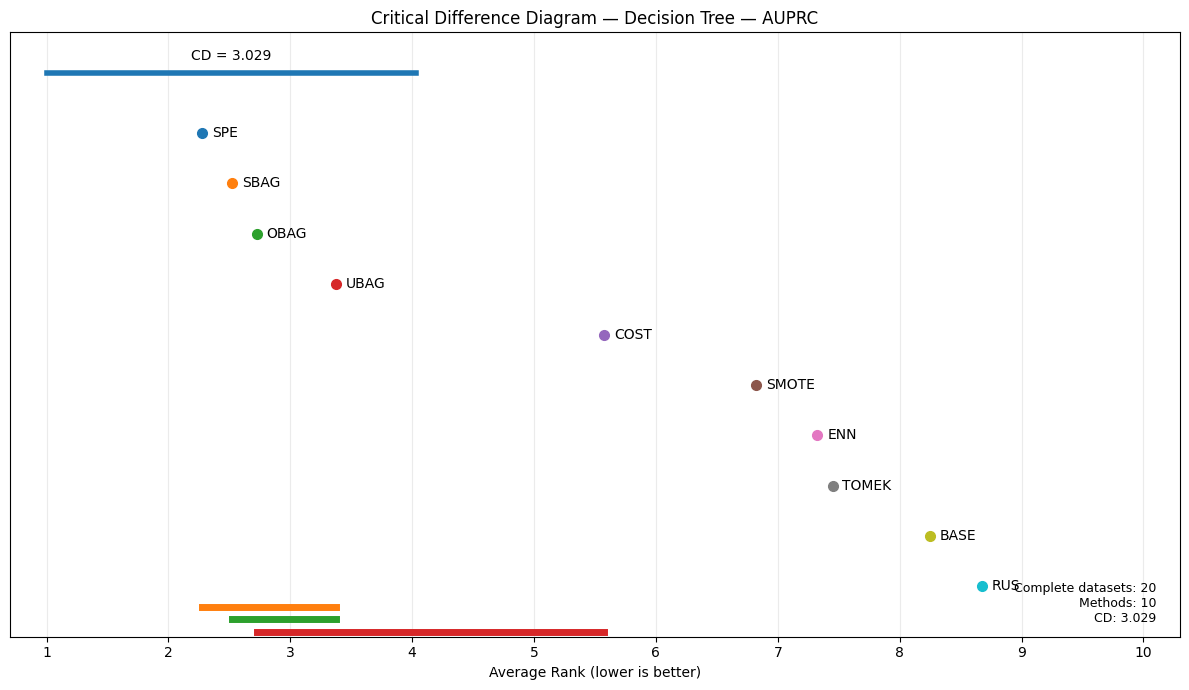

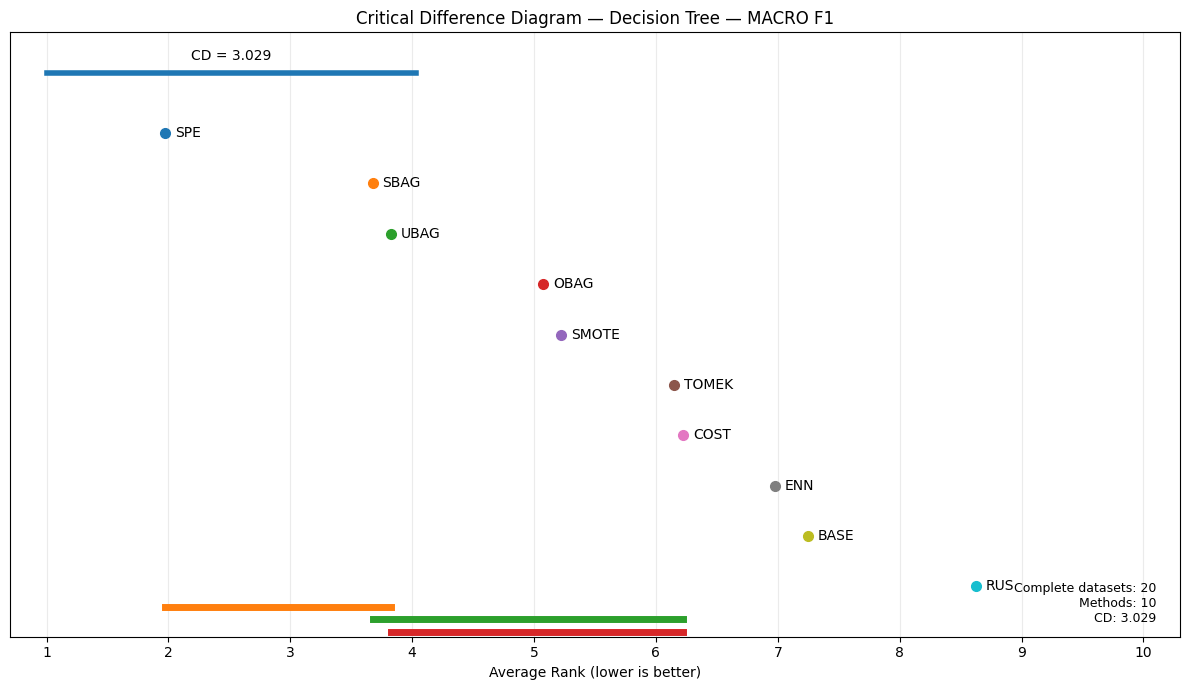

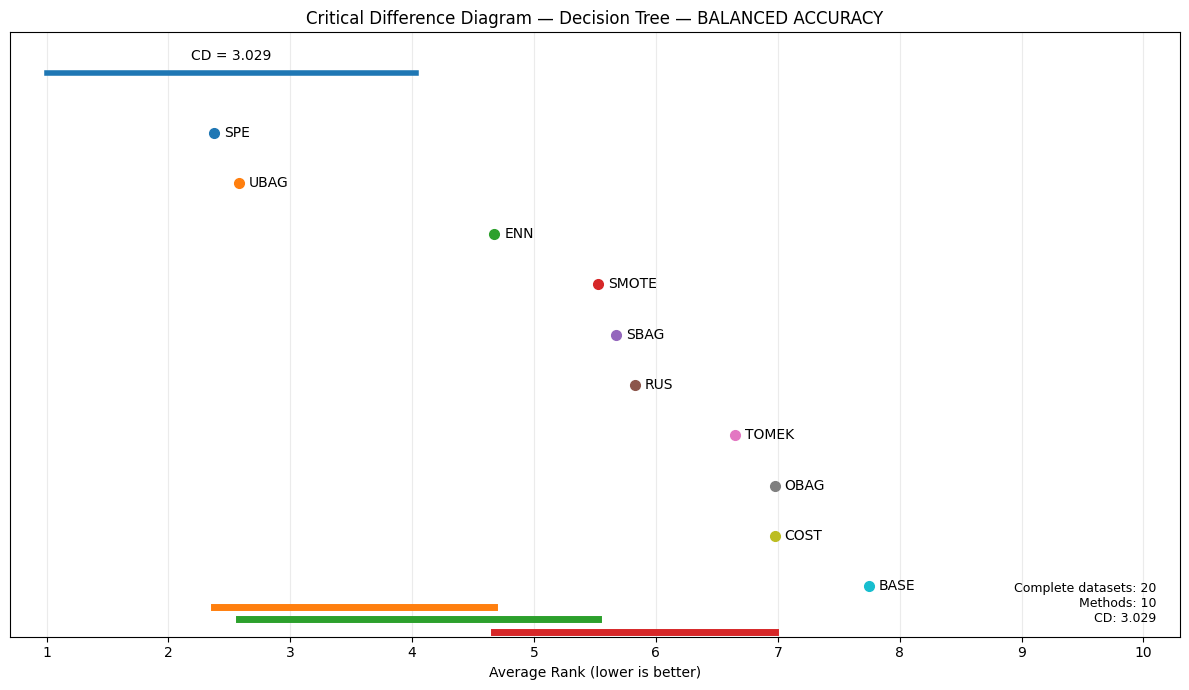

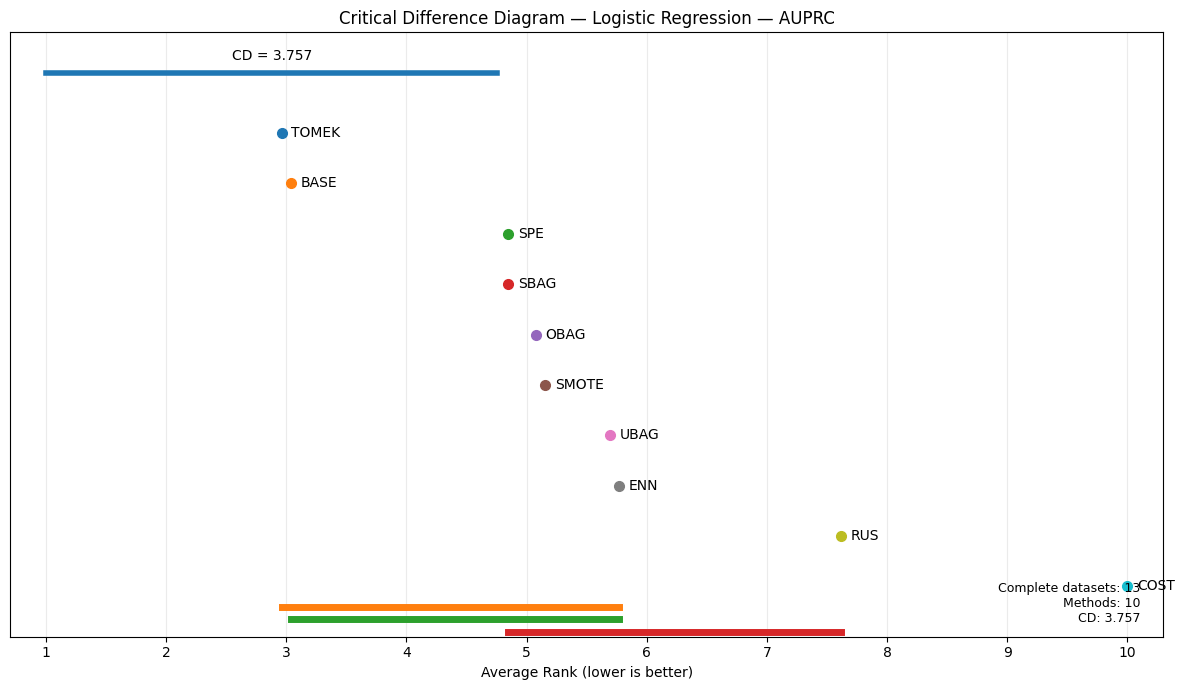

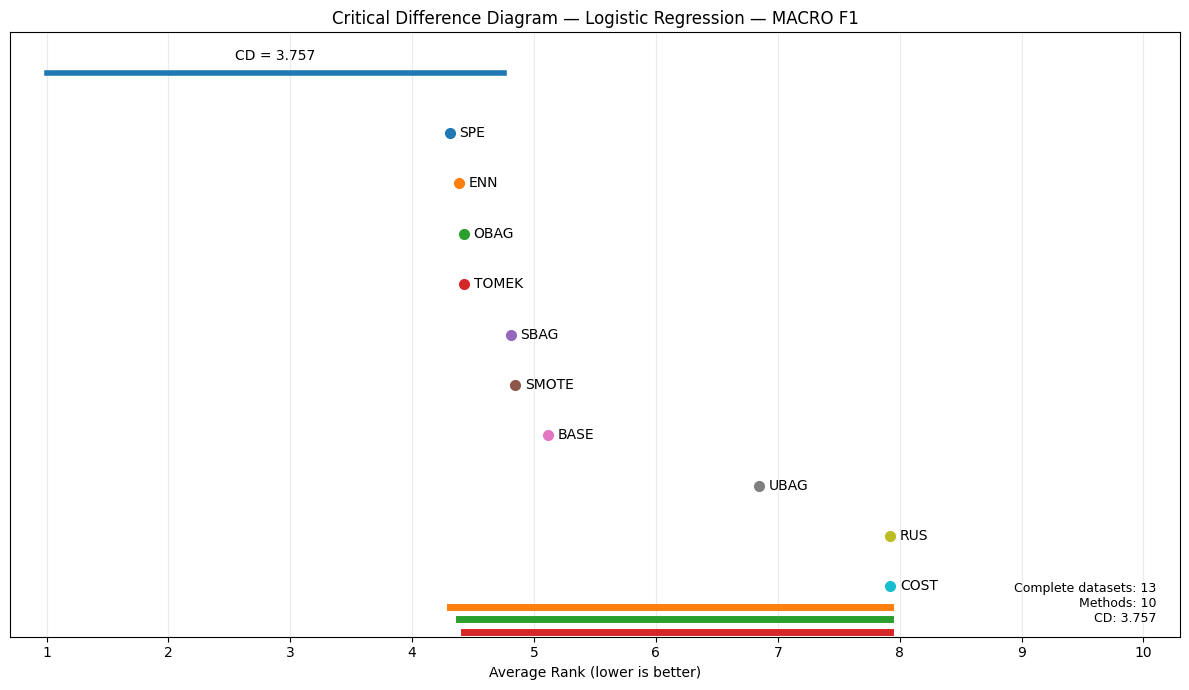

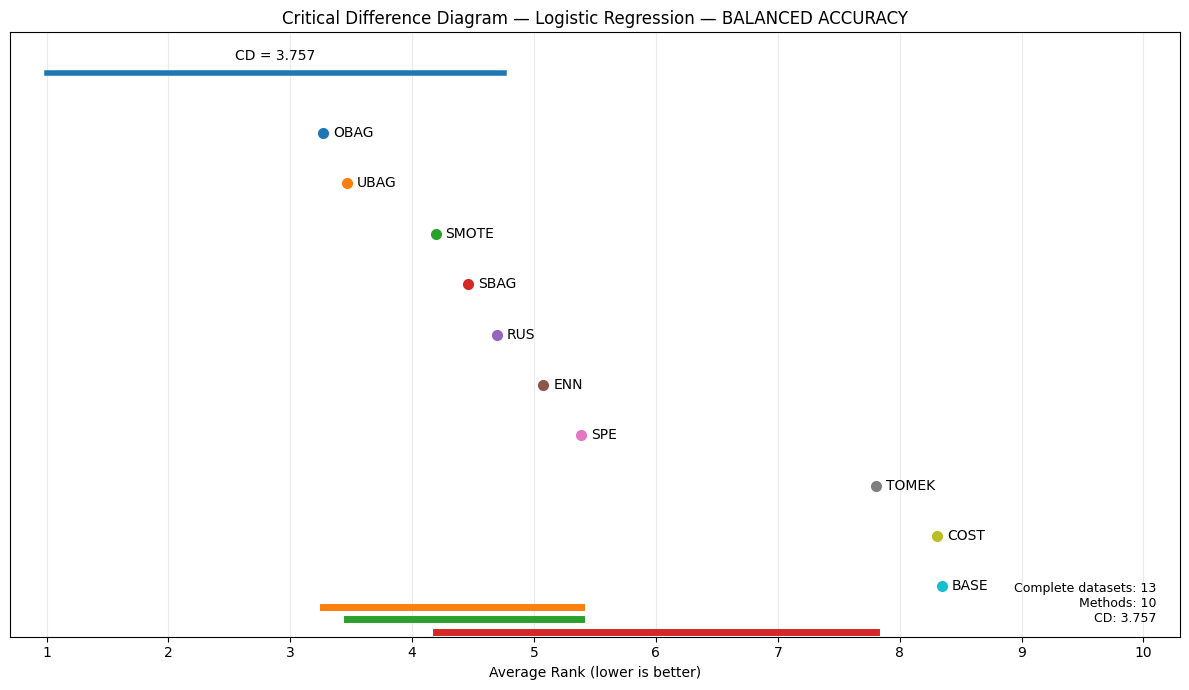


CRITICAL DIFFERENCE DIAGRAMS GENERATED
results/cd_diagrams/CD_decision_tree_auprc.png
results/cd_diagrams/CD_decision_tree_macro_f1.png
results/cd_diagrams/CD_decision_tree_balanced_accuracy.png
results/cd_diagrams/CD_logistic_regression_auprc.png
results/cd_diagrams/CD_logistic_regression_macro_f1.png
results/cd_diagrams/CD_logistic_regression_balanced_accuracy.png

Total diagrams: 6


In [59]:
# ============================================================
# CELL 9 — GENERATE CRITICAL DIFFERENCE DIAGRAMS
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_CSV = "results/conf_v1_cd_ranks.csv"
OUTPUT_DIR = "results/cd_diagrams"

os.makedirs(OUTPUT_DIR, exist_ok=True)

rank_df = pd.read_csv(INPUT_CSV)

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy"
]


# ============================================================
# FUNCTION TO FIND NON-SIGNIFICANT GROUPS
# ============================================================

def find_cd_groups(ranks, cd):
    """
    Find pairs/groups whose average-rank difference
    is <= the Critical Difference.

    These groups are connected in the CD diagram.
    """

    methods = list(ranks.index)

    # Sort from best rank to worst rank
    methods = sorted(methods, key=lambda x: ranks[x])

    groups = []

    for i in range(len(methods)):

        group = [methods[i]]

        for j in range(i + 1, len(methods)):

            difference = abs(
                ranks[methods[j]] - ranks[methods[i]]
            )

            if difference <= cd:
                group.append(methods[j])

        if len(group) > 1:
            groups.append(group)

    return groups


# ============================================================
# DRAW ONE CD DIAGRAM
# ============================================================

def draw_cd_diagram(classifier, metric):

    temp = rank_df[
        (rank_df["classifier"] == classifier) &
        (rank_df["metric"] == metric)
    ].copy()

    temp = temp.sort_values(
        "average_rank",
        ascending=True
    )

    n_datasets = int(temp["n_datasets"].iloc[0])
    cd = float(temp["critical_difference"].iloc[0])

    ranks = temp.set_index("method")["average_rank"]

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    # --------------------------------------------------------
    # Rank axis
    # --------------------------------------------------------

    min_rank = 1
    max_rank = 10

    ax.set_xlim(
        min_rank - 0.3,
        max_rank + 0.3
    )

    ax.set_ylim(
        -1,
        len(temp) + 1
    )

    ax.set_xlabel(
        "Average Rank (lower is better)"
    )

    ax.set_title(
        f"Critical Difference Diagram — "
        f"{classifier.replace('_', ' ').title()} — "
        f"{metric.replace('_', ' ').upper()}"
    )

    # --------------------------------------------------------
    # Axis
    # --------------------------------------------------------

    ax.set_xticks(
        range(1, 11)
    )

    ax.set_yticks([])

    # --------------------------------------------------------
    # Method positions
    # --------------------------------------------------------

    for i, (method, rank) in enumerate(ranks.items()):

        y = len(temp) - i - 1

        ax.plot(
            rank,
            y,
            marker="o",
            markersize=7
        )

        ax.text(
            rank + 0.08,
            y,
            method.upper(),
            va="center",
            fontsize=10
        )

    # --------------------------------------------------------
    # CD bar
    # --------------------------------------------------------

    cd_y = len(temp) + 0.2

    ax.plot(
        [1, 1 + cd],
        [cd_y, cd_y],
        linewidth=4
    )

    ax.text(
        1 + cd / 2,
        cd_y + 0.25,
        f"CD = {cd:.3f}",
        ha="center",
        fontsize=10
    )

    # --------------------------------------------------------
    # Draw connections for rank differences <= CD
    # --------------------------------------------------------

    groups = find_cd_groups(
        ranks,
        cd
    )

    group_y = -0.4

    for group in groups:

        left = min(
            ranks[m]
            for m in group
        )

        right = max(
            ranks[m]
            for m in group
        )

        ax.plot(
            [left, right],
            [group_y, group_y],
            linewidth=5
        )

        group_y -= 0.25

    # --------------------------------------------------------
    # Information box
    # --------------------------------------------------------

    ax.text(
        0.98,
        0.02,
        f"Complete datasets: {n_datasets}\n"
        f"Methods: {len(temp)}\n"
        f"CD: {cd:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    filename = (
        f"CD_{classifier}_{metric}.png"
    )

    filepath = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        filepath,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return filepath


# ============================================================
# GENERATE ALL SIX DIAGRAMS
# ============================================================

saved_files = []

for classifier in CLASSIFIERS:

    for metric in METRICS:

        filepath = draw_cd_diagram(
            classifier,
            metric
        )

        saved_files.append(filepath)


# ============================================================
# REPORT
# ============================================================

print("\n" + "=" * 70)
print("CRITICAL DIFFERENCE DIAGRAMS GENERATED")
print("=" * 70)

for filepath in saved_files:
    print(filepath)

print("\nTotal diagrams:", len(saved_files))

In [60]:
# ============================================================
# CELL 10 — ENSEMBLE GAIN OVER BASELINE
# ============================================================

import pandas as pd
import numpy as np

INPUT_CSV = "results/conf_v1_sweep.csv"
OUTPUT_CSV = "results/conf_v1_ensemble_gain.csv"

METHODS = [
    "spe",
    "ubag",
    "obag",
    "sbag"
]

BASELINE = "base"

CLASSIFIERS = [
    "decision_tree",
    "logistic_regression"
]

METRICS = [
    "auprc",
    "macro_f1",
    "balanced_accuracy"
]

df = pd.read_csv(INPUT_CSV)

# Only successful results
df_ok = df[df["status"] == "ok"].copy()

results = []


# ============================================================
# PROCESS EACH CLASSIFIER × METRIC
# ============================================================

for classifier in CLASSIFIERS:

    for metric in METRICS:

        # ----------------------------------------------------
        # Find complete datasets
        # ----------------------------------------------------

        complete_datasets = []

        for dataset in sorted(df_ok["dataset"].unique()):

            subset = df_ok[
                (df_ok["dataset"] == dataset) &
                (df_ok["base_classifier"] == classifier) &
                (df_ok["metric"] == metric)
            ]

            required_methods = [
                BASELINE
            ] + METHODS

            complete = True

            for method in required_methods:

                n_folds = subset[
                    subset["method"] == method
                ]["fold"].nunique()

                if n_folds != 5:
                    complete = False
                    break

            if complete:
                complete_datasets.append(dataset)

        # ----------------------------------------------------
        # Calculate dataset-level gains
        # ----------------------------------------------------

        for dataset in complete_datasets:

            base_values = df_ok[
                (df_ok["dataset"] == dataset) &
                (df_ok["base_classifier"] == classifier) &
                (df_ok["method"] == BASELINE) &
                (df_ok["metric"] == metric)
            ]["value"]

            base_score = base_values.mean()

            for method in METHODS:

                method_values = df_ok[
                    (df_ok["dataset"] == dataset) &
                    (df_ok["base_classifier"] == classifier) &
                    (df_ok["method"] == method) &
                    (df_ok["metric"] == metric)
                ]["value"]

                method_score = method_values.mean()

                gain = method_score - base_score

                results.append({
                    "classifier": classifier,
                    "metric": metric,
                    "dataset": dataset,
                    "ensemble_method": method,
                    "base_score": base_score,
                    "ensemble_score": method_score,
                    "gain": gain,
                    "improved": gain > 0,
                    "equal": np.isclose(gain, 0),
                    "worse": gain < 0
                })


gain_df = pd.DataFrame(results)

gain_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("ENSEMBLE GAIN OVER BASELINE")
print("=" * 70)

for classifier in CLASSIFIERS:

    for metric in METRICS:

        temp = gain_df[
            (gain_df["classifier"] == classifier) &
            (gain_df["metric"] == metric)
        ].copy()

        print("\n" + "-" * 70)
        print(
            f"{classifier.upper()} — {metric.upper()}"
        )
        print("-" * 70)

        if len(temp) == 0:
            print("No complete datasets.")
            continue

        print(
            f"Complete datasets: "
            f"{temp['dataset'].nunique()}"
        )

        # ----------------------------------------------------
        # Per ensemble method
        # ----------------------------------------------------

        summary = (
            temp
            .groupby("ensemble_method")
            .agg(
                mean_gain=("gain", "mean"),
                median_gain=("gain", "median"),
                std_gain=("gain", "std"),
                improved_count=("improved", "sum"),
                equal_count=("equal", "sum"),
                worse_count=("worse", "sum"),
                n_datasets=("gain", "count")
            )
            .reset_index()
        )

        print("\nEnsemble gain summary:\n")

        print(
            summary.to_string(index=False)
        )

        # ----------------------------------------------------
        # Overall ensemble-level summary
        # ----------------------------------------------------

        print("\nOverall ensemble comparison:")

        print(
            f"  Mean gain:   {temp['gain'].mean():.4f}"
        )

        print(
            f"  Median gain: {temp['gain'].median():.4f}"
        )

        print(
            f"  Improved:    {temp['improved'].sum()} "
            f"/ {len(temp)}"
        )

        print(
            f"  Equal:       {temp['equal'].sum()} "
            f"/ {len(temp)}"
        )

        print(
            f"  Worse:       {temp['worse'].sum()} "
            f"/ {len(temp)}"
        )


# ============================================================
# SAVE
# ============================================================

print("\n" + "=" * 70)
print("FILE SAVED")
print("=" * 70)

print(OUTPUT_CSV)

ENSEMBLE GAIN OVER BASELINE

----------------------------------------------------------------------
DECISION_TREE — AUPRC
----------------------------------------------------------------------
Complete datasets: 20

Ensemble gain summary:

ensemble_method  mean_gain  median_gain  std_gain  improved_count  equal_count  worse_count  n_datasets
           obag   0.157654     0.167730  0.079478              19            1            0          20
           sbag   0.165150     0.183441  0.080574              19            1            0          20
            spe   0.162544     0.169010  0.075221              19            1            0          20
           ubag   0.148358     0.155362  0.073001              19            1            0          20

Overall ensemble comparison:
  Mean gain:   0.1584
  Median gain: 0.1673
  Improved:    76 / 80
  Equal:       4 / 80
  Worse:       0 / 80

----------------------------------------------------------------------
DECISION_TREE — MACRO_F1
--

ENSEMBLE GAIN DATA CHECK

decision_tree
  auprc: 20 complete datasets
  macro_f1: 20 complete datasets
  balanced_accuracy: 20 complete datasets

logistic_regression
  auprc: 20 complete datasets
  macro_f1: 20 complete datasets
  balanced_accuracy: 20 complete datasets

COMMON COMPLETE DATASETS
Number of datasets: 20
['Credit_Approval_Classification', 'JapaneseVowels', 'SPECTF', 'adult', 'bank-marketing', 'blood-transfusion-service-center', 'haberman', 'ibm-employee-attrition', 'ilpd-numeric', 'kc1', 'law-school-admission-bianry', 'mc2', 'pc4', 'phoneme', 'planning-relax', 'thoracic-surgery', 'vehicle', 'vertebra-column', 'vowel', 'wholesale-customers']


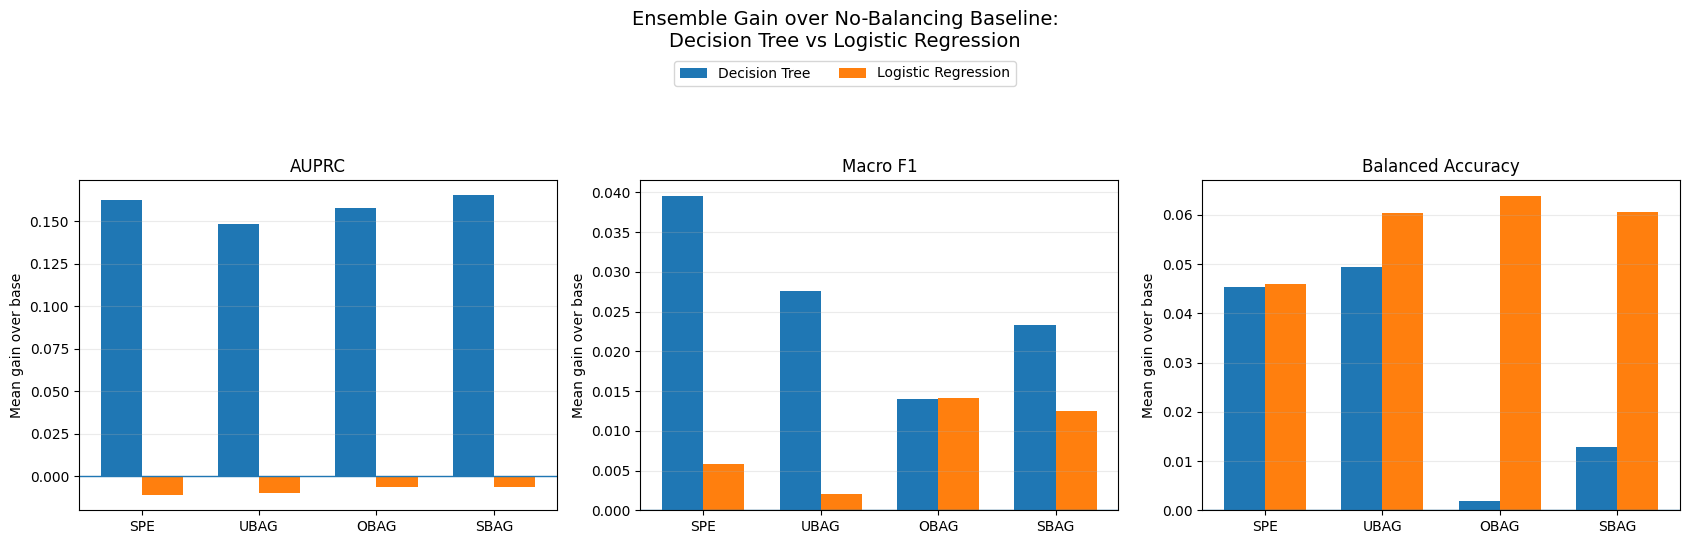


ENSEMBLE GAIN FIGURE SAVED
results/figures/ensemble_gain_dt_vs_lr.png


In [62]:
# ============================================================
# CELL 11 — ENSEMBLE GAIN: DECISION TREE vs LOGISTIC REGRESSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

INPUT_CSV = "results/conf_v1_ensemble_gain.csv"
OUTPUT_DIR = "results/figures"
OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "ensemble_gain_dt_vs_lr.png"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV)

METHODS = ["spe", "ubag", "obag", "sbag"]

METHOD_LABELS = {
    "spe": "SPE",
    "ubag": "UBAG",
    "obag": "OBAG",
    "sbag": "SBAG"
}

METRIC_LABELS = {
    "auprc": "AUPRC",
    "macro_f1": "Macro F1",
    "balanced_accuracy": "Balanced Accuracy"
}

# ------------------------------------------------------------
# Verify completeness directly from the gain data
# ------------------------------------------------------------

print("=" * 70)
print("ENSEMBLE GAIN DATA CHECK")
print("=" * 70)

for classifier in ["decision_tree", "logistic_regression"]:

    print(f"\n{classifier}")

    for metric in METRIC_LABELS:

        subset = df[
            (df["classifier"] == classifier) &
            (df["metric"] == metric)
        ]

        datasets_by_method = {}

        for method in METHODS:

            datasets_by_method[method] = set(
                subset[
                    subset["ensemble_method"] == method
                ]["dataset"]
            )

        common = set.intersection(
            *datasets_by_method.values()
        )

        print(
            f"  {metric}: "
            f"{len(common)} complete datasets"
        )


# ------------------------------------------------------------
# Find datasets complete for BOTH classifiers,
# all four ensemble methods, and all three metrics
# ------------------------------------------------------------

all_common = set(df["dataset"].unique())

for classifier in ["decision_tree", "logistic_regression"]:

    for metric in METRIC_LABELS:

        subset = df[
            (df["classifier"] == classifier) &
            (df["metric"] == metric)
        ]

        method_sets = []

        for method in METHODS:

            method_datasets = set(
                subset[
                    subset["ensemble_method"] == method
                ]["dataset"]
            )

            method_sets.append(method_datasets)

        common = set.intersection(*method_sets)

        all_common = all_common.intersection(common)


complete_common = sorted(all_common)

print("\n" + "=" * 70)
print("COMMON COMPLETE DATASETS")
print("=" * 70)

print(f"Number of datasets: {len(complete_common)}")
print(complete_common)


# ------------------------------------------------------------
# Keep only common complete datasets
# ------------------------------------------------------------

plot_df = df[
    df["dataset"].isin(complete_common)
].copy()


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5.5)
)

for ax, metric in zip(
    axes,
    METRIC_LABELS.keys()
):

    metric_df = plot_df[
        plot_df["metric"] == metric
    ]

    positions = np.arange(len(METHODS))
    width = 0.35

    dt_means = []
    lr_means = []

    for method in METHODS:

        dt_values = metric_df[
            (metric_df["ensemble_method"] == method) &
            (metric_df["classifier"] == "decision_tree")
        ]["gain"]

        lr_values = metric_df[
            (metric_df["ensemble_method"] == method) &
            (metric_df["classifier"] == "logistic_regression")
        ]["gain"]

        dt_means.append(dt_values.mean())
        lr_means.append(lr_values.mean())

    ax.bar(
        positions - width / 2,
        dt_means,
        width,
        label="Decision Tree"
    )

    ax.bar(
        positions + width / 2,
        lr_means,
        width,
        label="Logistic Regression"
    )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_xticks(positions)

    ax.set_xticklabels(
        [METHOD_LABELS[m] for m in METHODS]
    )

    ax.set_ylabel("Mean gain over base")

    ax.set_title(
        METRIC_LABELS[metric]
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


fig.suptitle(
    "Ensemble Gain over No-Balancing Baseline:\n"
    "Decision Tree vs Logistic Regression",
    fontsize=14
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=2
)

plt.tight_layout(
    rect=[0, 0, 1, 0.84]
)

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ENSEMBLE GAIN FIGURE SAVED")
print("=" * 70)

print(OUTPUT_FILE)